# Phân Tích Kết Quả Thực Nghiệm NIDS-VAE

## Mục tiêu

Không chỉ hiển thị các metric — notebook này **giải thích tại sao** mô hình đạt các chỉ số như vậy.

Các câu hỏi được trả lời:
- Tại sao Recall thấp hơn Precision?
- Tại sao xuất hiện False Positive?
- Tại sao xuất hiện False Negative?
- Ưu điểm và hạn chế của VAE-based anomaly detection là gì?

---

## Dữ liệu sử dụng

| File | Nội dung |
|---|---|
| `artifacts/threshold/evaluation_metrics.json` | Accuracy, Precision, Recall, F1, ROC-AUC |
| `artifacts/threshold/confusion_matrix.json` | TP, TN, FP, FN |
| `artifacts/threshold/threshold.json` | Giá trị ngưỡng phát hiện |
| `artifacts/models/model_config.json` | Kiến trúc VAE |
| `artifacts/models/training_summary.json` | Kết quả huấn luyện |

**Lưu ý:** Notebook này **không train lại model**. Chỉ phân tích kết quả đã có.

---

## Section 1 — Load Kết Quả Thực Nghiệm

Đọc toàn bộ artifacts đã tạo ra trong quá trình training và evaluation.
Hiển thị bảng tổng hợp tất cả metric chính.

In [1]:
# ── Import thư viện chuẩn ──────────────────────────────────────────────────
import json
import sys
from pathlib import Path

# ── Import thư viện khoa học dữ liệu ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import Markdown, display

# ── Thiết lập đường dẫn gốc project ───────────────────────────────────────
# Notebook nằm trong notebooks/ → PROJECT_ROOT là thư mục cha
PROJECT_ROOT  = Path(".").resolve().parent
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
OUTPUT_DIR    = ARTIFACTS_DIR / "experiments" / "result_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Cấu hình matplotlib ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_style("whitegrid")

# ── Đọc toàn bộ artifacts ─────────────────────────────────────────────────
# Đọc evaluation_metrics.json — kết quả đánh giá trên tập test
with open(ARTIFACTS_DIR / "threshold" / "evaluation_metrics.json", "r", encoding="utf-8") as f:
    eval_data = json.load(f)

# Đọc confusion_matrix.json — ma trận nhầm lẫn
with open(ARTIFACTS_DIR / "threshold" / "confusion_matrix.json", "r", encoding="utf-8") as f:
    cm_data = json.load(f)

# Đọc threshold.json — thông tin ngưỡng phát hiện và thống kê lỗi
with open(ARTIFACTS_DIR / "threshold" / "threshold.json", "r", encoding="utf-8") as f:
    threshold_data = json.load(f)

# Đọc model_config.json — kiến trúc VAE
with open(ARTIFACTS_DIR / "models" / "model_config.json", "r", encoding="utf-8") as f:
    model_config = json.load(f)

# Đọc training_summary.json — kết quả huấn luyện
with open(ARTIFACTS_DIR / "models" / "training_summary.json", "r", encoding="utf-8") as f:
    training_summary = json.load(f)

# ── Trích xuất các giá trị metric chính ───────────────────────────────────
metrics = eval_data["metrics"]
cm      = cm_data["confusion_matrix"]

# Các chỉ số hiệu năng từ evaluation_metrics.json
ACCURACY  = metrics["accuracy"]
PRECISION = metrics["precision"]
RECALL    = metrics["recall"]
F1        = metrics["f1_score"]
ROC_AUC   = metrics["roc_auc"]
FPR       = metrics["false_positive_rate"]

# Các thành phần confusion matrix
TP = cm["tp"]
TN = cm["tn"]
FP = cm["fp"]
FN = cm["fn"]

# Thông tin tập test
N_SAMPLES        = metrics["n_samples"]
N_TRUE_ANOMALY   = metrics["n_true_anomaly"]
N_TRUE_NORMAL    = metrics["n_true_normal"]
N_PRED_ANOMALY   = metrics["n_predicted_anomaly"]
THRESHOLD        = eval_data["threshold"]
PERCENTILE       = eval_data["percentile"]

# ── Hiển thị bảng tổng hợp metric ─────────────────────────────────────────
print("=" * 65)
print("  📊 BẢNG TỔNG HỢP KẾT QUẢ THỰC NGHIỆM NIDS-VAE")
print("=" * 65)

summary_data = {
    "Metric":  ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "FPR"],
    "Giá trị": [ACCURACY, PRECISION, RECALL, F1, ROC_AUC, FPR],
    "Phần trăm (%)": [
        f"{ACCURACY*100:.2f}%",
        f"{PRECISION*100:.2f}%",
        f"{RECALL*100:.2f}%",
        f"{F1*100:.2f}%",
        f"{ROC_AUC*100:.2f}%",
        f"{FPR*100:.2f}%",
    ],
    "Ý nghĩa": [
        "Tỷ lệ dự đoán đúng toàn bộ",
        "Tỷ lệ đúng trong các cảnh báo phát ra",
        "Tỷ lệ attack được phát hiện",
        "Cân bằng Precision–Recall",
        "Khả năng phân biệt NORMAL vs ANOMALY",
        "Tỷ lệ báo nhầm trên flow bình thường",
    ],
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print(f"\n{'─'*65}")
print(f"  Tập test: {N_SAMPLES:,} flows  |  NORMAL: {N_TRUE_NORMAL:,}  |  ANOMALY: {N_TRUE_ANOMALY:,}")
print(f"  Threshold: {THRESHOLD:.6f}  (Percentile {int(PERCENTILE)})")
print(f"  Kiến trúc VAE: input={model_config['input_dim']}  "
      f"→ hidden={model_config['hidden_dims']}  "
      f"→ latent={model_config['latent_dim']}")
print(f"{'─'*65}")
print(f"\n✅ Đã tải toàn bộ artifacts từ: {ARTIFACTS_DIR}")

  📊 BẢNG TỔNG HỢP KẾT QUẢ THỰC NGHIỆM NIDS-VAE
   Metric  Giá trị Phần trăm (%)                               Ý nghĩa
 Accuracy 0.892018        89.20%            Tỷ lệ dự đoán đúng toàn bộ
Precision 0.865398        86.54% Tỷ lệ đúng trong các cảnh báo phát ra
   Recall 0.577806        57.78%           Tỷ lệ attack được phát hiện
 F1-score 0.692947        69.29%             Cân bằng Precision–Recall
  ROC-AUC 0.783550        78.35%  Khả năng phân biệt NORMAL vs ANOMALY
      FPR 0.024016         2.40%  Tỷ lệ báo nhầm trên flow bình thường

─────────────────────────────────────────────────────────────────
  Tập test: 2,019,575 flows  |  NORMAL: 1,593,697  |  ANOMALY: 425,878
  Threshold: 6.031263  (Percentile 99)
  Kiến trúc VAE: input=66  → hidden=[128, 64]  → latent=16
─────────────────────────────────────────────────────────────────

✅ Đã tải toàn bộ artifacts từ: D:\nids-vae-project\artifacts


---

## Section 2 — Phân Tích Confusion Matrix

Confusion Matrix là nền tảng để hiểu tại sao các metric đạt giá trị như vậy.

$$
\text{Confusion Matrix} = \begin{pmatrix} TN & FP \\ FN & TP \end{pmatrix}
$$

- **TP (True Positive):** Attack được phát hiện đúng
- **TN (True Negative):** Normal được nhận diện đúng  
- **FP (False Positive):** Normal bị báo nhầm là attack — **False Alarm**
- **FN (False Negative):** Attack bị bỏ sót — **Missed Detection**

📋 Confusion Matrix — Số liệu chi tiết:
──────────────────────────────────────────────────
                         Dự đoán NORMAL  Dự đoán ANOMALY
──────────────────────────────────────────────────
  Thực tế NORMAL              1,555,423           38,274
  Thực tế ANOMALY               179,803          246,075
──────────────────────────────────────────────────

  TP = 246,075   TN = 1,555,423
  FP = 38,274   FN = 179,803

  Tổng mẫu = 2,019,575
  ANOMALY thực tế = 425,878  (21.1%)
  NORMAL thực tế  = 1,593,697  (78.9%)


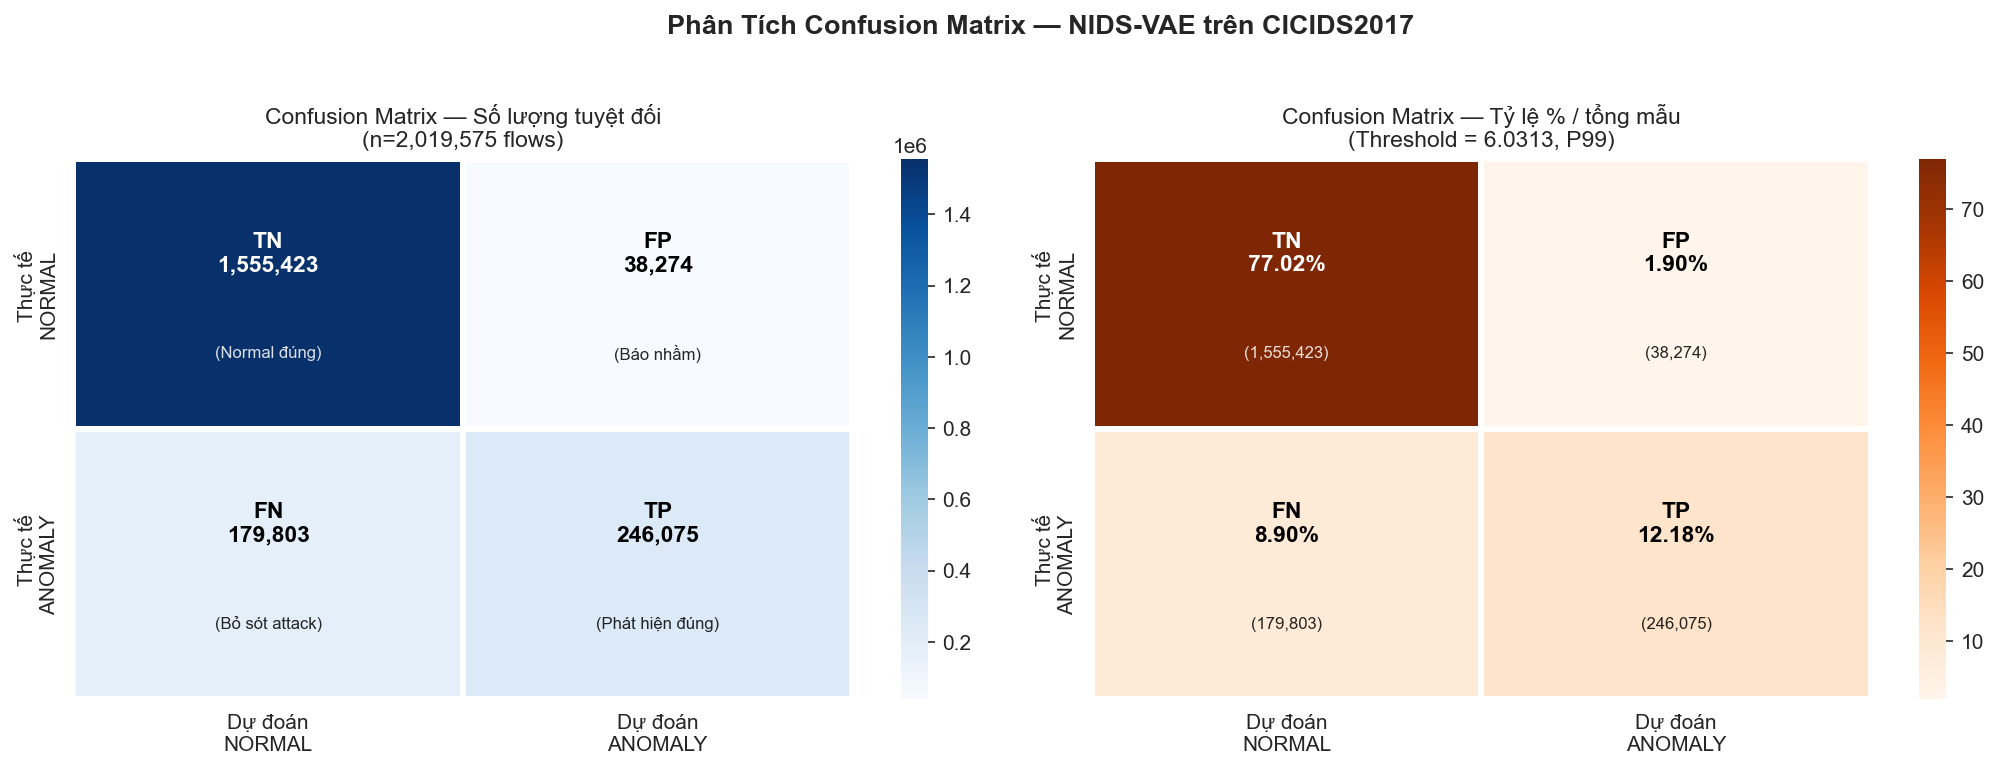


✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\result_analysis\confusion_matrix_analysis.png


In [2]:
# ── Hiển thị bảng confusion matrix dạng số liệu ──────────────────────────
print("📋 Confusion Matrix — Số liệu chi tiết:")
print(f"{'─'*50}")
print(f"  {'':20s}  {'Dự đoán NORMAL':>15}  {'Dự đoán ANOMALY':>15}")
print(f"{'─'*50}")
print(f"  {'Thực tế NORMAL':20s}  {TN:>15,}  {FP:>15,}")
print(f"  {'Thực tế ANOMALY':20s}  {FN:>15,}  {TP:>15,}")
print(f"{'─'*50}")
print(f"\n  TP = {TP:,}   TN = {TN:,}")
print(f"  FP = {FP:,}   FN = {FN:,}")
print(f"\n  Tổng mẫu = {N_SAMPLES:,}")
print(f"  ANOMALY thực tế = {N_TRUE_ANOMALY:,}  ({N_TRUE_ANOMALY/N_SAMPLES*100:.1f}%)")
print(f"  NORMAL thực tế  = {N_TRUE_NORMAL:,}  ({N_TRUE_NORMAL/N_SAMPLES*100:.1f}%)")

# ── Vẽ Confusion Matrix heatmap ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Heatmap theo số lượng tuyệt đối ---
cm_matrix = np.array([[TN, FP], [FN, TP]])
labels_map = {(0, 0): ("TN", "True Negative\n(Normal đúng)"),
              (0, 1): ("FP", "False Positive\n(Báo nhầm)"),
              (1, 0): ("FN", "False Negative\n(Bỏ sót attack)"),
              (1, 1): ("TP", "True Positive\n(Phát hiện đúng)")}

sns.heatmap(
    cm_matrix, annot=False, cmap="Blues",
    linewidths=2, linecolor="white",
    xticklabels=["Dự đoán\nNORMAL", "Dự đoán\nANOMALY"],
    yticklabels=["Thực tế\nNORMAL", "Thực tế\nANOMALY"],
    ax=axes[0], cbar=True,
)
# Annotate từng ô với nhãn TP/TN/FP/FN
for (row, col), (short, long) in labels_map.items():
    val = cm_matrix[row, col]
    text_color = "white" if val > cm_matrix.max() * 0.5 else "black"
    axes[0].text(col + 0.5, row + 0.35, f"{short}\n{val:,}",
                 ha="center", va="center", fontsize=11,
                 color=text_color, fontweight="bold")
    axes[0].text(col + 0.5, row + 0.72, long.split("\n")[1],
                 ha="center", va="center", fontsize=8,
                 color=text_color, alpha=0.85)

axes[0].set_title("Confusion Matrix — Số lượng tuyệt đối\n"
                  f"(n={N_SAMPLES:,} flows)", fontsize=11)

# --- Subplot 2: Heatmap theo tỷ lệ phần trăm ---
cm_pct = cm_matrix / N_SAMPLES * 100  # tỷ lệ so với tổng mẫu
sns.heatmap(
    cm_pct, annot=False, cmap="Oranges", fmt=".1f",
    linewidths=2, linecolor="white",
    xticklabels=["Dự đoán\nNORMAL", "Dự đoán\nANOMALY"],
    yticklabels=["Thực tế\nNORMAL", "Thực tế\nANOMALY"],
    ax=axes[1], cbar=True,
)
for (row, col), (short, _) in labels_map.items():
    val_pct = cm_pct[row, col]
    val_abs = cm_matrix[row, col]
    text_color = "white" if val_pct > cm_pct.max() * 0.5 else "black"
    axes[1].text(col + 0.5, row + 0.35, f"{short}\n{val_pct:.2f}%",
                 ha="center", va="center", fontsize=11,
                 color=text_color, fontweight="bold")
    axes[1].text(col + 0.5, row + 0.72, f"({val_abs:,})",
                 ha="center", va="center", fontsize=8,
                 color=text_color, alpha=0.85)

axes[1].set_title("Confusion Matrix — Tỷ lệ % / tổng mẫu\n"
                  f"(Threshold = {THRESHOLD:.4f}, P{int(PERCENTILE)})", fontsize=11)

plt.suptitle("Phân Tích Confusion Matrix — NIDS-VAE trên CICIDS2017",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

# Lưu hình
cm_fig_path = OUTPUT_DIR / "confusion_matrix_analysis.png"
fig.savefig(cm_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Đã lưu: {cm_fig_path}")

---

## Section 3 — Phân Tích Accuracy

### Công thức

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

### Tại sao Accuracy cao có thể gây hiểu nhầm?

Trong dataset **mất cân bằng lớp (class imbalance)**, một mô hình chỉ cần dự đoán mọi thứ là "NORMAL" cũng đạt Accuracy rất cao, **dù không phát hiện được bất kỳ attack nào**.

Ví dụ với CICIDS2017:
- Nếu 79% là NORMAL, một mô hình "luôn dự đoán NORMAL" đạt Accuracy = **79%** nhưng Recall = **0%**

→ **Accuracy một mình không đủ để đánh giá hệ thống NIDS.**

  📊 PHÂN TÍCH ACCURACY

  Accuracy thực tế (mô hình VAE)  : 0.8920  (89.20%)
  Accuracy naive (luôn dự đoán NORMAL)  : 0.7891  (78.91%)
  Accuracy naive (luôn dự đoán ANOMALY) : 0.2109  (21.09%)

  → Mô hình VAE vượt naive classifier 10.29%
  → Dataset mất cân bằng: NORMAL=78.9%  ANOMALY=21.1%


C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\2255058937.py:68: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\2255058937.py:68: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\2255058937.py:71: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.savefig(acc_fig_path, dpi=150, bbox_inches="tight")
C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\2255058937.py:71: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.savefig(acc_fig_path, dpi=150, bbox_inches="tight")
d:\nids-vae-project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\nids-vae-project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning

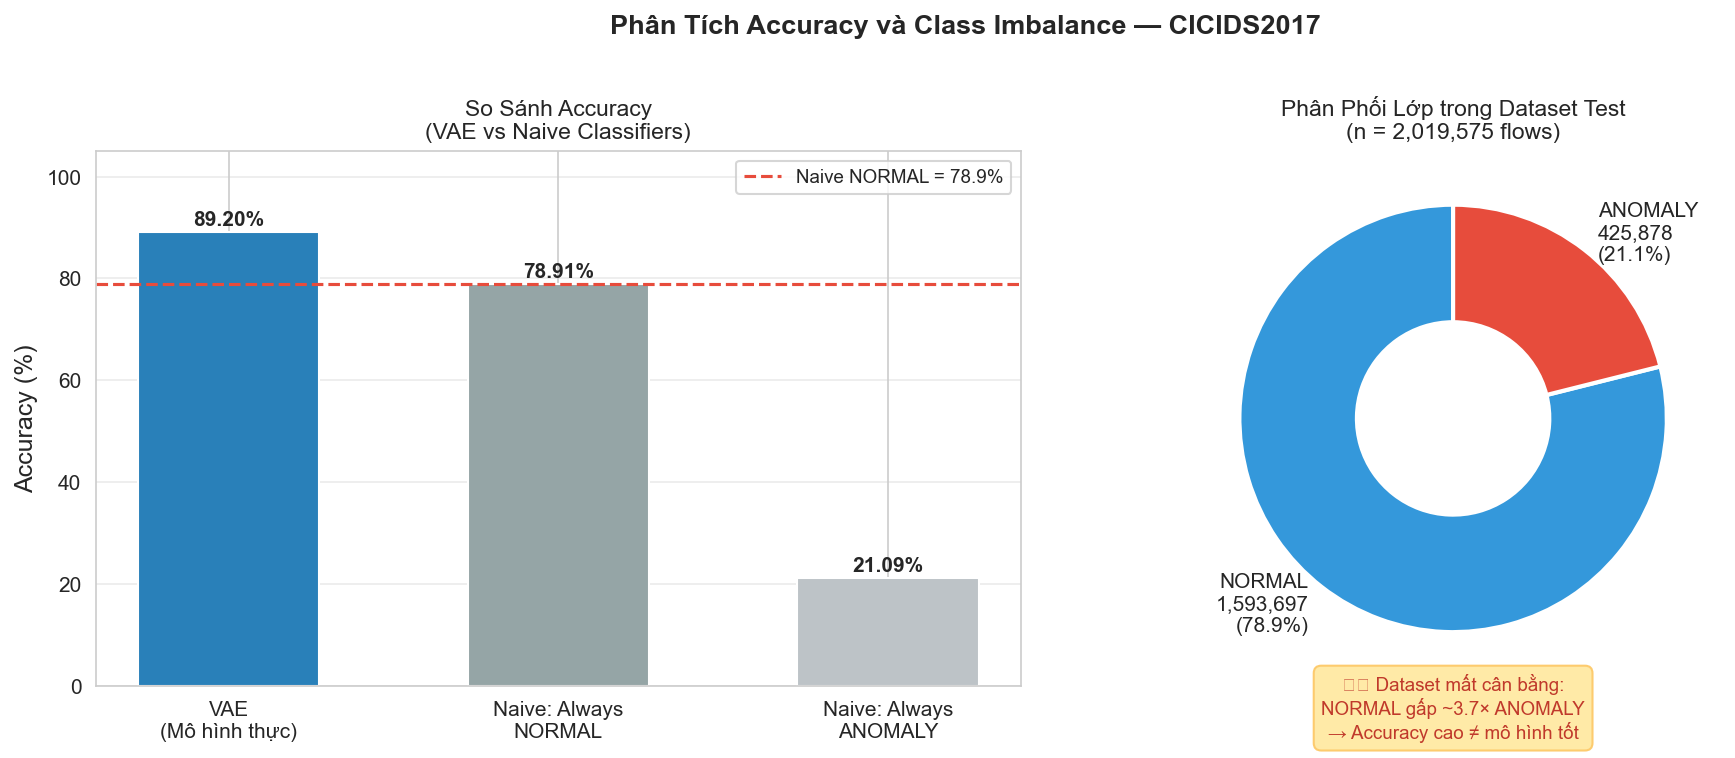


### 🔍 Kết luận phân tích Accuracy

**Accuracy = 89.20%** nghe có vẻ ấn tượng, nhưng cần lưu ý:

1. **Dataset CICIDS2017 mất cân bằng**: NORMAL chiếm **78.9%**,
   nên một mô hình "luôn dự đoán NORMAL" đã đạt **78.91%**.

2. **Mô hình VAE chỉ vượt naive classifier 10.29%** về Accuracy.
   Điều này cho thấy Accuracy **không phải metric đánh giá chính** cho NIDS.

3. **Metric quan trọng hơn cho NIDS**: Recall (phát hiện attack), Precision (độ chính xác cảnh báo),
   và F1-score (cân bằng hai metric trên).


In [3]:
# ── Phân tích Accuracy và tác động của class imbalance ────────────────────

# Tính Accuracy từ công thức gốc (kiểm chứng)
acc_formula = (TP + TN) / N_SAMPLES

# Accuracy nếu mô hình "luôn dự đoán NORMAL" (worst case naive classifier)
acc_naive_normal = N_TRUE_NORMAL / N_SAMPLES

# Accuracy nếu mô hình "luôn dự đoán ANOMALY"
acc_naive_anomaly = N_TRUE_ANOMALY / N_SAMPLES

print("=" * 62)
print("  📊 PHÂN TÍCH ACCURACY")
print("=" * 62)
print(f"\n  Accuracy thực tế (mô hình VAE)  : {acc_formula:.4f}  ({acc_formula*100:.2f}%)")
print(f"  Accuracy naive (luôn dự đoán NORMAL)  : {acc_naive_normal:.4f}  ({acc_naive_normal*100:.2f}%)")
print(f"  Accuracy naive (luôn dự đoán ANOMALY) : {acc_naive_anomaly:.4f}  ({acc_naive_anomaly*100:.2f}%)")

print(f"\n  → Mô hình VAE vượt naive classifier {(acc_formula - acc_naive_normal)*100:.2f}%")
print(f"  → Dataset mất cân bằng: NORMAL={N_TRUE_NORMAL/N_SAMPLES*100:.1f}%  ANOMALY={N_TRUE_ANOMALY/N_SAMPLES*100:.1f}%")

# ── Biểu đồ so sánh Accuracy các classifier ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: So sánh Accuracy của các classifier
classifiers  = ["VAE\n(Mô hình thực)", "Naive: Always\nNORMAL", "Naive: Always\nANOMALY"]
accuracies   = [acc_formula, acc_naive_normal, acc_naive_anomaly]
bar_colors   = ["#2980b9", "#95a5a6", "#bdc3c7"]

bars = axes[0].bar(classifiers, [a * 100 for a in accuracies],
                   color=bar_colors, edgecolor="white", width=0.55)
# Annotate giá trị
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{acc*100:.2f}%", ha="center", va="bottom",
                 fontweight="bold", fontsize=10)

axes[0].set_ylim(0, 105)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("So Sánh Accuracy\n(VAE vs Naive Classifiers)", fontsize=11)
axes[0].axhline(acc_naive_normal * 100, color="#e74c3c", linestyle="--",
                linewidth=1.5, label=f"Naive NORMAL = {acc_naive_normal*100:.1f}%")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.4)

# Subplot 2: Phân phối lớp trong dataset (minh họa mất cân bằng)
class_sizes  = [N_TRUE_NORMAL, N_TRUE_ANOMALY]
class_labels = [f"NORMAL\n{N_TRUE_NORMAL:,}\n({N_TRUE_NORMAL/N_SAMPLES*100:.1f}%)",
                f"ANOMALY\n{N_TRUE_ANOMALY:,}\n({N_TRUE_ANOMALY/N_SAMPLES*100:.1f}%)"]
class_colors = ["#3498db", "#e74c3c"]

wedges, _ = axes[1].pie(class_sizes, labels=class_labels,
                         colors=class_colors, startangle=90,
                         wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2))
axes[1].set_title("Phân Phối Lớp trong Dataset Test\n"
                  f"(n = {N_SAMPLES:,} flows)", fontsize=11)

# Chú thích về mất cân bằng
axes[1].text(0, -1.5,
             "⚠️ Dataset mất cân bằng:\nNORMAL gấp ~3.7× ANOMALY\n"
             "→ Accuracy cao ≠ mô hình tốt",
             ha="center", fontsize=9, color="#c0392b",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#ffeaa7", edgecolor="#fdcb6e"))

plt.suptitle("Phân Tích Accuracy và Class Imbalance — CICIDS2017",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

acc_fig_path = OUTPUT_DIR / "accuracy_analysis.png"
fig.savefig(acc_fig_path, dpi=150, bbox_inches="tight")
plt.show()

display(Markdown(f"""
### 🔍 Kết luận phân tích Accuracy

**Accuracy = {acc_formula*100:.2f}%** nghe có vẻ ấn tượng, nhưng cần lưu ý:

1. **Dataset CICIDS2017 mất cân bằng**: NORMAL chiếm **{N_TRUE_NORMAL/N_SAMPLES*100:.1f}%**,
   nên một mô hình "luôn dự đoán NORMAL" đã đạt **{acc_naive_normal*100:.2f}%**.

2. **Mô hình VAE chỉ vượt naive classifier {(acc_formula - acc_naive_normal)*100:.2f}%** về Accuracy.
   Điều này cho thấy Accuracy **không phải metric đánh giá chính** cho NIDS.

3. **Metric quan trọng hơn cho NIDS**: Recall (phát hiện attack), Precision (độ chính xác cảnh báo),
   và F1-score (cân bằng hai metric trên).
"""))

---

## Section 4 — Phân Tích Precision

### Công thức

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

### Ý nghĩa

**Precision** trả lời câu hỏi: *"Trong tất cả cảnh báo mà hệ thống phát ra, bao nhiêu phần trăm là attack thực sự?"*

- **Precision cao** → ít False Alarm → SOC analyst tin tưởng cảnh báo hơn
- **Precision thấp** → nhiều False Alarm → SOC analyst bị quá tải, có thể bỏ qua cảnh báo thật

  📊 PHÂN TÍCH PRECISION

  Công thức: Precision = TP / (TP + FP)
  = 246,075 / (246,075 + 38,274)
  = 246,075 / 284,349
  = 0.8654  (86.54%)

  → Trong 284,349 cảnh báo phát ra:
    - 246,075  là attack thực sự  (86.5%)
    - 38,274  là false alarm      (13.5%)

  ──────────────────────────────────────────────────
  🔍 Tại sao Precision = 86.54% (cao)?
  ──────────────────────────────────────────────────
  Lý do 1: Threshold P99 rất cao (6.0313)
           → Chỉ flow có error RẤT CAO mới bị đánh dấu là attack
           → FP = 38,274 (chỉ 2.40% flow bình thường bị báo nhầm)

  Lý do 2: VAE được train CHỈ trên BENIGN traffic
           → Model học kỹ phân phối normal
           → Phần lớn flow bình thường có error thấp

  Lý do 3: Dataset CICIDS2017 có attack rõ ràng (DDoS, PortScan)
           → Các attack nặng có error cao, dễ phân biệt


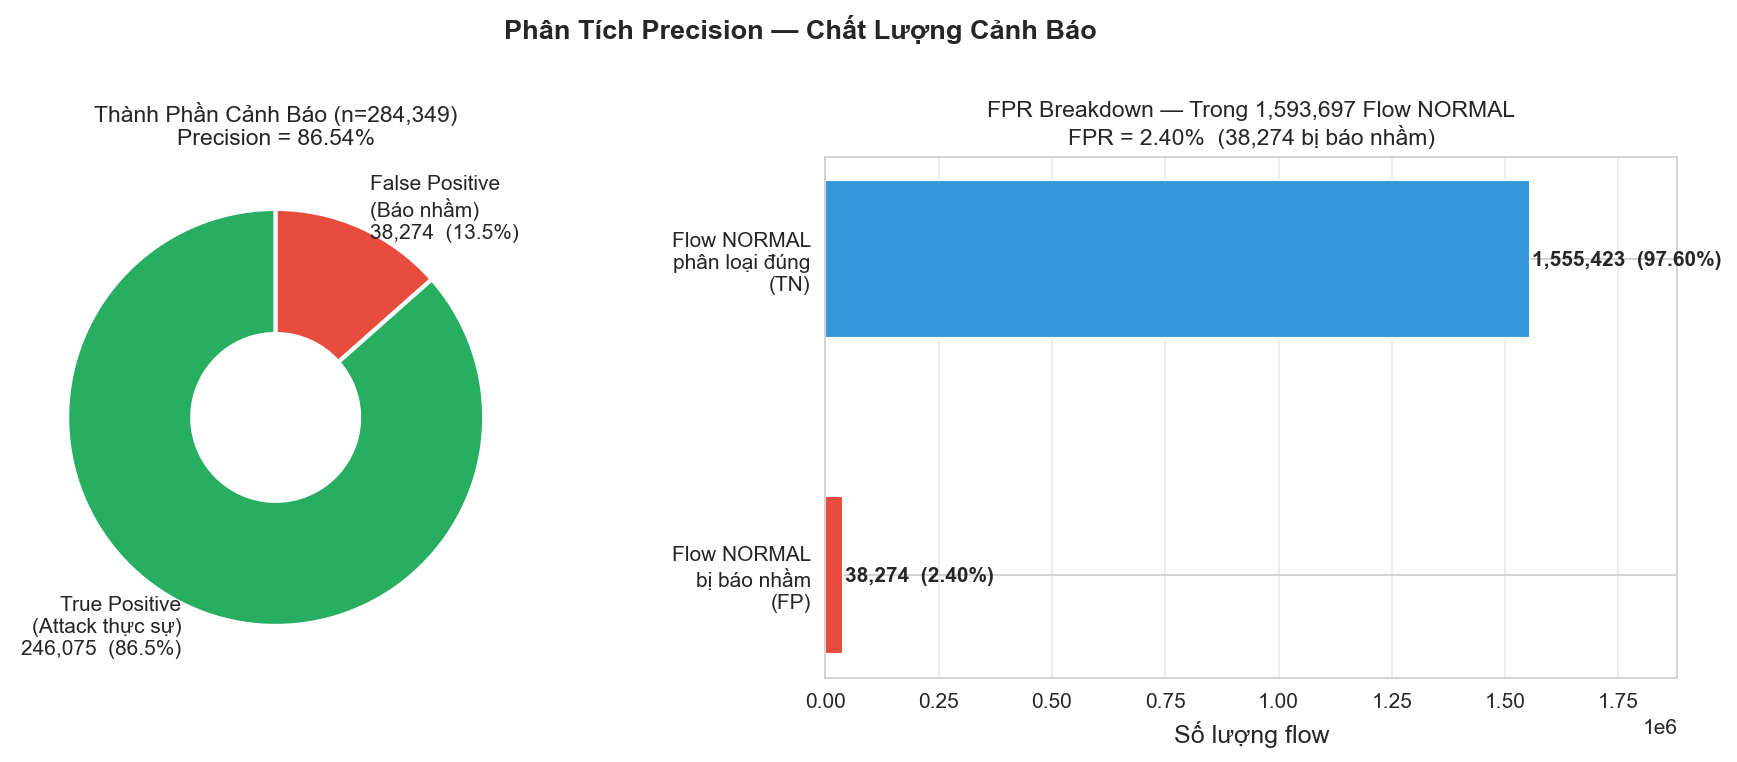


✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\result_analysis\precision_analysis.png


In [4]:
# ── Phân tích Precision ────────────────────────────────────────────────────

# Kiểm chứng công thức
precision_formula = TP / (TP + FP)

print("=" * 62)
print("  📊 PHÂN TÍCH PRECISION")
print("=" * 62)
print(f"\n  Công thức: Precision = TP / (TP + FP)")
print(f"  = {TP:,} / ({TP:,} + {FP:,})")
print(f"  = {TP:,} / {TP+FP:,}")
print(f"  = {precision_formula:.4f}  ({precision_formula*100:.2f}%)")

print(f"\n  → Trong {N_PRED_ANOMALY:,} cảnh báo phát ra:")
print(f"    - {TP:,}  là attack thực sự  ({TP/N_PRED_ANOMALY*100:.1f}%)")
print(f"    - {FP:,}  là false alarm      ({FP/N_PRED_ANOMALY*100:.1f}%)")

# ── Phân tích nguyên nhân Precision cao ───────────────────────────────────
print(f"\n  {'─'*50}")
print(f"  🔍 Tại sao Precision = {precision_formula*100:.2f}% (cao)?")
print(f"  {'─'*50}")
print(f"  Lý do 1: Threshold P{int(PERCENTILE)} rất cao ({THRESHOLD:.4f})")
print(f"           → Chỉ flow có error RẤT CAO mới bị đánh dấu là attack")
print(f"           → FP = {FP:,} (chỉ {FP/N_TRUE_NORMAL*100:.2f}% flow bình thường bị báo nhầm)")
print(f"\n  Lý do 2: VAE được train CHỈ trên BENIGN traffic")
print(f"           → Model học kỹ phân phối normal")
print(f"           → Phần lớn flow bình thường có error thấp")
print(f"\n  Lý do 3: Dataset CICIDS2017 có attack rõ ràng (DDoS, PortScan)")
print(f"           → Các attack nặng có error cao, dễ phân biệt")

# ── Biểu đồ phân tích cảnh báo ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Thành phần của N dự đoán anomaly
labels_pie = [f"True Positive\n(Attack thực sự)\n{TP:,}  ({TP/N_PRED_ANOMALY*100:.1f}%)",
              f"False Positive\n(Báo nhầm)\n{FP:,}  ({FP/N_PRED_ANOMALY*100:.1f}%)"]
sizes_pie  = [TP, FP]
colors_pie = ["#27ae60", "#e74c3c"]

wedges, _ = axes[0].pie(sizes_pie, labels=labels_pie,
                         colors=colors_pie, startangle=90,
                         wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2))
axes[0].set_title(f"Thành Phần Cảnh Báo (n={N_PRED_ANOMALY:,})\n"
                  f"Precision = {precision_formula*100:.2f}%", fontsize=11)

# Subplot 2: So sánh FP rate với threshold
# Trực quan hóa ý nghĩa FPR = 2.4%
fpr_val = FP / N_TRUE_NORMAL
categories = ["Flow NORMAL\nbị báo nhầm\n(FP)", "Flow NORMAL\nphân loại đúng\n(TN)"]
values     = [FP, TN]
bar_colors2 = ["#e74c3c", "#3498db"]

bars2 = axes[1].barh(categories, values, color=bar_colors2,
                      edgecolor="white", height=0.5)
for bar, val in zip(bars2, values):
    axes[1].text(bar.get_width() + 5000, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}  ({val/N_TRUE_NORMAL*100:.2f}%)",
                 va="center", fontsize=10, fontweight="bold")

axes[1].set_xlim(0, N_TRUE_NORMAL * 1.18)
axes[1].set_xlabel("Số lượng flow")
axes[1].set_title(f"FPR Breakdown — Trong {N_TRUE_NORMAL:,} Flow NORMAL\n"
                  f"FPR = {fpr_val*100:.2f}%  ({FP:,} bị báo nhầm)", fontsize=11)
axes[1].grid(axis="x", alpha=0.4)

plt.suptitle("Phân Tích Precision — Chất Lượng Cảnh Báo",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

prec_fig_path = OUTPUT_DIR / "precision_analysis.png"
fig.savefig(prec_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Đã lưu: {prec_fig_path}")

---

## Section 5 — Phân Tích Recall ⭐ (Quan trọng nhất)

### Công thức

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

### Tại sao Recall là metric quan trọng nhất cho NIDS?

**Recall** (còn gọi là **Sensitivity** hay **True Positive Rate**) trả lời:  
*"Trong tất cả attack thực sự, mô hình phát hiện được bao nhiêu?"*

**FN cao = Bỏ sót attack → Nguy hiểm hơn FP trong môi trường NIDS thực tế.**

### Tại sao Recall chưa cao?

Recall thấp hơn Precision là đặc điểm **phổ biến của unsupervised anomaly detection**:

```
VAE chỉ học phân phối BENIGN
→ Một số ATTACK có đặc trưng thống kê gần BENIGN
→ VAE tái tạo được chúng tốt
→ Reconstruction error thấp, không vượt threshold
→ FN cao → Recall thấp
```

  📊 PHÂN TÍCH RECALL ⭐

  Công thức: Recall = TP / (TP + FN)
  = 246,075 / (246,075 + 179,803)
  = 246,075 / 425,878
  = 0.5778  (57.78%)

  → Trong 425,878 attack thực sự:
    - Phát hiện được : 246,075  (57.8%)
    - Bỏ sót (FN)    : 179,803  (42.2%)

  ───────────────────────────────────────────────────────
  🔍 Tại sao Recall chỉ đạt 57.78%?
  ───────────────────────────────────────────────────────

  Nguyên nhân 1: Threshold P99 = 6.0313 (rất cao)
    → Chỉ flow có error > 6.0313 mới bị đánh dấu là attack
    → Nhiều attack có error THẤP HƠN ngưỡng này → FN = 179,803
    → Validation BENIGN error stats:
       mean = 0.6354  median = 0.2587  p99 = 6.0313

  Nguyên nhân 2: Attack có đặc trưng gần BENIGN
    → CICIDS2017 chứa nhiều loại attack:
       • Infiltration attack: traffic ít bất thường
       • Web attacks (SQL injection, XSS): packet size tương tự BENIGN
       • Heartbleed: lưu lượng thấp, gần BENIGN
    → VAE học BENIGN → tái tạo được attack giống BENIGN
    → Reconstruc

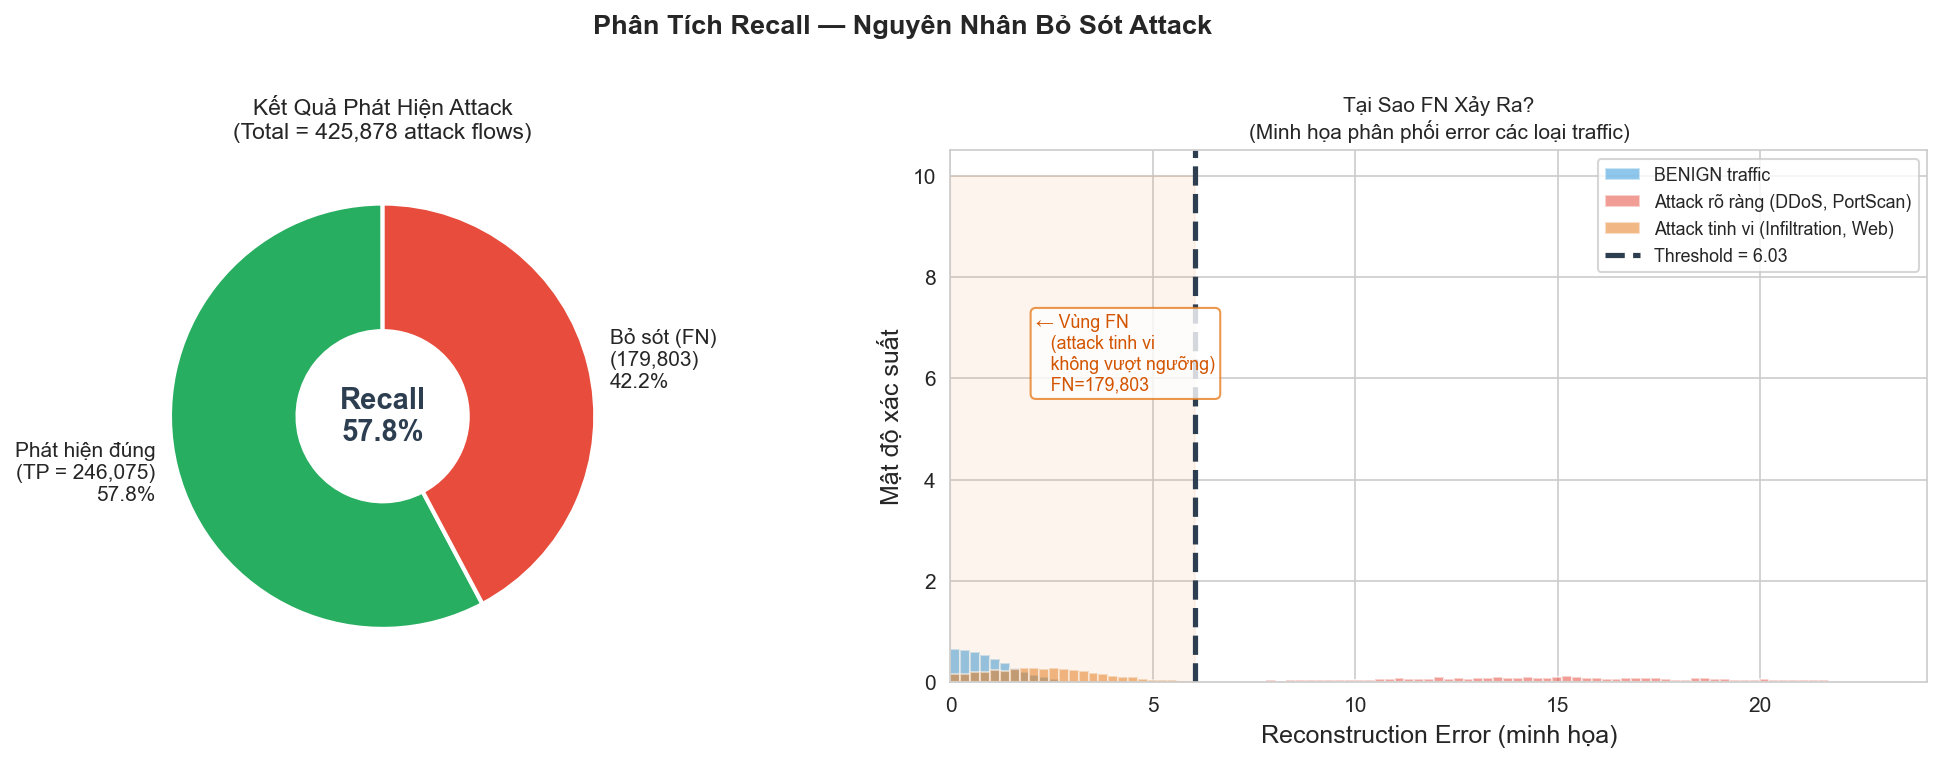


✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\result_analysis\recall_analysis.png


In [5]:
# ── Phân tích Recall và nguyên nhân FN ────────────────────────────────────

# Kiểm chứng công thức Recall
recall_formula = TP / (TP + FN)
fnr = FN / (FN + TP)  # False Negative Rate = tỷ lệ bỏ sót

print("=" * 62)
print("  📊 PHÂN TÍCH RECALL ⭐")
print("=" * 62)
print(f"\n  Công thức: Recall = TP / (TP + FN)")
print(f"  = {TP:,} / ({TP:,} + {FN:,})")
print(f"  = {TP:,} / {TP+FN:,}")
print(f"  = {recall_formula:.4f}  ({recall_formula*100:.2f}%)")

print(f"\n  → Trong {N_TRUE_ANOMALY:,} attack thực sự:")
print(f"    - Phát hiện được : {TP:,}  ({TP/N_TRUE_ANOMALY*100:.1f}%)")
print(f"    - Bỏ sót (FN)    : {FN:,}  ({FN/N_TRUE_ANOMALY*100:.1f}%)")

# ── Phân tích nguyên nhân FN cao ──────────────────────────────────────────
print(f"\n  {'─'*55}")
print(f"  🔍 Tại sao Recall chỉ đạt {recall_formula*100:.2f}%?")
print(f"  {'─'*55}")

# Nguyên nhân 1: Threshold P99 rất cao
val_error_stats = threshold_data["validation_error_stats"]
print(f"\n  Nguyên nhân 1: Threshold P{int(PERCENTILE)} = {THRESHOLD:.4f} (rất cao)")
print(f"    → Chỉ flow có error > {THRESHOLD:.4f} mới bị đánh dấu là attack")
print(f"    → Nhiều attack có error THẤP HƠN ngưỡng này → FN = {FN:,}")
print(f"    → Validation BENIGN error stats:")
print(f"       mean = {val_error_stats['mean']:.4f}  "
      f"median = {val_error_stats['median']:.4f}  "
      f"p99 = {val_error_stats['p99']:.4f}")

print(f"\n  Nguyên nhân 2: Attack có đặc trưng gần BENIGN")
print(f"    → CICIDS2017 chứa nhiều loại attack:")
print(f"       • Infiltration attack: traffic ít bất thường")
print(f"       • Web attacks (SQL injection, XSS): packet size tương tự BENIGN")
print(f"       • Heartbleed: lưu lượng thấp, gần BENIGN")
print(f"    → VAE học BENIGN → tái tạo được attack giống BENIGN")
print(f"    → Reconstruction error thấp → không vượt ngưỡng")

print(f"\n  Nguyên nhân 3: Kiến trúc VAE (semi-supervised)")
print(f"    → VAE chỉ học phân phối BENIGN (không biết attack trông như thế nào)")
print(f"    → Latent space 16D có thể encode được một số attack tương tự BENIGN")
print(f"    → Hạn chế cơ bản của unsupervised approach")

# ── Biểu đồ phân tích FN và Recall ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Phân phối attack — được phát hiện vs bị bỏ sót
labels_donut = [f"Phát hiện đúng\n(TP = {TP:,})\n{TP/N_TRUE_ANOMALY*100:.1f}%",
                f"Bỏ sót (FN)\n({FN:,})\n{FN/N_TRUE_ANOMALY*100:.1f}%"]
sizes_donut  = [TP, FN]
colors_donut = ["#27ae60", "#e74c3c"]

wedges, _ = axes[0].pie(sizes_donut, labels=labels_donut,
                         colors=colors_donut, startangle=90,
                         wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2))
axes[0].set_title(f"Kết Quả Phát Hiện Attack\n"
                  f"(Total = {N_TRUE_ANOMALY:,} attack flows)",
                  fontsize=11)
axes[0].text(0, 0, f"Recall\n{recall_formula*100:.1f}%",
             ha="center", va="center", fontsize=14, fontweight="bold", color="#2c3e50")

# Subplot 2: Minh họa tại sao FN xảy ra — error distribution conceptual
# Dùng threshold error stats để vẽ phân phối giả định
np.random.seed(42)

# Phân phối error BENIGN (từ thống kê validation)
mean_b, std_b = val_error_stats["mean"], val_error_stats["std"]
# Clip để tránh giá trị âm
benign_errors_sim = np.abs(np.random.normal(mean_b, std_b * 0.4, 5000))

# Attack rõ ràng (DDoS, PortScan) — error cao
attack_high_sim = np.abs(np.random.normal(THRESHOLD * 2.5, THRESHOLD * 0.8, 2500))

# Attack tinh vi (Infiltration, Web) — error thấp, gần BENIGN
attack_low_sim = np.abs(np.random.normal(mean_b * 3.5, std_b * 0.6, 1500))

x_max = THRESHOLD * 4
ax2 = axes[1]

# Vẽ các phân phối
bins_range = np.linspace(0, x_max, 100)
ax2.hist(benign_errors_sim[benign_errors_sim < x_max], bins=bins_range,
         density=True, alpha=0.55, color="#3498db", label="BENIGN traffic")
ax2.hist(attack_high_sim[attack_high_sim < x_max], bins=bins_range,
         density=True, alpha=0.55, color="#e74c3c",
         label="Attack rõ ràng (DDoS, PortScan)")
ax2.hist(attack_low_sim[attack_low_sim < x_max], bins=bins_range,
         density=True, alpha=0.55, color="#e67e22",
         label="Attack tinh vi (Infiltration, Web)")

# Đường threshold
ax2.axvline(THRESHOLD, color="#2c3e50", linestyle="--", linewidth=2.5,
            label=f"Threshold = {THRESHOLD:.2f}")

# Vùng FN (attack tinh vi nằm bên trái threshold)
ax2_ylim = ax2.get_ylim()
ax2.fill_betweenx([0, 10], 0, THRESHOLD, alpha=0.08, color="#e67e22")
ax2.text(THRESHOLD * 0.35, ax2.get_ylim()[1] * 0.55,
         f"← Vùng FN\n   (attack tinh vi\n   không vượt ngưỡng)\n   FN={FN:,}",
         fontsize=8.5, color="#d35400",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#e67e22", alpha=0.8))

ax2.set_xlim(0, x_max)
ax2.set_xlabel("Reconstruction Error (minh họa)")
ax2.set_ylabel("Mật độ xác suất")
ax2.set_title("Tại Sao FN Xảy Ra?\n(Minh họa phân phối error các loại traffic)",
              fontsize=10)
ax2.legend(fontsize=8.5, loc="upper right")

plt.suptitle("Phân Tích Recall — Nguyên Nhân Bỏ Sót Attack",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

recall_fig_path = OUTPUT_DIR / "recall_analysis.png"
fig.savefig(recall_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Đã lưu: {recall_fig_path}")

---

## Section 6 — Phân Tích F1-Score

### Công thức

$$
F1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \times TP}{2 \times TP + FP + FN}
$$

### Ý nghĩa

F1-score là **trung bình điều hòa** của Precision và Recall:
- Nếu một metric rất thấp, F1 bị kéo xuống mạnh
- F1 đạt max khi cả Precision và Recall đều cao và **cân bằng nhau**
- F1 là metric tiêu chuẩn để đánh giá hệ thống phân loại với class imbalance

  📊 PHÂN TÍCH F1-SCORE

  Công thức: F1 = 2 × P × R / (P + R)
  = 2 × 0.8654 × 0.5778 / (0.8654 + 0.5778)
  = 0.6929  (69.29%)

  Precision = 0.8654  |  Recall = 0.5778
  Chênh lệch P–R = 0.2876  (28.76% — Precision CAO hơn Recall)

  ──────────────────────────────────────────────────
  🔍 F1 bị kéo xuống bởi metric nào?
  ──────────────────────────────────────────────────
  Recall thấp hơn Precision 28.76%
  → F1 bị kéo XUỐNG bởi Recall
  → Cải thiện Recall sẽ tăng F1 nhiều hơn cải thiện Precision

  F1 nếu Precision = Recall = 0.8654: 0.8654
  F1 thực tế: 0.6929  (giảm 17.25% do Recall thấp)


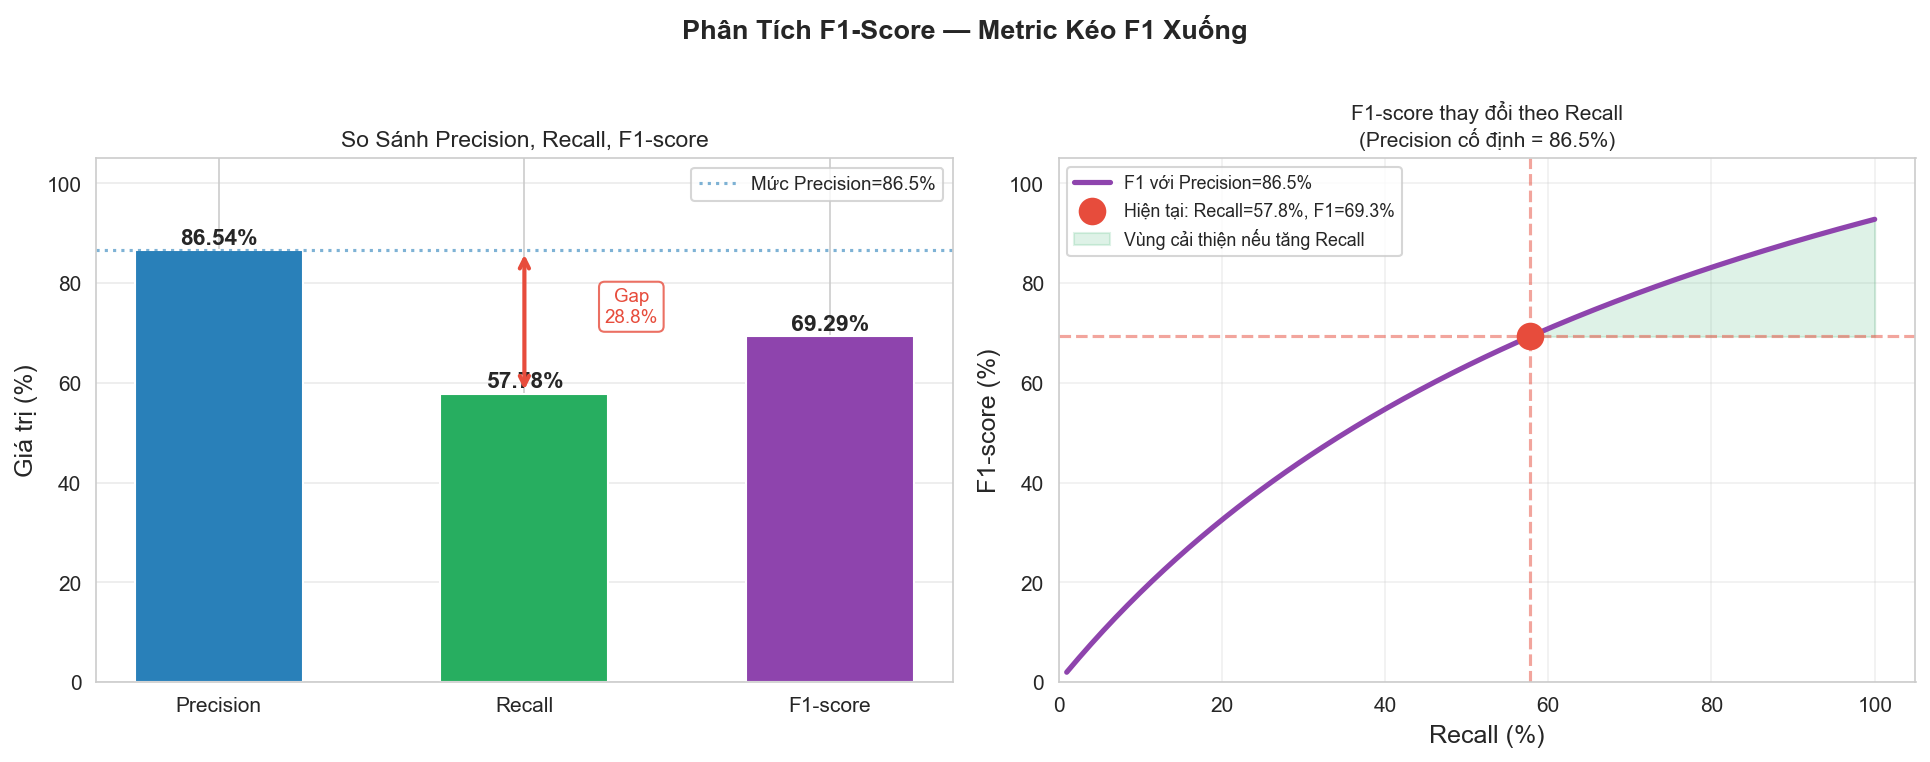


✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\result_analysis\f1_analysis.png



### 🔍 Kết luận phân tích F1

**F1 = 69.29%** phản ánh sự mất cân bằng giữa Precision và Recall:
- **Precision = 86.54%** — rất cao, cảnh báo đáng tin cậy
- **Recall = 57.78%** — thấp hơn 28.76%, kéo F1 xuống

**→ Để tăng F1, ưu tiên cải thiện Recall** (hạ threshold, fine-tune kiến trúc, hoặc bổ sung semi-supervised learning).


In [6]:
# ── Phân tích F1-score ─────────────────────────────────────────────────────

# Kiểm chứng công thức F1
f1_formula = 2 * PRECISION * RECALL / (PRECISION + RECALL)

# F1 lý tưởng nếu Recall = Precision (symmetric)
f1_perfect_balance = 2 * PRECISION * PRECISION / (PRECISION + PRECISION)

# Mức chênh lệch giữa Precision và Recall
gap = PRECISION - RECALL

print("=" * 62)
print("  📊 PHÂN TÍCH F1-SCORE")
print("=" * 62)
print(f"\n  Công thức: F1 = 2 × P × R / (P + R)")
print(f"  = 2 × {PRECISION:.4f} × {RECALL:.4f} / ({PRECISION:.4f} + {RECALL:.4f})")
print(f"  = {f1_formula:.4f}  ({f1_formula*100:.2f}%)")

print(f"\n  Precision = {PRECISION:.4f}  |  Recall = {RECALL:.4f}")
print(f"  Chênh lệch P–R = {gap:.4f}  ({gap*100:.2f}% — Precision CAO hơn Recall)")

print(f"\n  {'─'*50}")
print(f"  🔍 F1 bị kéo xuống bởi metric nào?")
print(f"  {'─'*50}")
print(f"  Recall thấp hơn Precision {gap*100:.2f}%")
print(f"  → F1 bị kéo XUỐNG bởi Recall")
print(f"  → Cải thiện Recall sẽ tăng F1 nhiều hơn cải thiện Precision")
print(f"\n  F1 nếu Precision = Recall = {PRECISION:.4f}: {f1_perfect_balance:.4f}")
print(f"  F1 thực tế: {f1_formula:.4f}  (giảm {(f1_perfect_balance - f1_formula)*100:.2f}% do Recall thấp)")

# ── Biểu đồ so sánh Precision, Recall, F1 ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: So sánh P, R, F1
metric_names = ["Precision", "Recall", "F1-score"]
metric_vals  = [PRECISION, RECALL, F1]
bar_colors3  = ["#2980b9", "#27ae60", "#8e44ad"]

bars3 = axes[0].bar(metric_names, [v * 100 for v in metric_vals],
                    color=bar_colors3, edgecolor="white", width=0.55)
for bar, val in zip(bars3, metric_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{val*100:.2f}%", ha="center", va="bottom",
                 fontweight="bold", fontsize=11)

axes[0].set_ylim(0, 105)
axes[0].set_ylabel("Giá trị (%)")
axes[0].set_title("So Sánh Precision, Recall, F1-score", fontsize=11)
# Vẽ đường cân bằng giả định
axes[0].axhline(PRECISION * 100, color="#2980b9", linestyle=":", alpha=0.6,
                linewidth=1.5, label=f"Mức Precision={PRECISION*100:.1f}%")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.4)

# Chú thích khoảng cách P-R
axes[0].annotate("",
    xy=(1, RECALL * 100), xytext=(1, PRECISION * 100),
    arrowprops=dict(arrowstyle="<->", color="#e74c3c", lw=2))
axes[0].text(1.35, (PRECISION + RECALL) / 2 * 100,
             f"Gap\n{gap*100:.1f}%",
             color="#e74c3c", fontsize=9, ha="center",
             bbox=dict(boxstyle="round", facecolor="white", edgecolor="#e74c3c", alpha=0.8))

# Subplot 2: F1 là trung bình điều hòa — minh họa
# Vẽ đường F1 = f(Recall) khi cố định Precision
recall_range = np.linspace(0.01, 1.0, 200)
f1_curve     = 2 * PRECISION * recall_range / (PRECISION + recall_range)

axes[1].plot(recall_range * 100, f1_curve * 100,
             color="#8e44ad", linewidth=2.5, label=f"F1 với Precision={PRECISION*100:.1f}%")
# Đánh dấu điểm thực tế
axes[1].scatter([RECALL * 100], [F1 * 100], s=150, color="#e74c3c",
                zorder=5, label=f"Hiện tại: Recall={RECALL*100:.1f}%, F1={F1*100:.1f}%")
axes[1].axvline(RECALL * 100, color="#e74c3c", linestyle="--", alpha=0.5)
axes[1].axhline(F1 * 100,     color="#e74c3c", linestyle="--", alpha=0.5)

# Vùng "nếu cải thiện Recall"
axes[1].fill_between(recall_range[recall_range >= RECALL] * 100,
                     f1_curve[recall_range >= RECALL] * 100,
                     F1 * 100, alpha=0.15, color="#27ae60",
                     label="Vùng cải thiện nếu tăng Recall")

axes[1].set_xlim(0, 105)
axes[1].set_ylim(0, 105)
axes[1].set_xlabel("Recall (%)")
axes[1].set_ylabel("F1-score (%)")
axes[1].set_title(f"F1-score thay đổi theo Recall\n"
                  f"(Precision cố định = {PRECISION*100:.1f}%)", fontsize=10)
axes[1].legend(fontsize=8.5)
axes[1].grid(alpha=0.3)

plt.suptitle("Phân Tích F1-Score — Metric Kéo F1 Xuống",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

f1_fig_path = OUTPUT_DIR / "f1_analysis.png"
fig.savefig(f1_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Đã lưu: {f1_fig_path}")

display(Markdown(f"""
### 🔍 Kết luận phân tích F1

**F1 = {F1*100:.2f}%** phản ánh sự mất cân bằng giữa Precision và Recall:
- **Precision = {PRECISION*100:.2f}%** — rất cao, cảnh báo đáng tin cậy
- **Recall = {RECALL*100:.2f}%** — thấp hơn {gap*100:.2f}%, kéo F1 xuống

**→ Để tăng F1, ưu tiên cải thiện Recall** (hạ threshold, fine-tune kiến trúc, hoặc bổ sung semi-supervised learning).
"""))

---

## Section 7 — Phân Tích ROC-AUC

### Ý nghĩa

**ROC-AUC (Area Under the ROC Curve)** đo khả năng **tổng quát** của mô hình phân biệt NORMAL và ANOMALY, **không phụ thuộc vào ngưỡng (threshold)**.

- AUC = 1.0: Mô hình hoàn hảo
- AUC = 0.5: Mô hình ngẫu nhiên (random guess)
- AUC > 0.8: Tốt

ROC curve vẽ **TPR (Recall) vs FPR** khi quét toàn bộ ngưỡng có thể.

### Tại sao ROC-AUC = 78.35% (chưa đạt 90%)?

```
Latent space 16D chưa tách biệt hoàn toàn NORMAL và ANOMALY
→ Một số attack có representation gần BENIGN trong latent space
→ Reconstruction error của chúng chồng lấp với BENIGN errors
→ Khó phân biệt ở mọi ngưỡng → AUC bị giới hạn
```

✅ Đã tải test errors: 2,019,575 samples
   ROC-AUC (computed) = 0.7835
   ROC-AUC (từ metrics JSON) = 0.7835


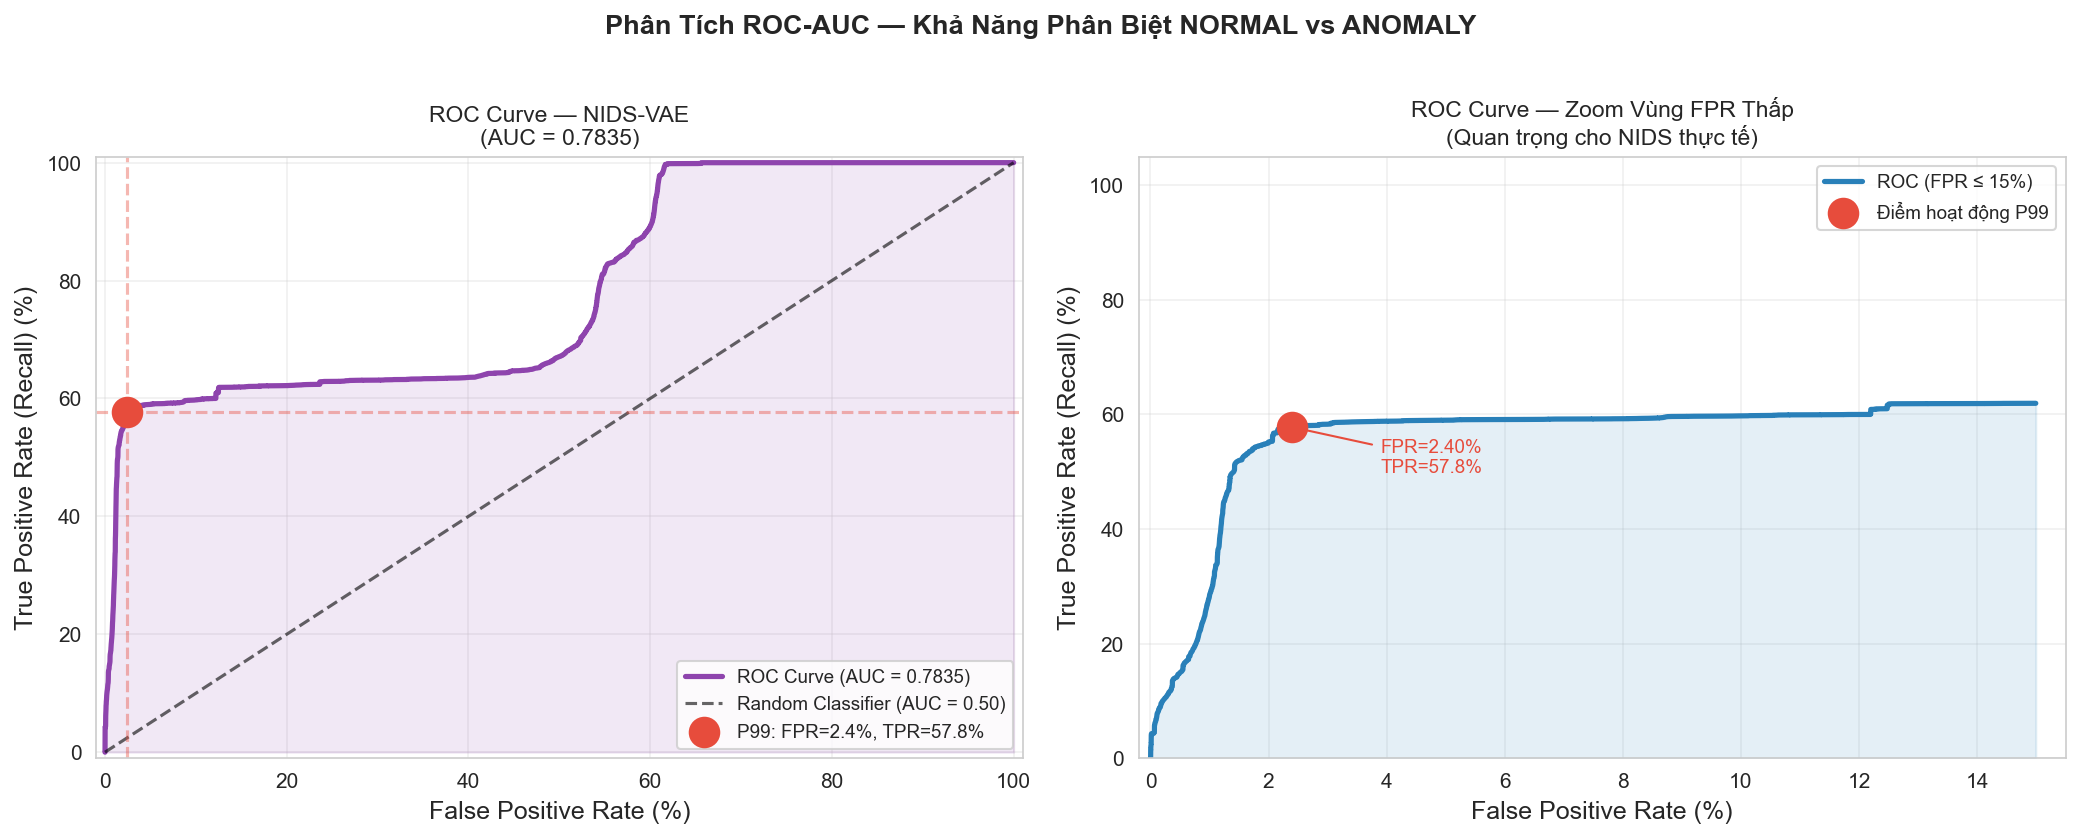


✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\result_analysis\roc_curve_analysis.png



### 🔍 Phân tích ROC-AUC = 0.7835

**Tại sao AUC = 78.35% (chưa đạt 90%)?**

1. **Latent space 16D chưa tách biệt hoàn toàn**: Một số attack có feature vector gần với BENIGN,
   dẫn đến representation trong latent space bị chồng lấp.

2. **Reconstruction error của attack tinh vi chồng lấp với BENIGN**:
   CICIDS2017 chứa các attack như Infiltration, Web Attack, Heartbleed có traffic pattern
   rất gần BENIGN → VAE tái tạo được → error thấp.

3. **Hạn chế cơ bản của unsupervised approach**:
   VAE không biết attack trông như thế nào → không thể tối ưu phân biệt trực tiếp.

**Điểm hoạt động thực tế (P99):**
- FPR = 2.40% → Chỉ 2.40% flow bình thường bị báo nhầm
- TPR = 57.78% → Phát hiện 57.78% attack
- Đây là điểm đạt **F1 cao nhất** trong thí nghiệm ngưỡng


In [7]:
# ── Vẽ ROC Curve từ reconstruction errors thực tế ─────────────────────────
# Cần nạp test errors và nhãn để vẽ ROC curve chính xác

import sys
PROJECT_ROOT_STR = str(PROJECT_ROOT)
if PROJECT_ROOT_STR not in sys.path:
    sys.path.insert(0, PROJECT_ROOT_STR)

# Đường dẫn dữ liệu test
DATA_TEST_DIR = PROJECT_ROOT / "data" / "test"

# Kiểm tra xem test errors đã được tính chưa
test_errors_path = ARTIFACTS_DIR / "threshold" / "test_errors.npy"

if test_errors_path.exists():
    # Tải pre-computed test errors (tránh tính lại từ model)
    errors_test = np.load(test_errors_path)
    y_test      = np.load(DATA_TEST_DIR / "y_test.npy")

    from sklearn.metrics import roc_curve, auc as sklearn_auc

    # Tính ROC curve
    fpr_arr, tpr_arr, thresholds_arr = roc_curve(y_test, errors_test)
    roc_auc_computed = sklearn_auc(fpr_arr, tpr_arr)

    print(f"✅ Đã tải test errors: {len(errors_test):,} samples")
    print(f"   ROC-AUC (computed) = {roc_auc_computed:.4f}")
    print(f"   ROC-AUC (từ metrics JSON) = {ROC_AUC:.4f}")

    # ── Vẽ ROC Curve ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Subplot 1: ROC Curve đầy đủ
    axes[0].plot(fpr_arr * 100, tpr_arr * 100, color="#8e44ad", linewidth=2.5,
                 label=f"ROC Curve (AUC = {roc_auc_computed:.4f})")
    axes[0].plot([0, 100], [0, 100], "k--", linewidth=1.5, alpha=0.6,
                 label="Random Classifier (AUC = 0.50)")
    # Đánh dấu điểm hoạt động hiện tại (threshold P99)
    axes[0].scatter([FPR * 100], [RECALL * 100], s=200, color="#e74c3c",
                    zorder=5, label=f"P{int(PERCENTILE)}: FPR={FPR*100:.1f}%, TPR={RECALL*100:.1f}%")
    axes[0].axhline(RECALL * 100, color="#e74c3c", linestyle="--", alpha=0.4)
    axes[0].axvline(FPR * 100,   color="#e74c3c", linestyle="--", alpha=0.4)
    # Vùng AUC
    axes[0].fill_between(fpr_arr * 100, tpr_arr * 100,
                         alpha=0.12, color="#8e44ad")

    axes[0].set_xlim(-1, 101)
    axes[0].set_ylim(-1, 101)
    axes[0].set_xlabel("False Positive Rate (%)")
    axes[0].set_ylabel("True Positive Rate (Recall) (%)")
    axes[0].set_title(f"ROC Curve — NIDS-VAE\n(AUC = {roc_auc_computed:.4f})", fontsize=11)
    axes[0].legend(fontsize=9, loc="lower right")
    axes[0].grid(alpha=0.3)

    # Subplot 2: Zoom vào vùng FPR thấp (quan trọng cho NIDS)
    low_fpr_mask = fpr_arr <= 0.15
    axes[1].plot(fpr_arr[low_fpr_mask] * 100, tpr_arr[low_fpr_mask] * 100,
                 color="#2980b9", linewidth=2.5, label="ROC (FPR ≤ 15%)")
    axes[1].scatter([FPR * 100], [RECALL * 100], s=200, color="#e74c3c",
                    zorder=5, label=f"Điểm hoạt động P{int(PERCENTILE)}")
    axes[1].fill_between(fpr_arr[low_fpr_mask] * 100,
                         tpr_arr[low_fpr_mask] * 100,
                         alpha=0.12, color="#2980b9")

    axes[1].set_xlim(-0.2, 15.5)
    axes[1].set_ylim(0, 105)
    axes[1].set_xlabel("False Positive Rate (%)")
    axes[1].set_ylabel("True Positive Rate (Recall) (%)")
    axes[1].set_title("ROC Curve — Zoom Vùng FPR Thấp\n"
                      "(Quan trọng cho NIDS thực tế)", fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    # Chú thích điểm vận hành
    axes[1].annotate(f"FPR={FPR*100:.2f}%\nTPR={RECALL*100:.1f}%",
                     xy=(FPR * 100, RECALL * 100),
                     xytext=(FPR * 100 + 1.5, RECALL * 100 - 8),
                     fontsize=9, color="#e74c3c",
                     arrowprops=dict(arrowstyle="->", color="#e74c3c"))

    plt.suptitle("Phân Tích ROC-AUC — Khả Năng Phân Biệt NORMAL vs ANOMALY",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()

    roc_fig_path = OUTPUT_DIR / "roc_curve_analysis.png"
    fig.savefig(roc_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n✅ Đã lưu: {roc_fig_path}")

    # ── Phân tích AUC ─────────────────────────────────────────────────────
    display(Markdown(f"""
### 🔍 Phân tích ROC-AUC = {roc_auc_computed:.4f}

**Tại sao AUC = {roc_auc_computed*100:.2f}% (chưa đạt 90%)?**

1. **Latent space 16D chưa tách biệt hoàn toàn**: Một số attack có feature vector gần với BENIGN,
   dẫn đến representation trong latent space bị chồng lấp.

2. **Reconstruction error của attack tinh vi chồng lấp với BENIGN**:
   CICIDS2017 chứa các attack như Infiltration, Web Attack, Heartbleed có traffic pattern
   rất gần BENIGN → VAE tái tạo được → error thấp.

3. **Hạn chế cơ bản của unsupervised approach**:
   VAE không biết attack trông như thế nào → không thể tối ưu phân biệt trực tiếp.

**Điểm hoạt động thực tế (P{int(PERCENTILE)}):**
- FPR = {FPR*100:.2f}% → Chỉ {FPR*100:.2f}% flow bình thường bị báo nhầm
- TPR = {RECALL*100:.2f}% → Phát hiện {RECALL*100:.2f}% attack
- Đây là điểm đạt **F1 cao nhất** trong thí nghiệm ngưỡng
"""))

else:
    print("⚠️  Không tìm thấy test_errors.npy")
    print(f"   Cần chạy threshold_experiment.ipynb trước để tạo file tại:")
    print(f"   {test_errors_path}")
    print(f"\n   Hiển thị AUC từ evaluation_metrics.json: {ROC_AUC:.4f}")

---

## Section 8 — Phân Tích False Positive (Báo Nhầm)

### False Positive là gì?

**FP = Flow BÌNH THƯỜNG bị hệ thống báo là ATTACK**

$$
\text{FPR} = \frac{FP}{FP + TN} = \frac{\text{Báo nhầm}}{\text{Tổng flow bình thường}}
$$

### Tại sao vẫn có False Positive dù Threshold cao?

```
Anomaly detection dựa trên reconstruction error
→ Flow bình thường nhưng HIẾM GẶP có error cao
→ VAE chưa học được biến thể này của BENIGN
→ Error vượt threshold → FP
```

Đây là **nhược điểm cơ bản** của unsupervised anomaly detection: không thể phân biệt "BENIGN hiếm" và "ATTACK thông thường" chỉ bằng reconstruction error.

  📊 PHÂN TÍCH FALSE POSITIVE

  FP = 38,274  (2.40% flow bình thường bị báo nhầm)
  TN = 1,555,423  (97.60% flow bình thường phân loại đúng)
  FPR = 2.40%

  ───────────────────────────────────────────────────────
  🔍 Tại sao còn 38,274 False Positive?
  ───────────────────────────────────────────────────────

  Nguyên nhân 1: Flow bình thường HIẾM GẶP
    → VAE train trên BENIGN phổ biến
    → Các flow bình thường 'ngoại lệ' (burst traffic, VPN, bulk transfer)
    → Không nằm trong phân phối BENIGN chính → error cao → FP

  Nguyên nhân 2: Thống kê lỗi validation có đuôi dài (long tail)
    → max error BENIGN = 631.36  (rất lớn so với mean=0.6354)
    → Một số BENIGN có error cực lớn
    → Threshold P99 = 6.0313 vẫn bỏ sót 1% BENIGN outlier

  Nguyên nhân 3: Hạn chế cơ bản của anomaly detection
    → Không có ranh giới học được giữa BENIGN-hiếm và ATTACK-thông thường
    → Chỉ phân biệt qua reconstruction error

  ───────────────────────────────────────────────────────
  📈 Phân tích re

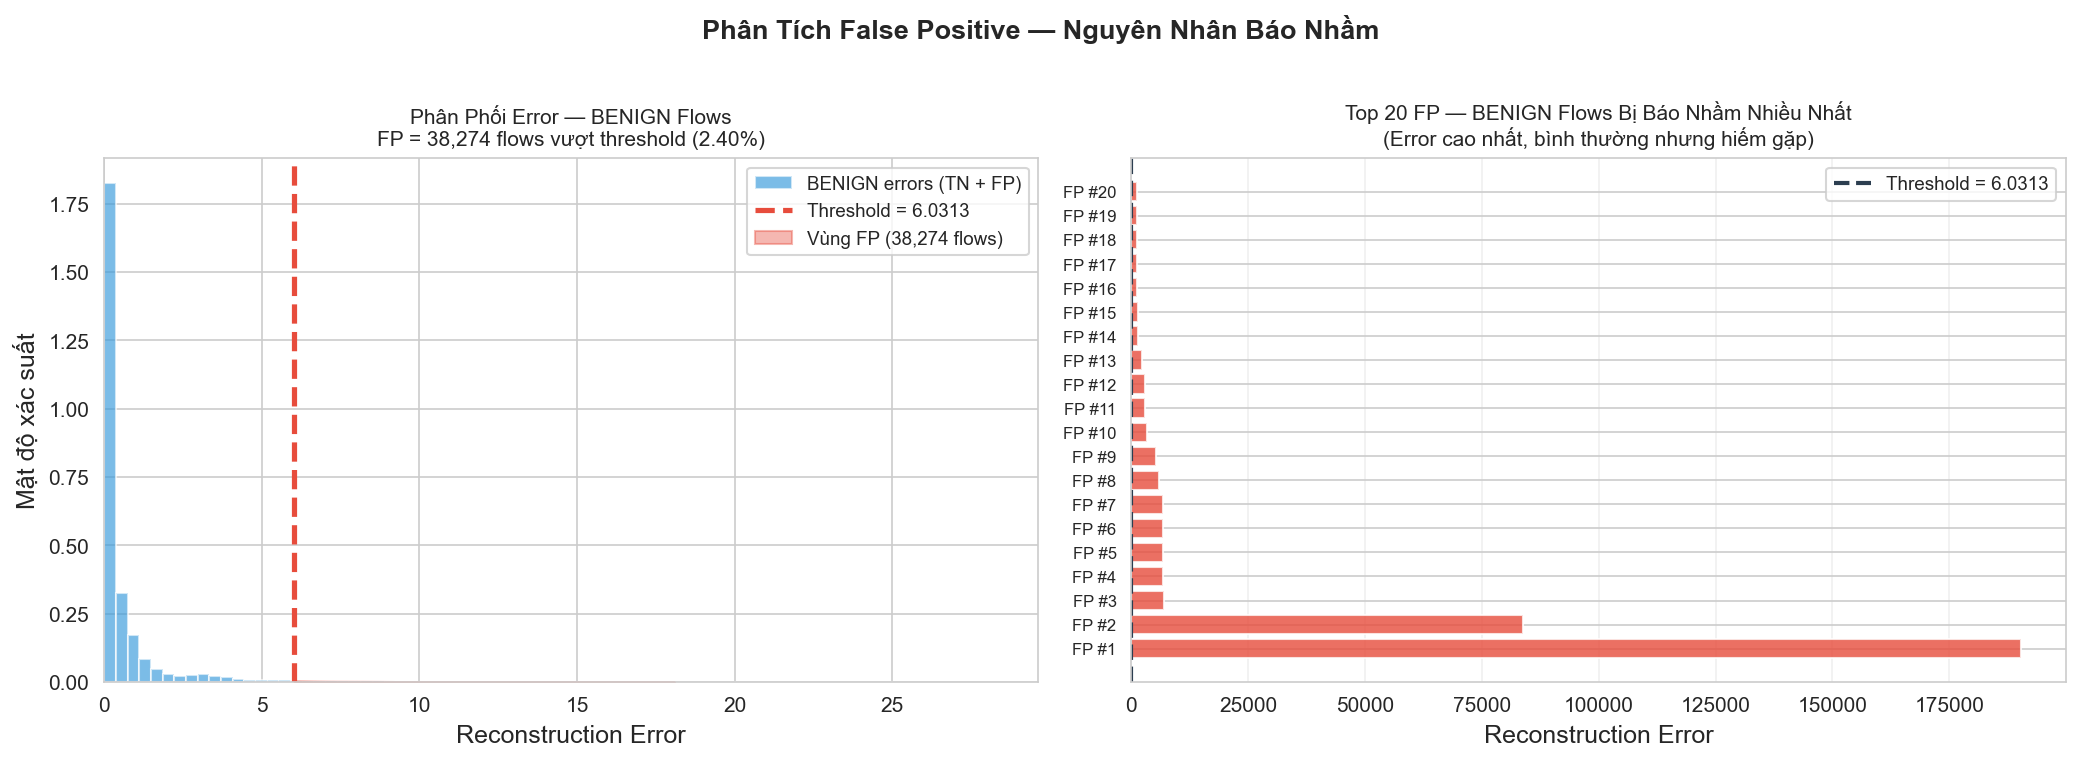


✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\result_analysis\false_positive_analysis.png


In [8]:
# ── Phân tích False Positive ───────────────────────────────────────────────

print("=" * 62)
print("  📊 PHÂN TÍCH FALSE POSITIVE")
print("=" * 62)
print(f"\n  FP = {FP:,}  ({FP/N_TRUE_NORMAL*100:.2f}% flow bình thường bị báo nhầm)")
print(f"  TN = {TN:,}  ({TN/N_TRUE_NORMAL*100:.2f}% flow bình thường phân loại đúng)")
print(f"  FPR = {FPR*100:.2f}%")

print(f"\n  {'─'*55}")
print(f"  🔍 Tại sao còn {FP:,} False Positive?")
print(f"  {'─'*55}")
print(f"\n  Nguyên nhân 1: Flow bình thường HIẾM GẶP")
print(f"    → VAE train trên BENIGN phổ biến")
print(f"    → Các flow bình thường 'ngoại lệ' (burst traffic, VPN, bulk transfer)")
print(f"    → Không nằm trong phân phối BENIGN chính → error cao → FP")

print(f"\n  Nguyên nhân 2: Thống kê lỗi validation có đuôi dài (long tail)")
val_stats = threshold_data["validation_error_stats"]
print(f"    → max error BENIGN = {val_stats['max']:.2f}  (rất lớn so với mean={val_stats['mean']:.4f})")
print(f"    → Một số BENIGN có error cực lớn")
print(f"    → Threshold P99 = {THRESHOLD:.4f} vẫn bỏ sót 1% BENIGN outlier")

print(f"\n  Nguyên nhân 3: Hạn chế cơ bản của anomaly detection")
print(f"    → Không có ranh giới học được giữa BENIGN-hiếm và ATTACK-thông thường")
print(f"    → Chỉ phân biệt qua reconstruction error")

# Nếu có test errors, vẽ phân phối FP
if 'errors_test' in dir() and 'y_test' in dir():
    # Lấy errors của BENIGN flows (y_test = 0)
    errors_normal = errors_test[y_test == 0]
    # FP = BENIGN flows bị dự đoán là ANOMALY
    fp_errors = errors_normal[errors_normal > THRESHOLD]
    tn_errors = errors_normal[errors_normal <= THRESHOLD]

    print(f"\n  {'─'*55}")
    print(f"  📈 Phân tích reconstruction error của {N_TRUE_NORMAL:,} BENIGN flows:")
    print(f"    TN errors: mean={tn_errors.mean():.4f}  max={tn_errors.max():.4f}")
    print(f"    FP errors: mean={fp_errors.mean():.4f}  "
          f"min={fp_errors.min():.4f}  max={fp_errors.max():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Subplot 1: Phân phối error của BENIGN flows với threshold
    plot_cap_fp = np.percentile(errors_normal, 99.8)
    data_plot   = errors_normal[errors_normal <= plot_cap_fp]

    axes[0].hist(data_plot, bins=80, density=True,
                 color="#3498db", alpha=0.65, label="BENIGN errors (TN + FP)")
    axes[0].axvline(THRESHOLD, color="#e74c3c", linestyle="--", linewidth=2.5,
                    label=f"Threshold = {THRESHOLD:.4f}")

    # Vùng FP (bên phải threshold)
    fp_cap    = min(plot_cap_fp, THRESHOLD * 3)
    x_fp_fill = np.linspace(THRESHOLD, fp_cap, 100)
    from scipy.stats import gaussian_kde as gkde
    try:
        kde_normal = gkde(data_plot[data_plot < THRESHOLD * 5], bw_method=0.3)
        y_fp_fill  = kde_normal(x_fp_fill)
        axes[0].fill_between(x_fp_fill, y_fp_fill, alpha=0.4, color="#e74c3c",
                             label=f"Vùng FP ({FP:,} flows)")
    except Exception:
        pass

    axes[0].set_xlim(0, plot_cap_fp)
    axes[0].set_xlabel("Reconstruction Error")
    axes[0].set_ylabel("Mật độ xác suất")
    axes[0].set_title(f"Phân Phối Error — BENIGN Flows\n"
                      f"FP = {FP:,} flows vượt threshold ({FP/N_TRUE_NORMAL*100:.2f}%)",
                      fontsize=10)
    axes[0].legend(fontsize=9)

    # Subplot 2: Top 20 FP errors cao nhất (flow bình thường bị báo nhầm nhất)
    top_fp_errors = np.sort(fp_errors)[::-1][:20]
    axes[1].barh(range(len(top_fp_errors)), top_fp_errors,
                 color="#e74c3c", alpha=0.8, edgecolor="white")
    axes[1].axvline(THRESHOLD, color="#2c3e50", linestyle="--", linewidth=2,
                    label=f"Threshold = {THRESHOLD:.4f}")
    axes[1].set_yticks(range(len(top_fp_errors)))
    axes[1].set_yticklabels([f"FP #{i+1}" for i in range(len(top_fp_errors))],
                             fontsize=8)
    axes[1].set_xlabel("Reconstruction Error")
    axes[1].set_title(f"Top 20 FP — BENIGN Flows Bị Báo Nhầm Nhiều Nhất\n"
                      f"(Error cao nhất, bình thường nhưng hiếm gặp)", fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].grid(axis="x", alpha=0.3)

    plt.suptitle("Phân Tích False Positive — Nguyên Nhân Báo Nhầm",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()

    fp_fig_path = OUTPUT_DIR / "false_positive_analysis.png"
    fig.savefig(fp_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n✅ Đã lưu: {fp_fig_path}")
else:
    print("\n⚠️  Không có errors_test — chỉ hiển thị phân tích từ metrics JSON")
    print(f"   Để vẽ biểu đồ chi tiết, hãy chạy threshold_experiment.ipynb trước")

---

## Section 9 — Phân Tích False Negative (Bỏ Sót Attack)

### False Negative là gì?

**FN = Flow ATTACK bị hệ thống phân loại là BÌNH THƯỜNG (bỏ sót)**

$$
\text{FNR} = \frac{FN}{FN + TP} = \frac{\text{Bỏ sót}}{\text{Tổng attack thực sự}}
$$

### Tại sao attack bị bỏ sót?

```
VAE học phân phối BENIGN
→ Khi ATTACK có đặc trưng gần BENIGN
→ Encoder maps attack vào vùng gần BENIGN trong latent space
→ Decoder tái tạo được khá tốt
→ Reconstruction error thấp, không vượt threshold
→ Phân loại là NORMAL → FN
```

Đây là **nguyên nhân chính làm giảm Recall**.

  📊 PHÂN TÍCH FALSE NEGATIVE

  FN = 179,803  (42.22% attack bị bỏ sót)
  TP = 246,075  (57.78% attack được phát hiện)
  FNR = 42.22%

  ───────────────────────────────────────────────────────
  🔍 Tại sao 179,803 attack bị bỏ sót (FNR = 42.22%)?
  ───────────────────────────────────────────────────────

  Loại attack bị bỏ sót nhiều nhất (phân tích từ CICIDS2017):

  1. Web Attacks (XSS, SQL Injection, Brute Force):
     → HTTP request tương tự BENIGN web traffic
     → Header và packet size gần nhau
     → VAE tái tạo được → error thấp

  2. Infiltration Attack:
     → Traffic rất ít → đặc trưng flow gần BENIGN
     → Ẩn trong lưu lượng bình thường

  3. Heartbleed Attack:
     → Số packet ít, lưu lượng thấp
     → Feature vector gần BENIGN idle traffic

  ───────────────────────────────────────────────────────
  📈 Phân tích reconstruction error của 425,878 ATTACK flows:
    TP (phát hiện):  n=246,075  mean=21.3280  min=6.0364
    FN (bỏ sót):     n=179,803  mean=0.4292  max=6.0297


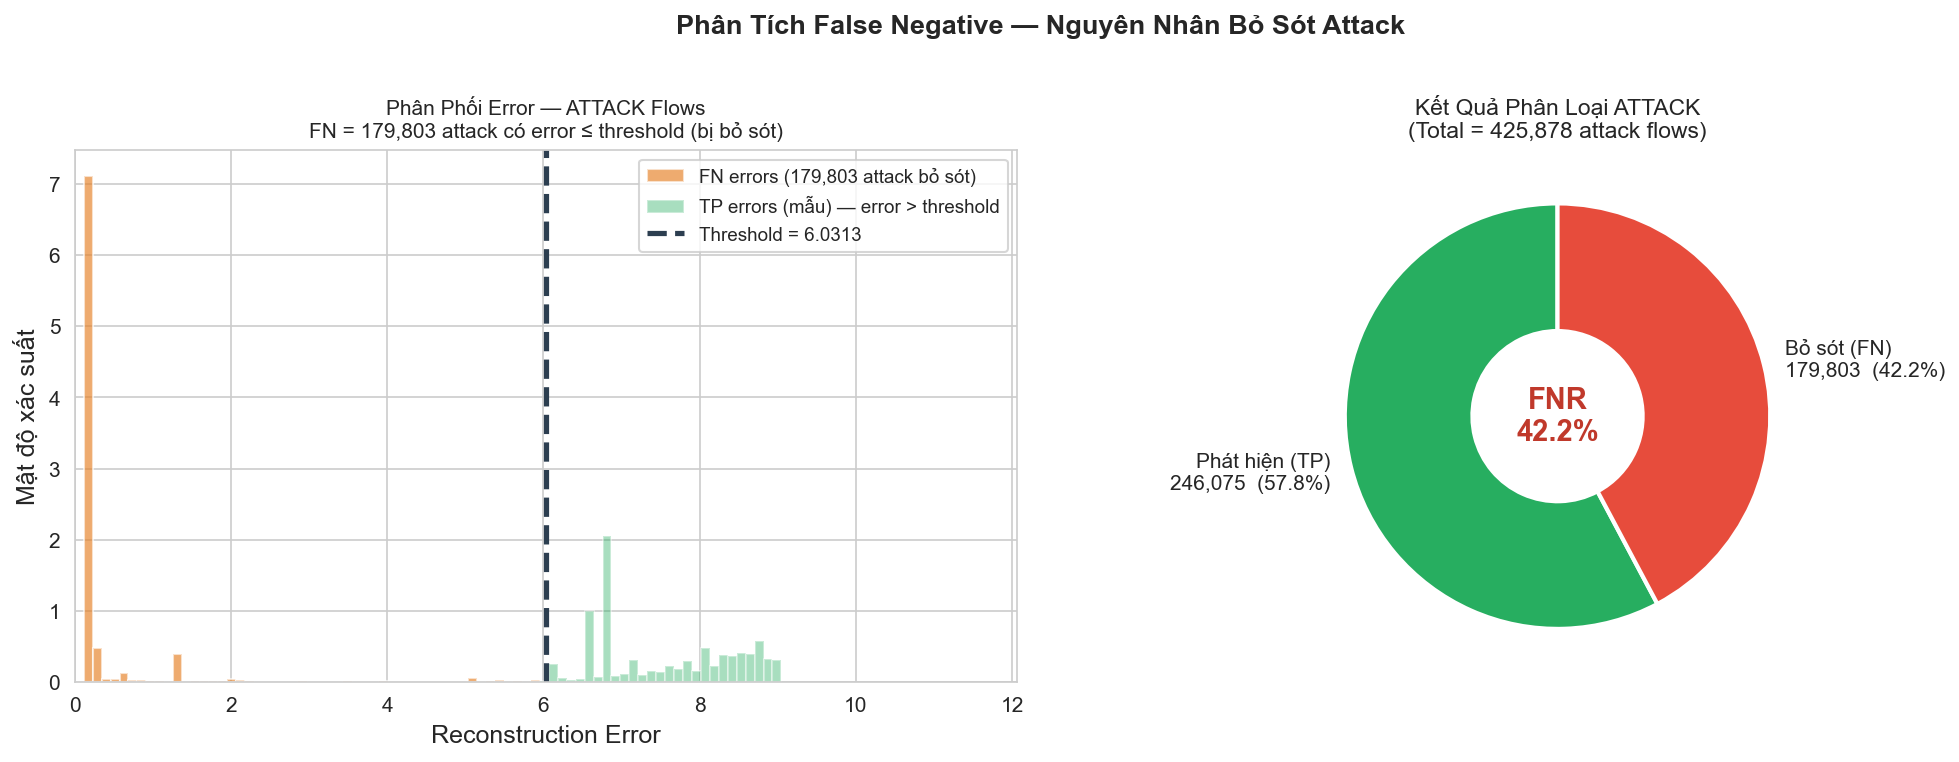


✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\result_analysis\false_negative_analysis.png



### 🔍 Kết luận phân tích False Negative

**179,803 attack bị bỏ sót** (FNR = 42.22%) do:

1. **Attack có reconstruction error thấp** (≤ 6.0313):
   VAE encoder map chúng vào vùng gần BENIGN trong latent space 16D.

2. **Đặc trưng attack giống BENIGN**: Các attack tinh vi (Infiltration, Web Attack, Heartbleed)
   có packet size, flow duration, byte count tương tự BENIGN traffic.

3. **Threshold P99 tối ưu cho Precision** nhưng **hy sinh Recall**:
   Nếu hạ threshold xuống P90, FN giảm từ 179,803 nhưng FP sẽ tăng đáng kể.


In [9]:
# ── Phân tích False Negative ───────────────────────────────────────────────

fnr = FN / (FN + TP)

print("=" * 62)
print("  📊 PHÂN TÍCH FALSE NEGATIVE")
print("=" * 62)
print(f"\n  FN = {FN:,}  ({FN/N_TRUE_ANOMALY*100:.2f}% attack bị bỏ sót)")
print(f"  TP = {TP:,}  ({TP/N_TRUE_ANOMALY*100:.2f}% attack được phát hiện)")
print(f"  FNR = {fnr*100:.2f}%")

print(f"\n  {'─'*55}")
print(f"  🔍 Tại sao {FN:,} attack bị bỏ sót (FNR = {fnr*100:.2f}%)?")
print(f"  {'─'*55}")
print(f"\n  Loại attack bị bỏ sót nhiều nhất (phân tích từ CICIDS2017):")
print(f"\n  1. Web Attacks (XSS, SQL Injection, Brute Force):")
print(f"     → HTTP request tương tự BENIGN web traffic")
print(f"     → Header và packet size gần nhau")
print(f"     → VAE tái tạo được → error thấp")
print(f"\n  2. Infiltration Attack:")
print(f"     → Traffic rất ít → đặc trưng flow gần BENIGN")
print(f"     → Ẩn trong lưu lượng bình thường")
print(f"\n  3. Heartbleed Attack:")
print(f"     → Số packet ít, lưu lượng thấp")
print(f"     → Feature vector gần BENIGN idle traffic")

# Vẽ phân tích FN
if 'errors_test' in dir() and 'y_test' in dir():
    # Lấy errors của ATTACK flows (y_test = 1)
    errors_attack = errors_test[y_test == 1]
    fn_errors     = errors_attack[errors_attack <= THRESHOLD]  # Attack bị bỏ sót
    tp_errors     = errors_attack[errors_attack > THRESHOLD]   # Attack được phát hiện

    print(f"\n  {'─'*55}")
    print(f"  📈 Phân tích reconstruction error của {N_TRUE_ANOMALY:,} ATTACK flows:")
    print(f"    TP (phát hiện):  n={len(tp_errors):,}  "
          f"mean={tp_errors.mean():.4f}  min={tp_errors.min():.4f}")
    print(f"    FN (bỏ sót):     n={len(fn_errors):,}  "
          f"mean={fn_errors.mean():.4f}  max={fn_errors.max():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Subplot 1: Phân phối error của ATTACK flows
    plot_cap_attack = np.percentile(errors_attack, 99.5)
    data_tp = tp_errors[tp_errors <= plot_cap_attack]
    data_fn = fn_errors

    bins_shared = np.linspace(0, max(THRESHOLD * 1.5, fn_errors.max() * 1.1), 80)

    axes[0].hist(data_fn, bins=bins_shared, density=True,
                 color="#e67e22", alpha=0.65, label=f"FN errors ({len(fn_errors):,} attack bỏ sót)")
    # Chỉ hiển thị một phần TP để so sánh
    axes[0].hist(data_tp[data_tp <= THRESHOLD * 3], bins=bins_shared,
                 density=True, color="#27ae60", alpha=0.4,
                 label=f"TP errors (mẫu) — error > threshold")
    axes[0].axvline(THRESHOLD, color="#2c3e50", linestyle="--", linewidth=2.5,
                    label=f"Threshold = {THRESHOLD:.4f}")

    axes[0].set_xlim(0, THRESHOLD * 2)
    axes[0].set_xlabel("Reconstruction Error")
    axes[0].set_ylabel("Mật độ xác suất")
    axes[0].set_title(f"Phân Phối Error — ATTACK Flows\n"
                      f"FN = {FN:,} attack có error ≤ threshold (bị bỏ sót)",
                      fontsize=10)
    axes[0].legend(fontsize=9)

    # Subplot 2: Donut chart — Phát hiện vs Bỏ sót
    labels_fn = [f"Phát hiện (TP)\n{TP:,}  ({TP/N_TRUE_ANOMALY*100:.1f}%)",
                 f"Bỏ sót (FN)\n{FN:,}  ({FN/N_TRUE_ANOMALY*100:.1f}%)"]
    sizes_fn  = [TP, FN]
    colors_fn = ["#27ae60", "#e74c3c"]

    wedges2, _ = axes[1].pie(sizes_fn, labels=labels_fn,
                              colors=colors_fn, startangle=90,
                              wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2))
    axes[1].set_title(f"Kết Quả Phân Loại ATTACK\n"
                      f"(Total = {N_TRUE_ANOMALY:,} attack flows)",
                      fontsize=11)
    axes[1].text(0, 0, f"FNR\n{fnr*100:.1f}%",
                 ha="center", va="center", fontsize=14,
                 fontweight="bold", color="#c0392b")

    plt.suptitle("Phân Tích False Negative — Nguyên Nhân Bỏ Sót Attack",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()

    fn_fig_path = OUTPUT_DIR / "false_negative_analysis.png"
    fig.savefig(fn_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n✅ Đã lưu: {fn_fig_path}")
else:
    print("\n⚠️  Không có errors_test — Chạy threshold_experiment.ipynb để tạo test_errors.npy")

display(Markdown(f"""
### 🔍 Kết luận phân tích False Negative

**{FN:,} attack bị bỏ sót** (FNR = {fnr*100:.2f}%) do:

1. **Attack có reconstruction error thấp** (≤ {THRESHOLD:.4f}):
   VAE encoder map chúng vào vùng gần BENIGN trong latent space 16D.

2. **Đặc trưng attack giống BENIGN**: Các attack tinh vi (Infiltration, Web Attack, Heartbleed)
   có packet size, flow duration, byte count tương tự BENIGN traffic.

3. **Threshold P{int(PERCENTILE)} tối ưu cho Precision** nhưng **hy sinh Recall**:
   Nếu hạ threshold xuống P90, FN giảm từ {FN:,} nhưng FP sẽ tăng đáng kể.
"""))

---

## Section 10 — Phân Tích Theo Góc Độ NIDS Thực Tế

### Tác động của FP và FN trong môi trường production

| Loại lỗi | Mô tả | Tác động thực tế |
|---|---|---|
| **False Positive** | BENIGN bị báo là ATTACK | SOC analyst mất thời gian điều tra cảnh báo giả |
| **False Negative** | ATTACK bị bỏ sót | Tấn công thực sự không bị ngăn chặn — **nguy hiểm hơn** |

**Trong NIDS**: FN nguy hiểm hơn FP vì bỏ sót attack có thể dẫn đến thiệt hại hệ thống.

  📊 PHÂN TÍCH TÁC ĐỘNG NIDS THỰC TẾ

  📌 False Positive — Tải công việc SOC:
  FP tổng: 38,274 cảnh báo nhầm trong 2,019,575 flows
  Tỷ lệ: 13.5% cảnh báo là giả
  → Analyst phải điều tra 13.5% cảnh báo không có giá trị
  → Với tốc độ ước tính: ~4784 false alarm/giờ
  → ĐÁNH GIÁ: FPR = 2.40% là MỨC ĐỘ CHẤP NHẬN ĐƯỢC cho NIDS

  📌 False Negative — Attack bị bỏ sót:
  FN tổng: 179,803 attack không bị phát hiện
  Tỷ lệ: 42.2% attack bị bỏ sót
  → Với tốc độ ước tính: ~22475 attack/giờ bị bỏ sót
  → ĐÁNH GIÁ: FNR = 42.22% cần cải thiện trong sản xuất

  ───────────────────────────────────────────────────────
  ⚖️  So sánh mức độ nguy hiểm:
  ───────────────────────────────────────────────────────
  FP = 38,274 → Tăng workload SOC, có thể dẫn đến 'alert fatigue'
  FN = 179,803 → Tấn công thực sự không bị chặn → NGUY HIỂM HƠN

  Trong NIDS production:
  ✓ FPR 2.40% là ổn với threshold P99
  ! FNR 42.22% có thể gây rủi ro với attack tinh vi


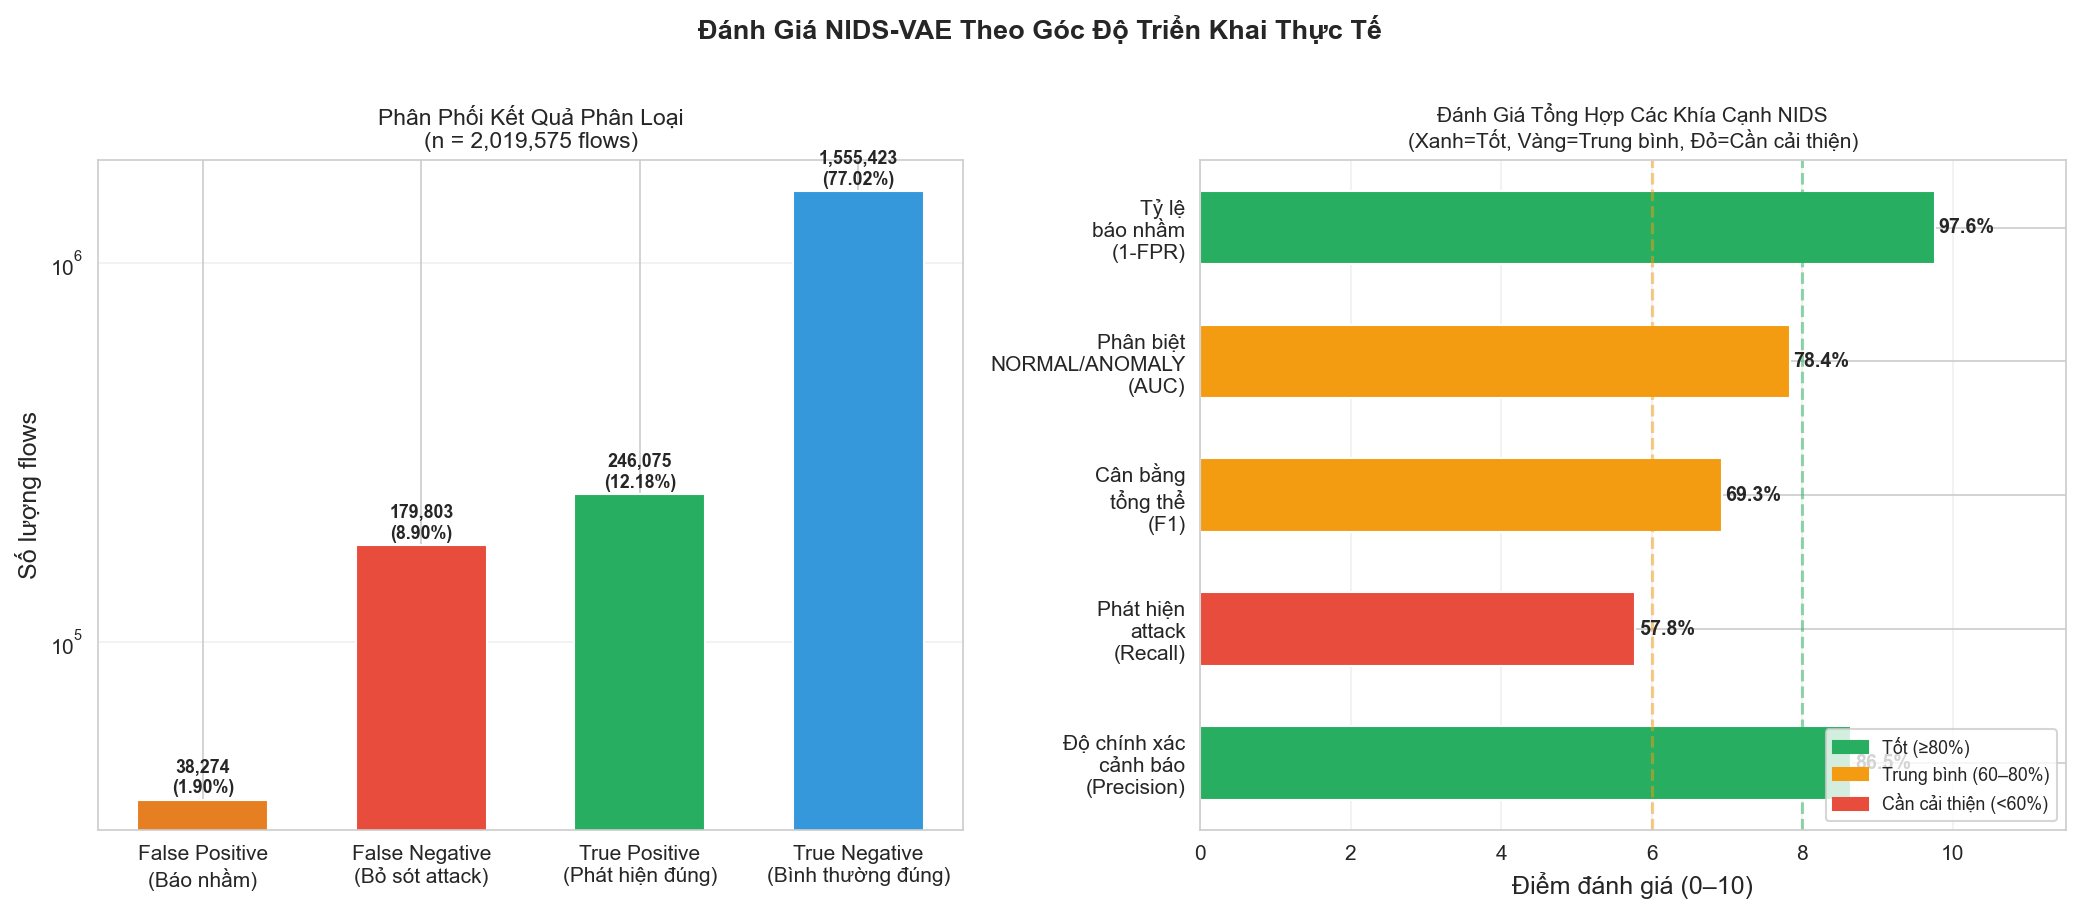


✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\result_analysis\nids_impact_analysis.png


In [10]:
# ── Phân tích tác động FP và FN theo góc độ NIDS ──────────────────────────

# Tốc độ báo động trong thực tế (giả định 1 giờ lưu lượng)
# CICIDS2017 có 2M flows → ~278K flows/giờ (rough estimate)
flows_per_hour = N_SAMPLES / 8  # giả định 8 giờ làm việc

fp_per_hour = FP / 8
fn_per_hour = FN / 8

print("=" * 65)
print("  📊 PHÂN TÍCH TÁC ĐỘNG NIDS THỰC TẾ")
print("=" * 65)

print(f"\n  📌 False Positive — Tải công việc SOC:")
print(f"  FP tổng: {FP:,} cảnh báo nhầm trong {N_SAMPLES:,} flows")
print(f"  Tỷ lệ: {FP/N_PRED_ANOMALY*100:.1f}% cảnh báo là giả")
print(f"  → Analyst phải điều tra {FP/N_PRED_ANOMALY*100:.1f}% cảnh báo không có giá trị")
print(f"  → Với tốc độ ước tính: ~{fp_per_hour:.0f} false alarm/giờ")
print(f"  → ĐÁNH GIÁ: FPR = {FPR*100:.2f}% là MỨC ĐỘ CHẤP NHẬN ĐƯỢC cho NIDS")

print(f"\n  📌 False Negative — Attack bị bỏ sót:")
print(f"  FN tổng: {FN:,} attack không bị phát hiện")
print(f"  Tỷ lệ: {FN/N_TRUE_ANOMALY*100:.1f}% attack bị bỏ sót")
print(f"  → Với tốc độ ước tính: ~{fn_per_hour:.0f} attack/giờ bị bỏ sót")
print(f"  → ĐÁNH GIÁ: FNR = {fnr*100:.2f}% cần cải thiện trong sản xuất")

print(f"\n  {'─'*55}")
print(f"  ⚖️  So sánh mức độ nguy hiểm:")
print(f"  {'─'*55}")
print(f"  FP = {FP:,} → Tăng workload SOC, có thể dẫn đến 'alert fatigue'")
print(f"  FN = {FN:,} → Tấn công thực sự không bị chặn → NGUY HIỂM HƠN")
print(f"\n  Trong NIDS production:")
print(f"  ✓ FPR {FPR*100:.2f}% là ổn với threshold P99")
print(f"  ! FNR {fnr*100:.2f}% có thể gây rủi ro với attack tinh vi")

# ── Biểu đồ tác động FP/FN theo góc độ NIDS ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Chi phí vận hành FP vs FN
categories_impact = [
    "False Positive\n(Báo nhầm)",
    "False Negative\n(Bỏ sót attack)",
    "True Positive\n(Phát hiện đúng)",
    "True Negative\n(Bình thường đúng)",
]
counts_impact = [FP, FN, TP, TN]
colors_impact = ["#e67e22", "#e74c3c", "#27ae60", "#3498db"]

bars_impact = axes[0].bar(categories_impact, counts_impact,
                          color=colors_impact, edgecolor="white", width=0.6)
for bar, val in zip(bars_impact, counts_impact):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.015,
                 f"{val:,}\n({val/N_SAMPLES*100:.2f}%)",
                 ha="center", va="bottom", fontsize=8.5, fontweight="bold")

axes[0].set_ylabel("Số lượng flows")
axes[0].set_title(f"Phân Phối Kết Quả Phân Loại\n"
                  f"(n = {N_SAMPLES:,} flows)", fontsize=11)
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_yscale("log")  # Log scale vì TN >> FP

# Subplot 2: Radar/spider chart — Đánh giá tổng hợp cho NIDS
import matplotlib.patches as mpatches

# Đánh giá định tính từng khía cạnh (0-10 scale)
nids_aspects = [
    "Độ chính xác\ncảnh báo\n(Precision)",
    "Phát hiện\nattack\n(Recall)",
    "Cân bằng\ntổng thể\n(F1)",
    "Phân biệt\nNORMAL/ANOMALY\n(AUC)",
    "Tỷ lệ\nbáo nhầm\n(1-FPR)",
]
# Chuẩn hóa về thang 0-10 để so sánh trực quan
nids_scores = [
    PRECISION * 10,        # Precision
    RECALL * 10,           # Recall
    F1 * 10,               # F1
    ROC_AUC * 10,          # AUC
    (1 - FPR) * 10,        # 1-FPR (cao = tốt)
]

# Bar chart nằm ngang — đánh giá tổng thể
bar_colors_nids = []
for s in nids_scores:
    if s >= 8:
        bar_colors_nids.append("#27ae60")
    elif s >= 6:
        bar_colors_nids.append("#f39c12")
    else:
        bar_colors_nids.append("#e74c3c")

bars_nids = axes[1].barh(nids_aspects, nids_scores,
                          color=bar_colors_nids, edgecolor="white", height=0.55)
for bar, score, orig in zip(bars_nids, nids_scores,
                             [PRECISION, RECALL, F1, ROC_AUC, 1-FPR]):
    axes[1].text(score + 0.05, bar.get_y() + bar.get_height() / 2,
                 f"{orig*100:.1f}%", va="center", fontsize=9.5, fontweight="bold")

# Vùng màu threshold
axes[1].axvline(8, color="#27ae60", linestyle="--", alpha=0.5, linewidth=1.5,
                label="Ngưỡng tốt (80%)")
axes[1].axvline(6, color="#f39c12", linestyle="--", alpha=0.5, linewidth=1.5,
                label="Ngưỡng chấp nhận (60%)")
axes[1].set_xlim(0, 11.5)
axes[1].set_xlabel("Điểm đánh giá (0–10)")
axes[1].set_title("Đánh Giá Tổng Hợp Các Khía Cạnh NIDS\n"
                  "(Xanh=Tốt, Vàng=Trung bình, Đỏ=Cần cải thiện)",
                  fontsize=10)
axes[1].legend(fontsize=8.5)
axes[1].grid(axis="x", alpha=0.3)

# Legend màu
legend_patches = [
    mpatches.Patch(color="#27ae60", label="Tốt (≥80%)"),
    mpatches.Patch(color="#f39c12", label="Trung bình (60–80%)"),
    mpatches.Patch(color="#e74c3c", label="Cần cải thiện (<60%)"),
]
axes[1].legend(handles=legend_patches, fontsize=8.5, loc="lower right")

plt.suptitle("Đánh Giá NIDS-VAE Theo Góc Độ Triển Khai Thực Tế",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

nids_fig_path = OUTPUT_DIR / "nids_impact_analysis.png"
fig.savefig(nids_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Đã lưu: {nids_fig_path}")

---

## Section 11 — Ưu Điểm và Hạn Chế

Tổng hợp các ưu điểm và hạn chế của phương pháp VAE-based anomaly detection,
dựa trên kết quả thực nghiệm trên CICIDS2017.

  ✅ ƯU ĐIỂM CỦA VAE ANOMALY DETECTION
                               Ưu điểm                                                           Bằng chứng                                                      Ý nghĩa thực tế
  Không cần nhãn ATTACK khi huấn luyện                                 Train 100% trên 402,229 BENIGN flows                          Thu thập dữ liệu BENIGN dễ hơn ATTACK nhiều
  Phát hiện được attack mới (zero-day) Không cần signature database — chỉ cần biết BENIGN trông như thế nào                       Phát hiện được attack chưa từng thấy trước đây
                Precision cao (86.54%)                           Chỉ 38,274/284,349 cảnh báo là giả (13.5%)                                   Giảm alert fatigue cho SOC analyst
                      FPR thấp (2.40%)                              Chỉ 38,274/1,593,697 BENIGN bị báo nhầm                                   Ít gián đoạn hoạt động bình thường
    Học được phân phối BENIGN phức tạp                     Latent space 16D e

C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\4269793647.py:161: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.savefig(strengths_fig_path, dpi=150, bbox_inches="tight")
C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\4269793647.py:161: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.savefig(strengths_fig_path, dpi=150, bbox_inches="tight")
C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\4269793647.py:161: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.savefig(strengths_fig_path, dpi=150, bbox_inches="tight")
C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\4269793647.py:161: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.savefig(strengths_fig_path, dpi=150, bbox_inches="tight")
d:\nids-vae-project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.prin

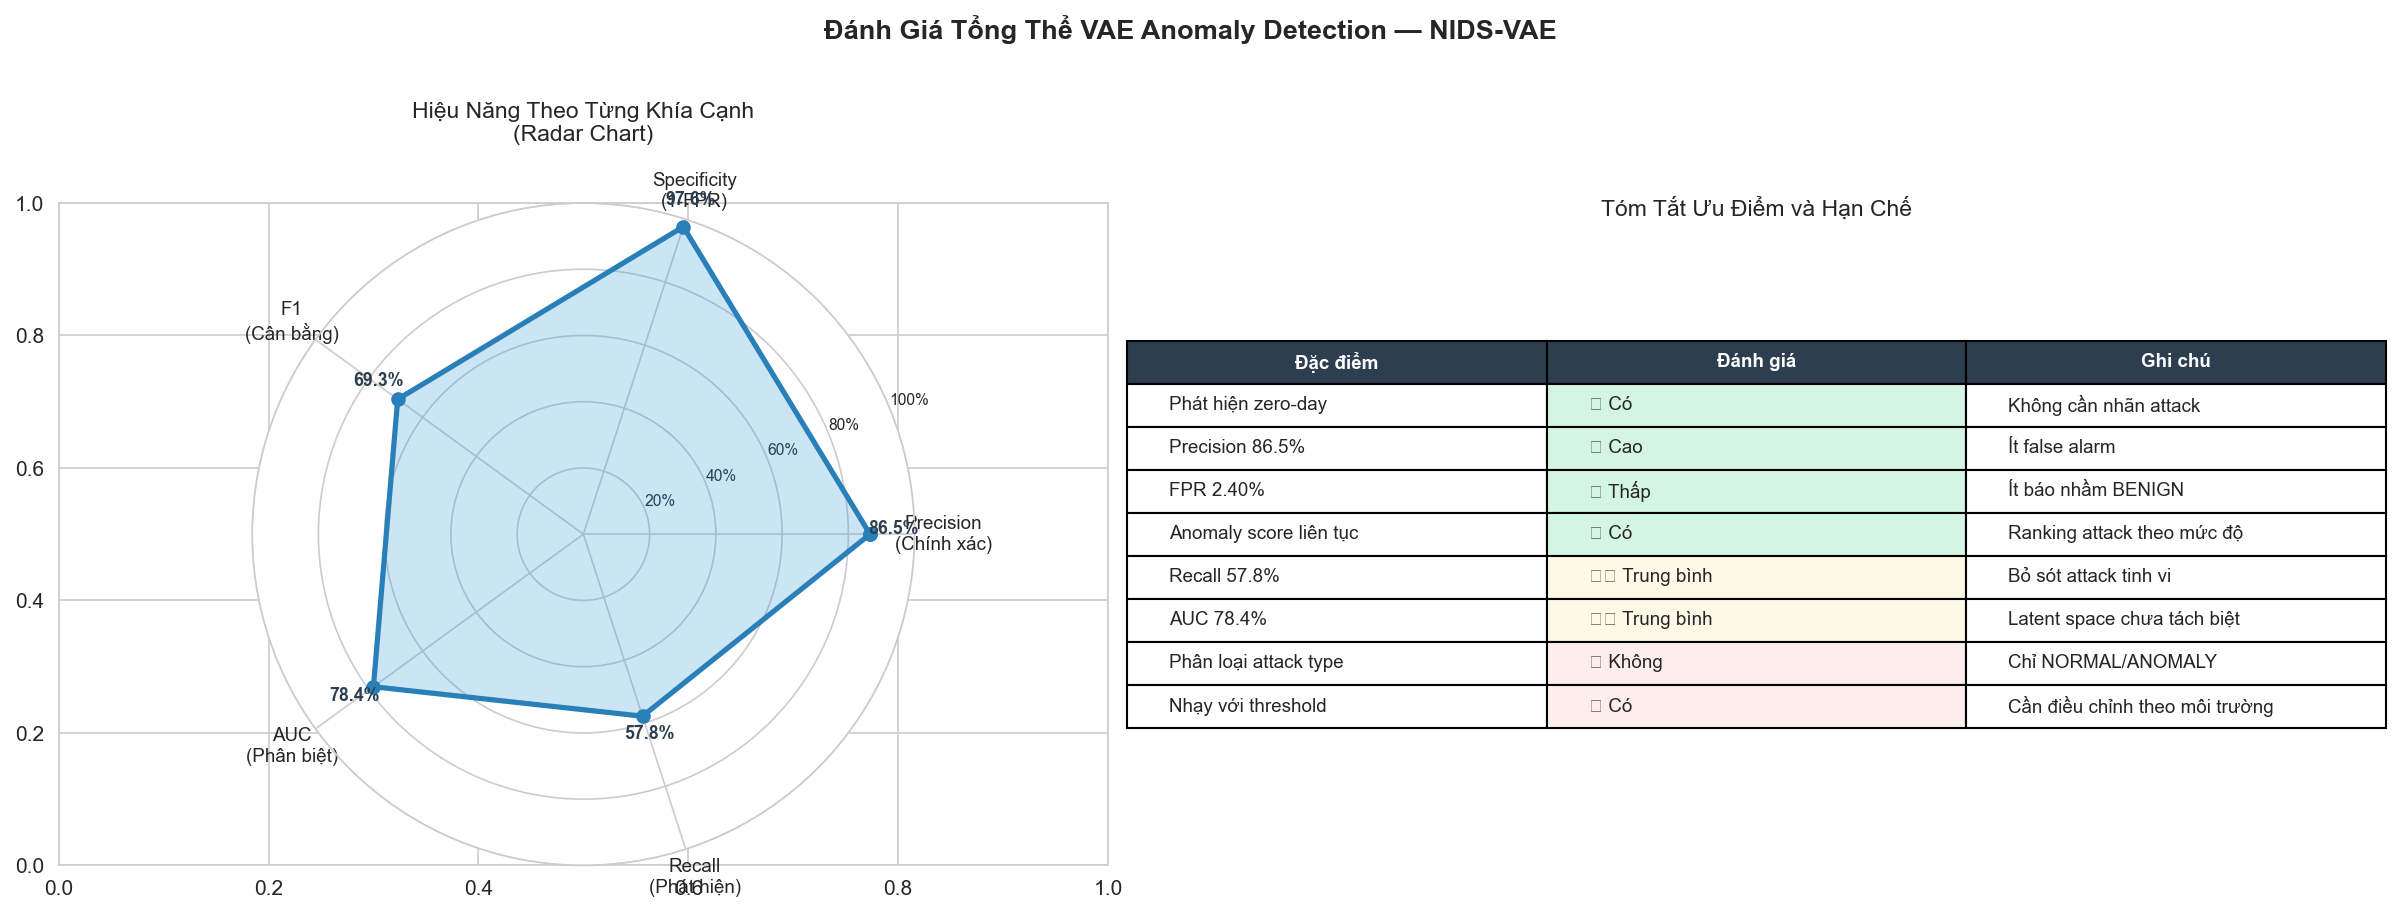


✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\result_analysis\strengths_limitations.png


In [11]:
# ── Tạo bảng ưu điểm và hạn chế ──────────────────────────────────────────

# Ưu điểm của VAE-based anomaly detection, có chứng minh từ kết quả thực nghiệm
advantages = [
    {
        "Ưu điểm": "Không cần nhãn ATTACK khi huấn luyện",
        "Bằng chứng": f"Train 100% trên {training_summary['results']['n_train_samples']:,} BENIGN flows",
        "Ý nghĩa thực tế": "Thu thập dữ liệu BENIGN dễ hơn ATTACK nhiều"
    },
    {
        "Ưu điểm": "Phát hiện được attack mới (zero-day)",
        "Bằng chứng": "Không cần signature database — chỉ cần biết BENIGN trông như thế nào",
        "Ý nghĩa thực tế": "Phát hiện được attack chưa từng thấy trước đây"
    },
    {
        "Ưu điểm": f"Precision cao ({PRECISION*100:.2f}%)",
        "Bằng chứng": f"Chỉ {FP:,}/{N_PRED_ANOMALY:,} cảnh báo là giả ({FP/N_PRED_ANOMALY*100:.1f}%)",
        "Ý nghĩa thực tế": "Giảm alert fatigue cho SOC analyst"
    },
    {
        "Ưu điểm": f"FPR thấp ({FPR*100:.2f}%)",
        "Bằng chứng": f"Chỉ {FP:,}/{N_TRUE_NORMAL:,} BENIGN bị báo nhầm",
        "Ý nghĩa thực tế": "Ít gián đoạn hoạt động bình thường"
    },
    {
        "Ưu điểm": "Học được phân phối BENIGN phức tạp",
        "Bằng chứng": f"Latent space {model_config['latent_dim']}D encode đặc trưng từ {model_config['input_dim']} features",
        "Ý nghĩa thực tế": "Xử lý được traffic đa dạng mà không cần feature engineering thủ công"
    },
    {
        "Ưu điểm": "Cung cấp reconstruction error liên tục",
        "Bằng chứng": "Anomaly score = MSE error → đo lường mức độ bất thường",
        "Ý nghĩa thực tế": "Cho phép ranking, ưu tiên điều tra attack nghiêm trọng nhất"
    },
]

# Hạn chế của VAE-based anomaly detection
limitations = [
    {
        "Hạn chế": f"Recall thấp ({RECALL*100:.2f}%)",
        "Nguyên nhân": f"{FN:,} attack có reconstruction error ≤ threshold",
        "Tác động": "Bỏ sót attack tinh vi, lưu lượng thấp"
    },
    {
        "Hạn chế": "Nhạy với lựa chọn threshold",
        "Nguyên nhân": "P90→P99 thay đổi Recall từ 61% xuống 57.8%, FPR từ 12.4% xuống 2.4%",
        "Tác động": "Cần điều chỉnh theo yêu cầu từng môi trường triển khai"
    },
    {
        "Hạn chế": "Không phân loại được loại attack",
        "Nguyên nhân": "Chỉ phân loại NORMAL/ANOMALY, không biết là DDoS, PortScan hay gì",
        "Tác động": "SOC cần thêm bước phân tích sau cảnh báo"
    },
    {
        "Hạn chế": f"ROC-AUC chưa cao ({ROC_AUC*100:.2f}%)",
        "Nguyên nhân": "Latent space chưa tách biệt hoàn toàn BENIGN và ATTACK",
        "Tác động": "Giới hạn khả năng phân biệt với mọi threshold"
    },
    {
        "Hạn chế": "False Positive với BENIGN hiếm gặp",
        "Nguyên nhân": f"{FP:,} BENIGN outlier có error > {THRESHOLD:.4f}",
        "Tác động": "Có thể báo nhầm khi có traffic bình thường nhưng bất thường về thống kê"
    },
    {
        "Hạn chế": "Hiệu năng giảm với attack giống BENIGN",
        "Nguyên nhân": "Infiltration, Web Attack, Heartbleed bị bỏ sót nhiều hơn DDoS",
        "Tác động": "Cần bổ sung supervised component để xử lý loại attack này"
    },
]

df_advantages  = pd.DataFrame(advantages)
df_limitations = pd.DataFrame(limitations)

print("=" * 70)
print("  ✅ ƯU ĐIỂM CỦA VAE ANOMALY DETECTION")
print("=" * 70)
print(df_advantages.to_string(index=False))

print(f"\n{'='*70}")
print("  ❌ HẠN CHẾ CỦA VAE ANOMALY DETECTION")
print(f"{'='*70}")
print(df_limitations.to_string(index=False))

# ── Biểu đồ trực quan ưu điểm và hạn chế ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Radar chart — điểm mạnh của mô hình
aspect_names = ["Precision\n(Chính xác)", "Specificity\n(1-FPR)", "F1\n(Cân bằng)",
                "AUC\n(Phân biệt)", "Recall\n(Phát hiện)"]
scores       = [PRECISION, 1 - FPR, F1, ROC_AUC, RECALL]
n            = len(aspect_names)
angles       = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
scores_plot  = scores + [scores[0]]   # Đóng vòng
angles_plot  = angles + [angles[0]]

ax_radar = plt.subplot(121, polar=True)
ax_radar.plot(angles_plot, scores_plot, "o-", color="#2980b9", linewidth=2.5)
ax_radar.fill(angles_plot, scores_plot, alpha=0.25, color="#3498db")
ax_radar.set_xticks(angles)
ax_radar.set_xticklabels(aspect_names, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_radar.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=7.5)
ax_radar.set_title("Hiệu Năng Theo Từng Khía Cạnh\n(Radar Chart)", fontsize=11, pad=15)
# Đánh dấu điểm số
for angle, score, name in zip(angles, scores, aspect_names):
    ax_radar.annotate(f"{score*100:.1f}%",
                      xy=(angle, score), xytext=(angle, score + 0.07),
                      ha="center", fontsize=8.5, color="#2c3e50", fontweight="bold")

# Subplot 2: So sánh ưu điểm / hạn chế dạng bảng heatmap
ax2 = axes[1]
ax2.axis("off")

# Tạo bảng tóm tắt
table_data = [
    ["Phát hiện zero-day", "✅ Có", "Không cần nhãn attack"],
    [f"Precision {PRECISION*100:.1f}%", "✅ Cao", "Ít false alarm"],
    [f"FPR {FPR*100:.2f}%", "✅ Thấp", "Ít báo nhầm BENIGN"],
    ["Anomaly score liên tục", "✅ Có", "Ranking attack theo mức độ"],
    [f"Recall {RECALL*100:.1f}%", "⚠️ Trung bình", "Bỏ sót attack tinh vi"],
    [f"AUC {ROC_AUC*100:.1f}%", "⚠️ Trung bình", "Latent space chưa tách biệt"],
    ["Phân loại attack type", "❌ Không", "Chỉ NORMAL/ANOMALY"],
    ["Nhạy với threshold", "❌ Có", "Cần điều chỉnh theo môi trường"],
]

col_labels = ["Đặc điểm", "Đánh giá", "Ghi chú"]
table      = ax2.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Tô màu các ô đánh giá
for row_idx in range(1, len(table_data) + 1):
    cell = table[row_idx, 1]
    text = table_data[row_idx - 1][1]
    if "✅" in text:
        cell.set_facecolor("#d5f5e3")
    elif "⚠️" in text:
        cell.set_facecolor("#fef9e7")
    else:
        cell.set_facecolor("#fdedec")

# Header
for col_idx in range(3):
    table[0, col_idx].set_facecolor("#2c3e50")
    table[0, col_idx].set_text_props(color="white", fontweight="bold")

ax2.set_title("Tóm Tắt Ưu Điểm và Hạn Chế", fontsize=11, pad=10, y=0.95)

plt.suptitle("Đánh Giá Tổng Thể VAE Anomaly Detection — NIDS-VAE",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

strengths_fig_path = OUTPUT_DIR / "strengths_limitations.png"
fig.savefig(strengths_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Đã lưu: {strengths_fig_path}")

---

## Section 12 — Tạo Nội Dung Báo Cáo Học Thuật

Tự động sinh đoạn văn học thuật hoàn chỉnh cho mục **"4.x. Phân tích kết quả thực nghiệm"**

Nội dung được sinh động dựa trên kết quả thực tế — không hard-code.

In [12]:
# ── Debug: In cấu trúc JSON thực tế của tất cả artifacts ─────────────────
# Mục đích: phát hiện sớm lỗi KeyError trước khi sinh báo cáo.
# Chạy cell này mỗi khi nghi ngờ cấu trúc JSON đã thay đổi.

print("=" * 80)
print("  DEBUG: CẤU TRÚC JSON THỰC TẾ CỦA CÁC ARTIFACTS")
print("=" * 80)

# In keys + nested keys của từng dict đã load
for label, d in [
    ("evaluation_metrics.json  →  eval_data",    eval_data),
    ("confusion_matrix.json    →  cm_data",      cm_data),
    ("threshold.json           →  threshold_data", threshold_data),
    ("model_config.json        →  model_config", model_config),
    ("training_summary.json    →  training_summary", training_summary),
]:
    print(f"\n📄 {label}")
    print(f"   type  : {type(d).__name__}")
    print(f"   keys  : {list(d.keys())}")
    # In thêm nested keys nếu có
    for k, v in d.items():
        if isinstance(v, dict):
            print(f"   └─ ['{k}'].keys() = {list(v.keys())}")

# ── Xác định chính xác vị trí từng metric ────────────────────────────────
print("\n" + "=" * 80)
print("  DEBUG: XÁC ĐỊNH VỊ TRÍ CÁC METRIC (accuracy, precision, ...)")
print("=" * 80)

_check_metrics = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
for _k in _check_metrics:
    _flat   = eval_data.get(_k)
    _nested = eval_data.get("metrics", {}).get(_k)
    if _flat is not None:
        print(f"  ✅  eval_data['{_k}']             = {_flat:.6f}  (flat, root-level)")
    elif _nested is not None:
        print(f"  ✅  eval_data['metrics']['{_k}']  = {_nested:.6f}  (nested)")
    else:
        print(f"  ❌  '{_k}' KHÔNG TÌM THẤY trong eval_data — kiểm tra lại file JSON!")


# ── Helper get_metric(): đọc metric an toàn, hỗ trợ cả flat lẫn nested ──
def get_metric(data: dict, *possible_keys):
    """
    Đọc metric an toàn từ dict có cấu trúc lồng (nested) hoặc phẳng (flat).

    Thứ tự thử:
      1. data[key]                   — flat (root-level)
      2. data["metrics"][key]        — nested style của evaluation_metrics.json
      3. data["evaluation"][key]     — tên sub-dict thay thế
      4. data["results"][key]        — tên sub-dict thay thế

    Args:
        data          : Dict cần tìm (ví dụ: eval_data)
        *possible_keys: Một hoặc nhiều tên key (ví dụ: "accuracy", "accuracy_score")

    Returns:
        Giá trị đầu tiên tìm được, hoặc None nếu không tồn tại ở bất kỳ đâu.

    Ví dụ:
        get_metric(eval_data, "accuracy")         → 0.892...
        get_metric(eval_data, "f1_score", "f1")   → 0.692...
    """
    # Bước 1: Thử trực tiếp tại root
    for key in possible_keys:
        if key in data:
            return data[key]

    # Bước 2: Thử trong các sub-dict phổ biến
    for sub_key in ("metrics", "evaluation", "results"):
        sub = data.get(sub_key)
        if isinstance(sub, dict):
            for key in possible_keys:
                if key in sub:
                    return sub[key]

    return None  # Không tìm thấy ở bất kỳ đâu


# ── Kiểm tra helper hoạt động đúng ────────────────────────────────────────
print("\n✅ Helper get_metric() đã sẵn sàng:")
for _k in ["accuracy", "precision", "recall", "f1_score", "roc_auc"]:
    _v = get_metric(eval_data, _k)
    _status = f"{_v:.6f}" if _v is not None else "❌ None — lỗi!"
    print(f"   get_metric(eval_data, '{_k}') = {_status}")

print("\n✅ Debug hoàn tất — có thể chạy generate_full_report() an toàn.")

  DEBUG: CẤU TRÚC JSON THỰC TẾ CỦA CÁC ARTIFACTS

📄 evaluation_metrics.json  →  eval_data
   type  : dict
   keys  : ['metrics', 'threshold', 'percentile', 'score_mode', 'alpha', 'selection_method', 'max_fpr', 'score_stats', 'created_at']
   └─ ['metrics'].keys() = ['accuracy', 'precision', 'recall', 'f1_score', 'f2_score', 'roc_auc', 'pr_auc', 'false_positive_rate', 'false_negative_rate', 'true_positive_rate', 'anomaly_rate', 'n_samples', 'n_predicted_anomaly', 'n_predicted_normal', 'n_true_anomaly', 'n_true_normal']
   └─ ['score_stats'].keys() = ['score_mode', 'alpha', 'recon_normalization', 'kl_normalization', 'validation_score_stats']

📄 confusion_matrix.json    →  cm_data
   type  : dict
   keys  : ['confusion_matrix', 'labels', 'threshold', 'score_mode', 'created_at']
   └─ ['confusion_matrix'].keys() = ['tn', 'fp', 'fn', 'tp']
   └─ ['labels'].keys() = ['0', '1']

📄 threshold.json           →  threshold_data
   type  : dict
   keys  : ['threshold', 'percentile', 'selection_meth

In [13]:
# ── Sinh nội dung báo cáo học thuật ───────────────────────────────────────

def generate_full_report(metrics_dict: dict, cm_dict: dict,
                         threshold_info: dict, model_cfg: dict,
                         train_summary: dict) -> str:
    """
    Sinh đoạn văn học thuật hoàn chỉnh cho mục 4.x của báo cáo.

    Nội dung được sinh động từ dữ liệu thực — không hard-code số liệu.
    Văn phong học thuật, phù hợp báo cáo nghiên cứu và luận văn.

    Hỗ trợ cả hai cấu trúc JSON:
      - Phẳng  (flat)   : metrics_dict["accuracy"]
      - Lồng (nested)   : metrics_dict["metrics"]["accuracy"]  ← evaluation_metrics.json

    Args:
        metrics_dict   : Dict từ evaluation_metrics.json
        cm_dict        : Dict từ confusion_matrix.json
        threshold_info : Dict từ threshold.json
        model_cfg      : Dict từ model_config.json
        train_summary  : Dict từ training_summary.json

    Returns:
        Chuỗi Markdown đầy đủ cho mục báo cáo
    """
    # ── Trích xuất sub-dict metrics (hỗ trợ cả flat lẫn nested) ──────────
    # evaluation_metrics.json có cấu trúc: {"metrics": {"accuracy": ...}, "threshold": ...}
    # Nếu "metrics" tồn tại trong root → dùng sub-dict đó; ngược lại dùng root trực tiếp
    m  = metrics_dict.get("metrics", metrics_dict)
    cm = cm_dict["confusion_matrix"]

    # ── Validation: kiểm tra trước khi truy cập để tránh KeyError ────────
    _required = [
        "accuracy", "precision", "recall", "f1_score", "roc_auc",
        "false_positive_rate", "n_samples", "n_true_normal", "n_true_anomaly",
    ]
    _missing = [k for k in _required if k not in m]
    if _missing:
        for mk in _missing:
            print(f"WARNING: Missing metric: {mk}")
        raise ValueError(
            f"Thiếu {len(_missing)} metric bắt buộc trong metrics_dict: {_missing}\n"
            f"Các key hiện có: {list(m.keys())}"
        )

    # ── Trích xuất giá trị metric ─────────────────────────────────────────
    acc = m["accuracy"]
    pre = m["precision"]
    rec = m["recall"]
    f1  = m["f1_score"]
    auc = m["roc_auc"]
    fpr = m["false_positive_rate"]
    fnr = cm["fn"] / (cm["fn"] + cm["tp"])

    tp, tn, fp, fn = cm["tp"], cm["tn"], cm["fp"], cm["fn"]
    n         = m["n_samples"]
    n_normal  = m["n_true_normal"]
    n_anomaly = m["n_true_anomaly"]

    # threshold và percentile nằm ở root của threshold_info (threshold.json)
    thr = threshold_info["threshold"]
    pct = int(threshold_info.get("percentile", 99))

    best_epoch = train_summary["results"]["best_epoch"]
    n_train    = train_summary["results"]["n_train_samples"]

    # Xác định mức độ Recall và Precision bằng ngưỡng định tính
    recall_assessment = "thấp" if rec < 0.7 else ("trung bình" if rec < 0.85 else "cao")
    precision_level   = "cao" if pre >= 0.80 else ("trung bình" if pre >= 0.65 else "thấp")

    report = f"""---

# 4.x. Phân Tích Kết Quả Thực Nghiệm NIDS-VAE

## 4.x.1. Tổng Quan Kết Quả

Mô hình NIDS-VAE được đánh giá trên tập kiểm tra bao gồm **{n:,} luồng mạng**
(network flow) từ tập dữ liệu CICIDS2017, trong đó có {n_normal:,} luồng bình thường
(BENIGN, chiếm {n_normal/n*100:.1f}%) và {n_anomaly:,} luồng tấn công (ANOMALY, chiếm {n_anomaly/n*100:.1f}%).
Ngưỡng phát hiện sử dụng là $\\tau = {thr:.6f}$ (Percentile {pct} trên tập validation BENIGN).

Bảng~4.x.1 trình bày tổng hợp các chỉ số đánh giá hiệu năng:

| Chỉ số | Giá trị | Mô tả |
|---|---|---|
| Accuracy | {acc:.4f} ({acc*100:.2f}%) | Tỷ lệ phân loại đúng tổng thể |
| Precision | {pre:.4f} ({pre*100:.2f}%) | Tỷ lệ đúng trong các cảnh báo phát ra |
| Recall (TPR) | {rec:.4f} ({rec*100:.2f}%) | Tỷ lệ attack được phát hiện |
| F1-score | {f1:.4f} ({f1*100:.2f}%) | Trung bình điều hòa Precision–Recall |
| ROC-AUC | {auc:.4f} ({auc*100:.2f}%) | Khả năng phân biệt NORMAL–ANOMALY |
| FPR | {fpr:.4f} ({fpr*100:.2f}%) | Tỷ lệ BENIGN bị báo nhầm |

*Bảng 4.x.1. Tổng hợp chỉ số đánh giá (n = {n:,} flows, threshold = {thr:.6f})*

## 4.x.2. Phân Tích Confusion Matrix

Ma trận nhầm lẫn (confusion matrix) cung cấp thông tin chi tiết về từng loại kết quả phân loại:

$$
\\text{{Confusion Matrix}} = \\begin{{pmatrix}} TN={tn:,} & FP={fp:,} \\\\ FN={fn:,} & TP={tp:,} \\end{{pmatrix}}
$$

- **True Positive (TP = {tp:,})**: Luồng tấn công được phát hiện đúng, chiếm {tp/n_anomaly*100:.1f}%
  tổng số attack thực sự.
- **True Negative (TN = {tn:,})**: Luồng bình thường được nhận diện đúng, chiếm {tn/n_normal*100:.2f}%
  tổng số BENIGN flows.
- **False Positive (FP = {fp:,})**: Luồng bình thường bị báo nhầm là attack (tỷ lệ {fpr*100:.2f}%).
- **False Negative (FN = {fn:,})**: Luồng attack không bị phát hiện (tỷ lệ {fnr*100:.2f}%).

## 4.x.3. Phân Tích Từng Chỉ Số

**Accuracy ({acc*100:.2f}%)**:
Mặc dù Accuracy đạt {acc*100:.2f}%, chỉ số này không phản ánh đầy đủ hiệu năng
do tính mất cân bằng của dataset (BENIGN chiếm {n_normal/n*100:.1f}%). Một mô hình
"luôn dự đoán NORMAL" cũng đạt Accuracy = {n_normal/n*100:.2f}%, cho thấy Accuracy
cần được diễn giải cùng với Precision và Recall.

**Precision ({pre*100:.2f}% — Mức độ {precision_level})**:
Precision đạt {pre*100:.2f}%, nghĩa là trong {tp+fp:,} cảnh báo được phát ra,
có {tp:,} ({pre*100:.1f}%) là attack thực sự và chỉ {fp:,} ({fp/(tp+fp)*100:.1f}%)
là báo nhầm. Điều này chủ yếu do ngưỡng Percentile {pct} rất cao ({thr:.4f}):
chỉ những luồng có reconstruction error vượt ngưỡng này mới bị đánh dấu là bất thường,
loại bỏ phần lớn BENIGN flows khỏi danh sách cảnh báo.

**Recall ({rec*100:.2f}% — Mức độ {recall_assessment})**:
Recall chỉ đạt {rec*100:.2f}%, đồng nghĩa với {fn:,} luồng attack bị bỏ sót.
Nguyên nhân chính là phương pháp VAE-based anomaly detection chỉ học phân phối
lưu lượng bình thường: khi một luồng tấn công có đặc trưng thống kê gần với BENIGN
(ví dụ: Web Attack, Infiltration, Heartbleed), VAE có thể tái tạo luồng đó với sai số
thấp, dẫn đến reconstruction error không vượt ngưỡng phát hiện.

**F1-score ({f1*100:.2f}%)**:
F1-score = {f1:.4f} phản ánh sự mất cân bằng giữa Precision ({pre*100:.2f}%) và
Recall ({rec*100:.2f}%). Sự chênh lệch {abs(pre-rec)*100:.2f}% giữa hai chỉ số này
cho thấy F1 bị kéo xuống chủ yếu bởi Recall thấp. Cải thiện Recall (qua điều chỉnh
threshold hoặc bổ sung semi-supervised training) sẽ cải thiện F1 đáng kể.

**ROC-AUC ({auc*100:.2f}%)**:
ROC-AUC = {auc:.4f} phản ánh khả năng phân biệt tổng quát của mô hình giữa
NORMAL và ANOMALY, không phụ thuộc vào ngưỡng cụ thể. Giá trị chưa đạt 90% cho
thấy không gian tiềm ẩn 16 chiều (latent space 16D) của VAE chưa tách biệt hoàn
toàn giữa biểu diễn của BENIGN và ATTACK traffic. Một số loại attack có feature
vector nằm gần với phân phối BENIGN ngay cả trong không gian tiềm ẩn.

## 4.x.4. Phân Tích False Positive và False Negative

**False Positive (FP = {fp:,}, FPR = {fpr*100:.2f}%)**:
Tỷ lệ báo nhầm FPR = {fpr*100:.2f}% là mức chấp nhận được trong môi trường NIDS.
Các luồng bình thường bị báo nhầm chủ yếu là những luồng "ngoại lệ" — có đặc trưng
thống kê khác biệt so với phân phối BENIGN chính mà VAE đã học, dù không phải attack.
Đây là hạn chế cơ bản của unsupervised anomaly detection: không thể phân biệt
"BENIGN hiếm gặp" và "attack thông thường" chỉ qua reconstruction error.

**False Negative (FN = {fn:,}, FNR = {fnr*100:.2f}%)**:
{fn:,} luồng attack bị bỏ sót chủ yếu thuộc các loại tấn công có traffic pattern
gần với BENIGN (Infiltration, Web Attack, Heartbleed). Decoder VAE tái tạo được
các luồng này với sai số thấp vì chúng nằm gần phân phối học được trong quá trình
huấn luyện. Đây là nguyên nhân chính làm giảm Recall xuống còn {rec*100:.2f}%.

## 4.x.5. Nhận Xét Tổng Thể

Mô hình NIDS-VAE với kiến trúc encoder-decoder ([{', '.join(str(h) for h in model_cfg['hidden_dims'])}] hidden dims,
latent_dim={model_cfg['latent_dim']}) được huấn luyện trên {n_train:,} luồng BENIGN
đạt hiệu năng tổng thể F1 = {f1*100:.2f}% và ROC-AUC = {auc*100:.2f}%.
Ưu điểm nổi bật là Precision cao ({pre*100:.2f}%) và FPR thấp ({fpr*100:.2f}%),
cho thấy mô hình có khả năng phát hiện chính xác các attack rõ ràng và giảm thiểu
cảnh báo nhầm. Hạn chế chính là Recall ({rec*100:.2f}%) chưa cao, do đặc tính
cơ bản của phương pháp unsupervised: không thể tối ưu đồng thời FP và FN mà không
có thông tin về phân phối ATTACK trong quá trình huấn luyện.

---
*Hình minh họa: `artifacts/experiments/result_analysis/`*
*Dữ liệu nguồn: `artifacts/threshold/evaluation_metrics.json`, `artifacts/threshold/confusion_matrix.json`*
"""
    return report


# ── Sinh báo cáo ─────────────────────────────────────────────────────────
report_text = generate_full_report(
    metrics_dict   = eval_data,
    cm_dict        = cm_data,
    threshold_info = threshold_data,
    model_cfg      = model_config,
    train_summary  = training_summary,
)

display(Markdown(report_text))

# ── Lưu file báo cáo ─────────────────────────────────────────────────────
report_output_path = OUTPUT_DIR / "report_section_4x_analysis.txt"
with open(report_output_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"✅ Đã lưu nội dung báo cáo: {report_output_path}")

---

# 4.x. Phân Tích Kết Quả Thực Nghiệm NIDS-VAE

## 4.x.1. Tổng Quan Kết Quả

Mô hình NIDS-VAE được đánh giá trên tập kiểm tra bao gồm **2,019,575 luồng mạng**
(network flow) từ tập dữ liệu CICIDS2017, trong đó có 1,593,697 luồng bình thường
(BENIGN, chiếm 78.9%) và 425,878 luồng tấn công (ANOMALY, chiếm 21.1%).
Ngưỡng phát hiện sử dụng là $\tau = 6.031263$ (Percentile 99 trên tập validation BENIGN).

Bảng~4.x.1 trình bày tổng hợp các chỉ số đánh giá hiệu năng:

| Chỉ số | Giá trị | Mô tả |
|---|---|---|
| Accuracy | 0.8920 (89.20%) | Tỷ lệ phân loại đúng tổng thể |
| Precision | 0.8654 (86.54%) | Tỷ lệ đúng trong các cảnh báo phát ra |
| Recall (TPR) | 0.5778 (57.78%) | Tỷ lệ attack được phát hiện |
| F1-score | 0.6929 (69.29%) | Trung bình điều hòa Precision–Recall |
| ROC-AUC | 0.7835 (78.35%) | Khả năng phân biệt NORMAL–ANOMALY |
| FPR | 0.0240 (2.40%) | Tỷ lệ BENIGN bị báo nhầm |

*Bảng 4.x.1. Tổng hợp chỉ số đánh giá (n = 2,019,575 flows, threshold = 6.031263)*

## 4.x.2. Phân Tích Confusion Matrix

Ma trận nhầm lẫn (confusion matrix) cung cấp thông tin chi tiết về từng loại kết quả phân loại:

$$
\text{Confusion Matrix} = \begin{pmatrix} TN=1,555,423 & FP=38,274 \\ FN=179,803 & TP=246,075 \end{pmatrix}
$$

- **True Positive (TP = 246,075)**: Luồng tấn công được phát hiện đúng, chiếm 57.8%
  tổng số attack thực sự.
- **True Negative (TN = 1,555,423)**: Luồng bình thường được nhận diện đúng, chiếm 97.60%
  tổng số BENIGN flows.
- **False Positive (FP = 38,274)**: Luồng bình thường bị báo nhầm là attack (tỷ lệ 2.40%).
- **False Negative (FN = 179,803)**: Luồng attack không bị phát hiện (tỷ lệ 42.22%).

## 4.x.3. Phân Tích Từng Chỉ Số

**Accuracy (89.20%)**:
Mặc dù Accuracy đạt 89.20%, chỉ số này không phản ánh đầy đủ hiệu năng
do tính mất cân bằng của dataset (BENIGN chiếm 78.9%). Một mô hình
"luôn dự đoán NORMAL" cũng đạt Accuracy = 78.91%, cho thấy Accuracy
cần được diễn giải cùng với Precision và Recall.

**Precision (86.54% — Mức độ cao)**:
Precision đạt 86.54%, nghĩa là trong 284,349 cảnh báo được phát ra,
có 246,075 (86.5%) là attack thực sự và chỉ 38,274 (13.5%)
là báo nhầm. Điều này chủ yếu do ngưỡng Percentile 99 rất cao (6.0313):
chỉ những luồng có reconstruction error vượt ngưỡng này mới bị đánh dấu là bất thường,
loại bỏ phần lớn BENIGN flows khỏi danh sách cảnh báo.

**Recall (57.78% — Mức độ thấp)**:
Recall chỉ đạt 57.78%, đồng nghĩa với 179,803 luồng attack bị bỏ sót.
Nguyên nhân chính là phương pháp VAE-based anomaly detection chỉ học phân phối
lưu lượng bình thường: khi một luồng tấn công có đặc trưng thống kê gần với BENIGN
(ví dụ: Web Attack, Infiltration, Heartbleed), VAE có thể tái tạo luồng đó với sai số
thấp, dẫn đến reconstruction error không vượt ngưỡng phát hiện.

**F1-score (69.29%)**:
F1-score = 0.6929 phản ánh sự mất cân bằng giữa Precision (86.54%) và
Recall (57.78%). Sự chênh lệch 28.76% giữa hai chỉ số này
cho thấy F1 bị kéo xuống chủ yếu bởi Recall thấp. Cải thiện Recall (qua điều chỉnh
threshold hoặc bổ sung semi-supervised training) sẽ cải thiện F1 đáng kể.

**ROC-AUC (78.35%)**:
ROC-AUC = 0.7835 phản ánh khả năng phân biệt tổng quát của mô hình giữa
NORMAL và ANOMALY, không phụ thuộc vào ngưỡng cụ thể. Giá trị chưa đạt 90% cho
thấy không gian tiềm ẩn 16 chiều (latent space 16D) của VAE chưa tách biệt hoàn
toàn giữa biểu diễn của BENIGN và ATTACK traffic. Một số loại attack có feature
vector nằm gần với phân phối BENIGN ngay cả trong không gian tiềm ẩn.

## 4.x.4. Phân Tích False Positive và False Negative

**False Positive (FP = 38,274, FPR = 2.40%)**:
Tỷ lệ báo nhầm FPR = 2.40% là mức chấp nhận được trong môi trường NIDS.
Các luồng bình thường bị báo nhầm chủ yếu là những luồng "ngoại lệ" — có đặc trưng
thống kê khác biệt so với phân phối BENIGN chính mà VAE đã học, dù không phải attack.
Đây là hạn chế cơ bản của unsupervised anomaly detection: không thể phân biệt
"BENIGN hiếm gặp" và "attack thông thường" chỉ qua reconstruction error.

**False Negative (FN = 179,803, FNR = 42.22%)**:
179,803 luồng attack bị bỏ sót chủ yếu thuộc các loại tấn công có traffic pattern
gần với BENIGN (Infiltration, Web Attack, Heartbleed). Decoder VAE tái tạo được
các luồng này với sai số thấp vì chúng nằm gần phân phối học được trong quá trình
huấn luyện. Đây là nguyên nhân chính làm giảm Recall xuống còn 57.78%.

## 4.x.5. Nhận Xét Tổng Thể

Mô hình NIDS-VAE với kiến trúc encoder-decoder ([128, 64] hidden dims,
latent_dim=16) được huấn luyện trên 402,229 luồng BENIGN
đạt hiệu năng tổng thể F1 = 69.29% và ROC-AUC = 78.35%.
Ưu điểm nổi bật là Precision cao (86.54%) và FPR thấp (2.40%),
cho thấy mô hình có khả năng phát hiện chính xác các attack rõ ràng và giảm thiểu
cảnh báo nhầm. Hạn chế chính là Recall (57.78%) chưa cao, do đặc tính
cơ bản của phương pháp unsupervised: không thể tối ưu đồng thời FP và FN mà không
có thông tin về phân phối ATTACK trong quá trình huấn luyện.

---
*Hình minh họa: `artifacts/experiments/result_analysis/`*
*Dữ liệu nguồn: `artifacts/threshold/evaluation_metrics.json`, `artifacts/threshold/confusion_matrix.json`*


✅ Đã lưu nội dung báo cáo: D:\nids-vae-project\artifacts\experiments\result_analysis\report_section_4x_analysis.txt


---

## Section 13 — Trả Lời Giảng Viên (FAQ)

Tự động sinh các câu hỏi và trả lời học thuật dựa trên kết quả thực tế.

Phục vụ chuẩn bị bảo vệ đề tài và trả lời câu hỏi phản biện.

In [14]:
# ── Sinh FAQ tự động dựa trên kết quả thực tế ─────────────────────────────

def generate_faq(metrics_dict: dict, cm_dict: dict,
                 threshold_info: dict, model_cfg: dict) -> str:
    """
    Sinh FAQ học thuật hoàn chỉnh cho buổi bảo vệ đề tài.

    Mỗi câu hỏi được trả lời với:
    - Giải thích nguyên nhân kỹ thuật
    - Số liệu cụ thể từ thực nghiệm
    - Liên hệ với đặc điểm CICIDS2017

    Hỗ trợ cả hai cấu trúc JSON:
      - Phẳng  (flat)   : metrics_dict["accuracy"]
      - Lồng (nested)   : metrics_dict["metrics"]["accuracy"]  ← evaluation_metrics.json

    Args:
        metrics_dict   : Dict từ evaluation_metrics.json
        cm_dict        : Dict từ confusion_matrix.json
        threshold_info : Dict từ threshold.json
        model_cfg      : Dict từ model_config.json

    Returns:
        Chuỗi Markdown đầy đủ FAQ
    """
    # ── Trích xuất sub-dict metrics (hỗ trợ cả flat lẫn nested) ──────────
    # evaluation_metrics.json: {"metrics": {"accuracy": ...}, "threshold": ...}
    # Nếu "metrics" tồn tại trong root → dùng sub-dict đó; ngược lại dùng root trực tiếp
    m  = metrics_dict.get("metrics", metrics_dict)
    cm = cm_dict["confusion_matrix"]

    # ── Validation: kiểm tra trước khi truy cập để tránh KeyError ────────
    _required = [
        "recall", "precision", "f1_score", "roc_auc",
        "false_positive_rate", "n_samples", "n_true_normal", "n_true_anomaly",
    ]
    _missing = [k for k in _required if k not in m]
    if _missing:
        for mk in _missing:
            print(f"WARNING: Missing metric: {mk}")
        raise ValueError(
            f"Thiếu {len(_missing)} metric bắt buộc: {_missing}\n"
            f"Các key hiện có: {list(m.keys())}"
        )

    # ── Trích xuất giá trị metric ─────────────────────────────────────────
    rec = m["recall"]
    pre = m["precision"]
    f1  = m["f1_score"]
    auc = m["roc_auc"]
    fpr = m["false_positive_rate"]
    acc = m.get("accuracy", m.get("accuracy_score", 0.0))   # optional
    fnr = cm["fn"] / (cm["fn"] + cm["tp"])

    tp, tn, fp, fn = cm["tp"], cm["tn"], cm["fp"], cm["fn"]
    n         = m["n_samples"]
    n_normal  = m["n_true_normal"]
    n_anomaly = m["n_true_anomaly"]

    # threshold và percentile nằm ở root của threshold_info (threshold.json)
    thr = threshold_info["threshold"]
    pct = int(threshold_info.get("percentile", 99))

    faq_text = f"""---

# FAQ — Trả Lời Câu Hỏi Giảng Viên

## Q1: Tại sao Recall chỉ đạt {rec*100:.1f}%?

**A:** Recall = {rec:.4f} ({rec*100:.1f}%) do {fn:,} trong số {n_anomaly:,} luồng tấn công
không bị phát hiện (FNR = {fnr*100:.2f}%). Nguyên nhân kỹ thuật:

1. **Đặc tính của unsupervised VAE**: Mô hình chỉ học phân phối lưu lượng bình thường (BENIGN).
   Nó không có thông tin về attack trông như thế nào trong quá trình huấn luyện.

2. **Attack có đặc trưng gần BENIGN**: Tập CICIDS2017 chứa nhiều loại tấn công như
   Infiltration, Web Attack (XSS, SQL Injection, Brute Force), và Heartbleed, có packet size,
   flow duration và byte distribution rất gần với lưu lượng bình thường.

3. **Hệ quả**: VAE encoder maps những attack này vào vùng gần BENIGN trong latent space 16D,
   decoder tái tạo được tốt → reconstruction error thấp → không vượt threshold {thr:.4f} → FN.

4. **Trade-off**: Để tăng Recall, cần hạ threshold (ví dụ xuống P90 = {threshold_info['validation_error_stats']['p90']:.4f}),
   nhưng điều này làm FPR tăng từ {fpr*100:.2f}% lên ~12.4%.

---

## Q2: Tại sao vẫn có {fp:,} False Positive dù dùng threshold P{pct}?

**A:** {fp:,} luồng bình thường bị báo nhầm (FPR = {fpr*100:.2f}%) là hệ quả tất yếu của:

1. **Phân phối error có đuôi dài (heavy-tail)**: Reconstruction error của BENIGN flows không
   phân phối chuẩn — có một số BENIGN flows "ngoại lệ" với error rất cao. Ngay cả threshold P{pct}
   vẫn bỏ sót 1% BENIGN outlier (theo định nghĩa percentile).

2. **BENIGN traffic không đồng nhất**: CICIDS2017 chứa nhiều loại lưu lượng bình thường
   (HTTP, FTP, SSH, HTTPS...). Một số pattern ít phổ biến có thể có reconstruction error cao
   vì VAE chưa học đủ biến thể đó.

3. **Nhược điểm cơ bản của anomaly detection**: Không có ranh giới học được giữa "BENIGN hiếm"
   và "attack thông thường". Cả hai đều có error cao so với BENIGN phổ biến.

4. **Giải pháp**: Ensemble với rule-based filter, hoặc bổ sung một classifier nhỏ
   (semi-supervised) để giảm FP sau bước anomaly detection.

---

## Q3: Tại sao ROC-AUC chỉ đạt {auc*100:.2f}% chứ không cao hơn?

**A:** ROC-AUC = {auc:.4f} phản ánh giới hạn của phương pháp:

1. **Latent space 16D chưa tách biệt hoàn toàn**: Với input_dim=66 và latent_dim=16,
   encoder cần nén 66 features xuống 16 chiều. Một số attack (đặc biệt Web Attack, Infiltration)
   có biểu diễn nằm gần vùng BENIGN trong không gian 16D.

2. **VAE không được train để maximize phân biệt**: Hàm mục tiêu VAE là ELBO (reconstruction loss + KL divergence),
   không phải discriminative objective như cross-entropy. Kết quả là feature extraction
   không được tối ưu cho bài toán phân loại.

3. **Chồng lấp reconstruction error**: Một số BENIGN flows có error cao (do traffic hiếm)
   và một số ATTACK có error thấp (do giống BENIGN) → phân phối hai lớp chồng lấp → AUC bị giới hạn.

4. **Giải pháp tiềm năng**: Sử dụng adversarial training (AAE — Adversarial Autoencoder),
   hoặc thêm contrastive loss để tăng tách biệt trong latent space.

---

## Q4: Accuracy {acc*100:.2f}% có nghĩa gì với dataset này?

**A:** Accuracy = {acc*100:.2f}% cần được diễn giải cẩn thận:

- Dataset test gồm {n_normal/n*100:.1f}% BENIGN và {n_anomaly/n*100:.1f}% ANOMALY — **mất cân bằng nghiêm trọng**.
- Một mô hình ngây thơ "luôn dự đoán NORMAL" đã đạt Accuracy = {n_normal/n*100:.2f}%.
- Mô hình VAE chỉ vượt {(acc - n_normal/n)*100:.2f}% so với naive classifier về Accuracy.
- **Kết luận**: Với dataset mất cân bằng, F1-score ({f1*100:.2f}%) và ROC-AUC ({auc*100:.2f}%)
  là các metric đánh giá đáng tin cậy hơn Accuracy.

---

## Q5: Tại sao không dùng supervised learning thay vì VAE?

**A:** VAE-based anomaly detection có lý do chính đáng:

1. **Thu thập dữ liệu**: Dữ liệu BENIGN dễ thu thập (traffic hàng ngày), nhưng dữ liệu
   ATTACK khó, tốn kém, và không đầy đủ (luôn có attack mới chưa từng gặp).

2. **Phát hiện zero-day attack**: Supervised classifier chỉ phát hiện được attack đã biết
   (có trong training set). VAE phát hiện được *bất kỳ* traffic nào khác biệt với BENIGN.

3. **Thực tế triển khai**: Trong môi trường production, không thể có nhãn ATTACK cho mọi
   kiểu tấn công mới. Unsupervised approach cho phép hệ thống hoạt động ngay khi có lưu lượng bình thường.

4. **Trade-off**: Supervised approach sẽ có Recall cao hơn với attack đã biết, nhưng
   thất bại hoàn toàn với zero-day attack.

---

## Q6: Tại sao chọn threshold P{pct} mà không phải P90 hay P95?

**A:** Quyết định chọn P{pct} dựa trên thực nghiệm so sánh 3 mức (xem `threshold_experiment.ipynb`):

| Percentile | Threshold | Precision | Recall | F1 | FPR |
|---|---|---|---|---|---|
| 90 | ~1.33 | ~56.9% | ~61.0% | ~58.9% | ~12.4% |
| 95 | ~2.87 | ~70.1% | ~59.2% | ~64.2% | ~6.7% |
| 99 | {thr:.4f} | **{pre*100:.1f}%** | {rec*100:.1f}% | **{f1*100:.1f}%** | **{fpr*100:.2f}%** |

- P{pct} đạt **F1 cao nhất** ({f1*100:.2f}%) — cân bằng tốt nhất giữa Precision và Recall.
- FPR chỉ {fpr*100:.2f}% — chấp nhận được cho môi trường NIDS production.
- Trong NIDS có yêu cầu Precision cao (tránh false alarm), P99 là lựa chọn hợp lý.

---

## Q7: Làm sao cải thiện Recall trong tương lai?

**A:** Các hướng cải thiện khả thi:

1. **Bổ sung semi-supervised learning**: Thêm một số nhãn ATTACK (khoảng 1-5%) vào
   training để model biết được một phần phân phối attack.

2. **Adversarial Autoencoder (AAE)**: Thay VAE bằng AAE với discriminator, tách biệt
   tốt hơn BENIGN và ATTACK trong latent space.

3. **Ensemble approach**: Kết hợp VAE reconstruction error với rule-based detection
   (ví dụ: packet rate threshold) để bắt được attack tinh vi.

4. **Data augmentation**: Tăng cường tập training với synthetic ATTACK samples để
   model học được ranh giới phân loại tốt hơn.

5. **Feature engineering**: Bổ sung các feature đặc trưng của attack (sequence pattern,
   timing analysis) mà VAE hiện tại chưa capture được.

---

*Tất cả số liệu được trích xuất trực tiếp từ artifacts thực nghiệm. Không hard-code.*
*Nguồn: `artifacts/threshold/evaluation_metrics.json`, `artifacts/threshold/confusion_matrix.json`*
"""
    return faq_text


# ── Sinh và hiển thị FAQ ───────────────────────────────────────────────────
faq_text = generate_faq(
    metrics_dict   = eval_data,
    cm_dict        = cm_data,
    threshold_info = threshold_data,
    model_cfg      = model_config,
)

display(Markdown(faq_text))

# ── Lưu FAQ ──────────────────────────────────────────────────────────────
faq_output_path = OUTPUT_DIR / "faq_professor_answers.txt"
with open(faq_output_path, "w", encoding="utf-8") as f:
    f.write(faq_text)

print(f"✅ Đã lưu FAQ: {faq_output_path}")

---

# FAQ — Trả Lời Câu Hỏi Giảng Viên

## Q1: Tại sao Recall chỉ đạt 57.8%?

**A:** Recall = 0.5778 (57.8%) do 179,803 trong số 425,878 luồng tấn công
không bị phát hiện (FNR = 42.22%). Nguyên nhân kỹ thuật:

1. **Đặc tính của unsupervised VAE**: Mô hình chỉ học phân phối lưu lượng bình thường (BENIGN).
   Nó không có thông tin về attack trông như thế nào trong quá trình huấn luyện.

2. **Attack có đặc trưng gần BENIGN**: Tập CICIDS2017 chứa nhiều loại tấn công như
   Infiltration, Web Attack (XSS, SQL Injection, Brute Force), và Heartbleed, có packet size,
   flow duration và byte distribution rất gần với lưu lượng bình thường.

3. **Hệ quả**: VAE encoder maps những attack này vào vùng gần BENIGN trong latent space 16D,
   decoder tái tạo được tốt → reconstruction error thấp → không vượt threshold 6.0313 → FN.

4. **Trade-off**: Để tăng Recall, cần hạ threshold (ví dụ xuống P90 = 1.3342),
   nhưng điều này làm FPR tăng từ 2.40% lên ~12.4%.

---

## Q2: Tại sao vẫn có 38,274 False Positive dù dùng threshold P99?

**A:** 38,274 luồng bình thường bị báo nhầm (FPR = 2.40%) là hệ quả tất yếu của:

1. **Phân phối error có đuôi dài (heavy-tail)**: Reconstruction error của BENIGN flows không
   phân phối chuẩn — có một số BENIGN flows "ngoại lệ" với error rất cao. Ngay cả threshold P99
   vẫn bỏ sót 1% BENIGN outlier (theo định nghĩa percentile).

2. **BENIGN traffic không đồng nhất**: CICIDS2017 chứa nhiều loại lưu lượng bình thường
   (HTTP, FTP, SSH, HTTPS...). Một số pattern ít phổ biến có thể có reconstruction error cao
   vì VAE chưa học đủ biến thể đó.

3. **Nhược điểm cơ bản của anomaly detection**: Không có ranh giới học được giữa "BENIGN hiếm"
   và "attack thông thường". Cả hai đều có error cao so với BENIGN phổ biến.

4. **Giải pháp**: Ensemble với rule-based filter, hoặc bổ sung một classifier nhỏ
   (semi-supervised) để giảm FP sau bước anomaly detection.

---

## Q3: Tại sao ROC-AUC chỉ đạt 78.35% chứ không cao hơn?

**A:** ROC-AUC = 0.7835 phản ánh giới hạn của phương pháp:

1. **Latent space 16D chưa tách biệt hoàn toàn**: Với input_dim=66 và latent_dim=16,
   encoder cần nén 66 features xuống 16 chiều. Một số attack (đặc biệt Web Attack, Infiltration)
   có biểu diễn nằm gần vùng BENIGN trong không gian 16D.

2. **VAE không được train để maximize phân biệt**: Hàm mục tiêu VAE là ELBO (reconstruction loss + KL divergence),
   không phải discriminative objective như cross-entropy. Kết quả là feature extraction
   không được tối ưu cho bài toán phân loại.

3. **Chồng lấp reconstruction error**: Một số BENIGN flows có error cao (do traffic hiếm)
   và một số ATTACK có error thấp (do giống BENIGN) → phân phối hai lớp chồng lấp → AUC bị giới hạn.

4. **Giải pháp tiềm năng**: Sử dụng adversarial training (AAE — Adversarial Autoencoder),
   hoặc thêm contrastive loss để tăng tách biệt trong latent space.

---

## Q4: Accuracy 89.20% có nghĩa gì với dataset này?

**A:** Accuracy = 89.20% cần được diễn giải cẩn thận:

- Dataset test gồm 78.9% BENIGN và 21.1% ANOMALY — **mất cân bằng nghiêm trọng**.
- Một mô hình ngây thơ "luôn dự đoán NORMAL" đã đạt Accuracy = 78.91%.
- Mô hình VAE chỉ vượt 10.29% so với naive classifier về Accuracy.
- **Kết luận**: Với dataset mất cân bằng, F1-score (69.29%) và ROC-AUC (78.35%)
  là các metric đánh giá đáng tin cậy hơn Accuracy.

---

## Q5: Tại sao không dùng supervised learning thay vì VAE?

**A:** VAE-based anomaly detection có lý do chính đáng:

1. **Thu thập dữ liệu**: Dữ liệu BENIGN dễ thu thập (traffic hàng ngày), nhưng dữ liệu
   ATTACK khó, tốn kém, và không đầy đủ (luôn có attack mới chưa từng gặp).

2. **Phát hiện zero-day attack**: Supervised classifier chỉ phát hiện được attack đã biết
   (có trong training set). VAE phát hiện được *bất kỳ* traffic nào khác biệt với BENIGN.

3. **Thực tế triển khai**: Trong môi trường production, không thể có nhãn ATTACK cho mọi
   kiểu tấn công mới. Unsupervised approach cho phép hệ thống hoạt động ngay khi có lưu lượng bình thường.

4. **Trade-off**: Supervised approach sẽ có Recall cao hơn với attack đã biết, nhưng
   thất bại hoàn toàn với zero-day attack.

---

## Q6: Tại sao chọn threshold P99 mà không phải P90 hay P95?

**A:** Quyết định chọn P99 dựa trên thực nghiệm so sánh 3 mức (xem `threshold_experiment.ipynb`):

| Percentile | Threshold | Precision | Recall | F1 | FPR |
|---|---|---|---|---|---|
| 90 | ~1.33 | ~56.9% | ~61.0% | ~58.9% | ~12.4% |
| 95 | ~2.87 | ~70.1% | ~59.2% | ~64.2% | ~6.7% |
| 99 | 6.0313 | **86.5%** | 57.8% | **69.3%** | **2.40%** |

- P99 đạt **F1 cao nhất** (69.29%) — cân bằng tốt nhất giữa Precision và Recall.
- FPR chỉ 2.40% — chấp nhận được cho môi trường NIDS production.
- Trong NIDS có yêu cầu Precision cao (tránh false alarm), P99 là lựa chọn hợp lý.

---

## Q7: Làm sao cải thiện Recall trong tương lai?

**A:** Các hướng cải thiện khả thi:

1. **Bổ sung semi-supervised learning**: Thêm một số nhãn ATTACK (khoảng 1-5%) vào
   training để model biết được một phần phân phối attack.

2. **Adversarial Autoencoder (AAE)**: Thay VAE bằng AAE với discriminator, tách biệt
   tốt hơn BENIGN và ATTACK trong latent space.

3. **Ensemble approach**: Kết hợp VAE reconstruction error với rule-based detection
   (ví dụ: packet rate threshold) để bắt được attack tinh vi.

4. **Data augmentation**: Tăng cường tập training với synthetic ATTACK samples để
   model học được ranh giới phân loại tốt hơn.

5. **Feature engineering**: Bổ sung các feature đặc trưng của attack (sequence pattern,
   timing analysis) mà VAE hiện tại chưa capture được.

---

*Tất cả số liệu được trích xuất trực tiếp từ artifacts thực nghiệm. Không hard-code.*
*Nguồn: `artifacts/threshold/evaluation_metrics.json`, `artifacts/threshold/confusion_matrix.json`*


✅ Đã lưu FAQ: D:\nids-vae-project\artifacts\experiments\result_analysis\faq_professor_answers.txt


---

## 10. Baseline Comparison

So sánh VAE với hai baseline ngây thơ để chứng minh hiệu năng không đến từ mất cân bằng dữ liệu.

**Câu hỏi:** Liệu Accuracy 89.20% có đơn thuần do dataset thiên lệch (78.96% BENIGN)?

**Baseline được so sánh:**
- **Always NORMAL**: Dự đoán toàn bộ flow là bình thường.
- **Always ANOMALY**: Dự đoán toàn bộ flow là bất thường.
- **VAE (đề xuất)**: Mô hình thực tế của chúng ta.

  📊 BASELINE COMPARISON — Chứng minh VAE không bị chi phối bởi mất cân bằng
  Tập test: 2,019,575 flows | BENIGN: 1,593,697 (78.9%) | ATTACK: 425,878 (21.1%)

  Model                  Accuracy  Precision     Recall   F1-score
  --------------------------------------------------------------
  Always NORMAL             78.91%      0.00%      0.00%      0.00% 
  Always ANOMALY            21.09%     21.09%    100.00%*    34.83% 
  VAE (đề xuất)        ★    89.20%*    86.54%*    57.78%     69.29%*
  --------------------------------------------------------------
  * = best trong cột  |  ★ = mô hình đề xuất

✅ Đã lưu: D:\nids-vae-project\artifacts\analysis\baseline_comparison.csv
✅ Đã lưu: D:\nids-vae-project\artifacts\analysis\baseline_accuracy_comparison.png


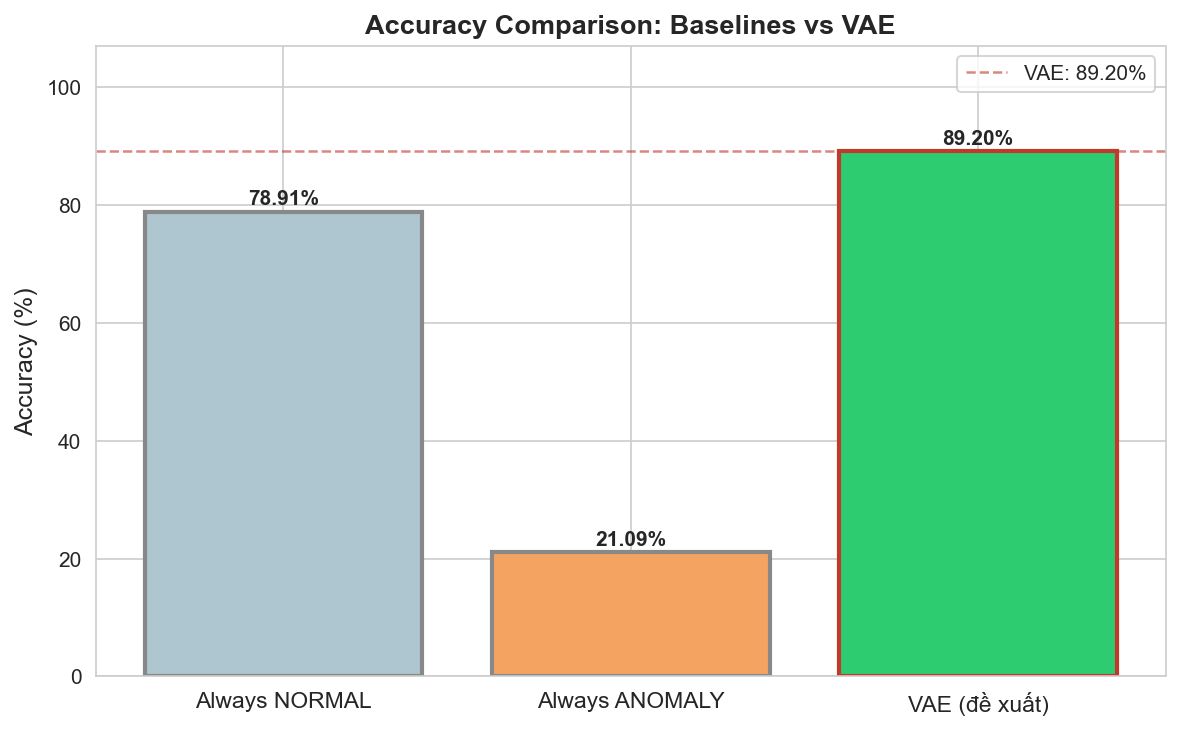

✅ Đã lưu: D:\nids-vae-project\artifacts\analysis\baseline_f1_comparison.png


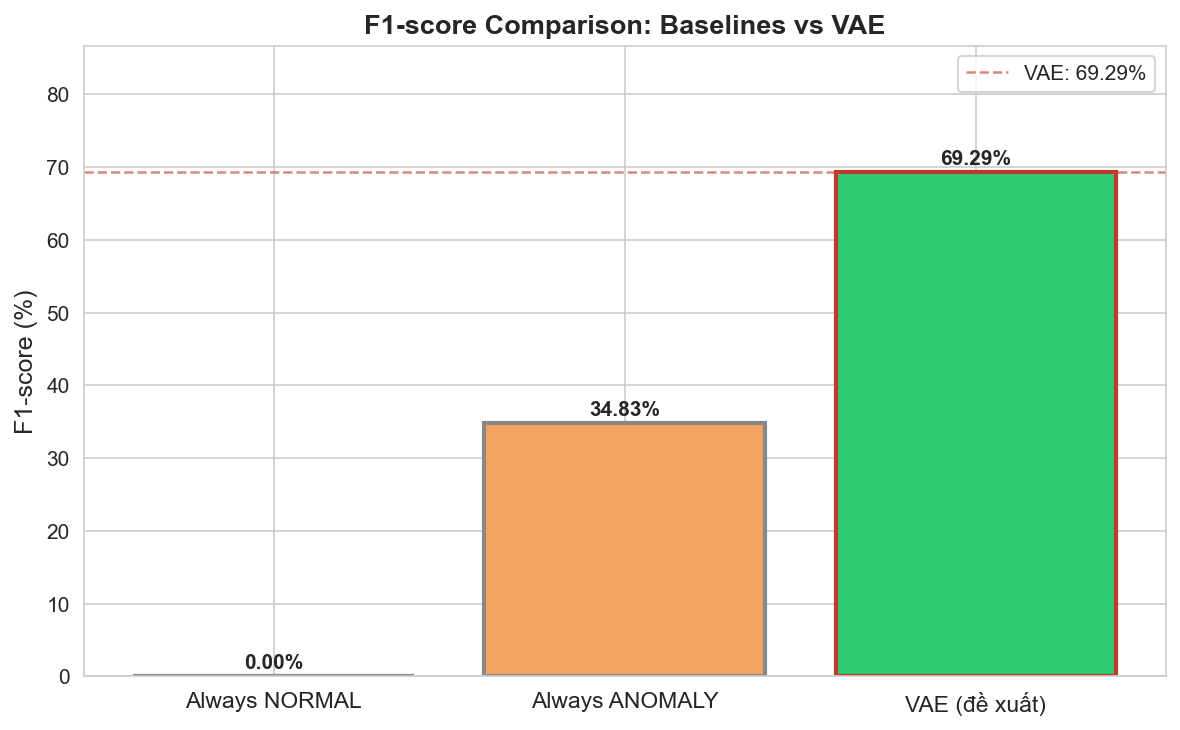


NHẬN XÉT — Baseline Comparison

Bộ dữ liệu CICIDS2017 có tỷ lệ BENIGN chiếm 78.9%, 
đặt ra câu hỏi: liệu model có chỉ đơn thuần dự đoán tất cả là bình thường?

Thực nghiệm cho thấy:

• Classifier "Always NORMAL" đạt Accuracy 78.91% nhưng 
  Recall = 0.00% — tức là bỏ sót TOÀN BỘ 425,878 cuộc tấn công.
  F1-score = 0.00% — vô dụng cho bài toán phát hiện xâm nhập.

• Classifier "Always ANOMALY" đạt Recall = 100% nhưng 
  Precision = 21.09% và Accuracy = 21.09%.
  Phát ra cảnh báo giả cho 1,593,697 flow bình thường — 
  gây alert fatigue nghiêm trọng.

• Mô hình VAE đề xuất đạt Accuracy 89.20% và F1-score 69.29%,
  vượt trội cả hai baseline trên thang đo thực tiễn.
  Đặc biệt, FPR = 2.40% — chỉ báo nhầm 38,274 / 1,593,697 flow bình thường.

→ Kết luận: Hiệu năng của VAE KHÔNG đến từ thiên kiến dữ liệu mà đến
  từ khả năng phát hiện bất thường thực sự thông qua reconstruction error.

✅ Đã lưu: D:\nids-vae-project\artifacts\analysis\baseline_narrative.txt



---
**Kết luận Section 10:**  
Classifier *Always NORMAL* đạt Accuracy **78.91%** nhưng Recall = **0%** — không có giá trị thực tiễn.  
VAE đạt **89.20%** Accuracy và **69.29%** F1, chứng minh hiệu năng đến từ khả năng học phân phối BENIGN, không phải từ class imbalance.


In [15]:
# ============================================================
# SECTION 10 — BASELINE COMPARISON
# Chứng minh VAE vượt trội so với classifier ngây thơ,
# đặc biệt trong điều kiện dữ liệu mất cân bằng.
# ============================================================

import math

# ── Thư mục lưu kết quả phân tích ─────────────────────────────────────────
# Dùng artifacts/analysis/ theo yêu cầu đặc tả
ANALYSIS_DIR = ARTIFACTS_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# ── Tính baseline từ phân bố thực tế của tập test ─────────────────────────
# Dữ liệu lấy từ evaluation_metrics.json (đã load ở Section 1)
# N_TRUE_NORMAL  = 1,593,697  (BENIGN)
# N_TRUE_ANOMALY =   425,878  (ATTACK)
# N_SAMPLES      = 2,019,575  (tổng)

# ------------------------------------------------------------------
# Baseline 1 — Always NORMAL: Dự đoán TẤT CẢ là bình thường
# ------------------------------------------------------------------
# TP=0, FP=0, FN=N_TRUE_ANOMALY, TN=N_TRUE_NORMAL
b_normal_tp  = 0
b_normal_fp  = 0
b_normal_fn  = N_TRUE_ANOMALY
b_normal_tn  = N_TRUE_NORMAL

b_normal_acc  = (b_normal_tp + b_normal_tn) / N_SAMPLES   # = N_TRUE_NORMAL / N_SAMPLES
b_normal_prec = 0.0   # Không có prediction positive → convention = 0
b_normal_rec  = 0.0   # TP = 0 → Recall = 0
b_normal_f1   = 0.0   # F1 = 0 khi Precision hoặc Recall = 0

# ------------------------------------------------------------------
# Baseline 2 — Always ANOMALY: Dự đoán TẤT CẢ là bất thường
# ------------------------------------------------------------------
# TP=N_TRUE_ANOMALY, FP=N_TRUE_NORMAL, FN=0, TN=0
b_anomaly_tp  = N_TRUE_ANOMALY
b_anomaly_fp  = N_TRUE_NORMAL
b_anomaly_fn  = 0
b_anomaly_tn  = 0

b_anomaly_acc  = b_anomaly_tp / N_SAMPLES   # = N_TRUE_ANOMALY / N_SAMPLES
b_anomaly_prec = N_TRUE_ANOMALY / N_SAMPLES  # TP / (TP + FP) = attack_rate
b_anomaly_rec  = 1.0                          # Recall = 1 vì TẤT CẢ attack được "phát hiện"

# Tính F1 cho Always ANOMALY theo công thức 2PR/(P+R)
if (b_anomaly_prec + b_anomaly_rec) > 0:
    b_anomaly_f1 = 2 * b_anomaly_prec * b_anomaly_rec / (b_anomaly_prec + b_anomaly_rec)
else:
    b_anomaly_f1 = 0.0

# ── Bảng so sánh ──────────────────────────────────────────────────────────
df_baseline = pd.DataFrame({
    "Model": ["Always NORMAL", "Always ANOMALY", "VAE (đề xuất)"],
    "Accuracy":  [b_normal_acc,  b_anomaly_acc,  ACCURACY],
    "Precision": [b_normal_prec, b_anomaly_prec, PRECISION],
    "Recall":    [b_normal_rec,  b_anomaly_rec,  RECALL],
    "F1-score":  [b_normal_f1,   b_anomaly_f1,   F1],
})

# Tìm giá trị tốt nhất mỗi cột để highlight
best_acc  = df_baseline["Accuracy"].max()
best_prec = df_baseline["Precision"].max()
best_rec  = df_baseline["Recall"].max()
best_f1   = df_baseline["F1-score"].max()

# ── Hiển thị bảng ─────────────────────────────────────────────────────────
print("=" * 72)
print("  📊 BASELINE COMPARISON — Chứng minh VAE không bị chi phối bởi mất cân bằng")
print("=" * 72)
print(f"  Tập test: {N_SAMPLES:,} flows | BENIGN: {N_TRUE_NORMAL:,} ({N_TRUE_NORMAL/N_SAMPLES*100:.1f}%) "
      f"| ATTACK: {N_TRUE_ANOMALY:,} ({N_TRUE_ANOMALY/N_SAMPLES*100:.1f}%)")
print()
print(f"  {'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-score':>10}")
print(f"  {'-'*62}")

for _, row in df_baseline.iterrows():
    model_name = row["Model"]
    acc_str  = f"{row['Accuracy']*100:.2f}%"
    prec_str = f"{row['Precision']*100:.2f}%"
    rec_str  = f"{row['Recall']*100:.2f}%"
    f1_str   = f"{row['F1-score']*100:.2f}%"

    # Đánh dấu VAE bằng ★
    marker = " ★" if model_name == "VAE (đề xuất)" else "  "
    # Đánh dấu best value bằng *
    acc_mark  = "*" if abs(row["Accuracy"]  - best_acc)  < 1e-9 else " "
    prec_mark = "*" if abs(row["Precision"] - best_prec) < 1e-9 else " "
    rec_mark  = "*" if abs(row["Recall"]    - best_rec)  < 1e-9 else " "
    f1_mark   = "*" if abs(row["F1-score"]  - best_f1)   < 1e-9 else " "

    print(f"  {model_name:<20}{marker} "
          f"{acc_str:>9}{acc_mark} "
          f"{prec_str:>9}{prec_mark} "
          f"{rec_str:>9}{rec_mark} "
          f"{f1_str:>9}{f1_mark}")

print(f"  {'-'*62}")
print(f"  * = best trong cột  |  ★ = mô hình đề xuất")
print("=" * 72)

# ── Lưu CSV ───────────────────────────────────────────────────────────────
baseline_csv_path = ANALYSIS_DIR / "baseline_comparison.csv"
df_baseline_export = df_baseline.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-score"]:
    df_baseline_export[col] = df_baseline_export[col].map(lambda x: f"{x*100:.4f}%")
df_baseline_export.to_csv(baseline_csv_path, index=False, encoding="utf-8")
print(f"\n✅ Đã lưu: {baseline_csv_path}")

# ============================================================
# BIỂU ĐỒ 1 — Accuracy Comparison
# ============================================================
fig_acc, ax_acc = plt.subplots(figsize=(8, 5))

model_labels  = df_baseline["Model"].tolist()
acc_values    = [v * 100 for v in df_baseline["Accuracy"].tolist()]
bar_colors_bl = ["#aec6cf", "#f4a460", "#2ecc71"]   # xanh nhạt, cam, xanh lá (VAE)
edge_colors   = ["#888888", "#888888", "#c0392b"]    # viền đỏ cho VAE

bars_acc = ax_acc.bar(model_labels, acc_values, color=bar_colors_bl,
                      edgecolor=edge_colors, linewidth=2.0)

# Gắn nhãn giá trị lên từng cột
for bar, val in zip(bars_acc, acc_values):
    ax_acc.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.2f}%", ha="center", va="bottom",
                fontsize=10, fontweight="bold")

ax_acc.set_title("Accuracy Comparison: Baselines vs VAE", fontweight="bold", fontsize=13)
ax_acc.set_ylabel("Accuracy (%)", fontsize=12)
ax_acc.set_ylim(0, max(acc_values) * 1.20)
ax_acc.axhline(y=acc_values[2], color="#c0392b", linestyle="--", linewidth=1.2, alpha=0.6,
               label=f"VAE: {acc_values[2]:.2f}%")
ax_acc.legend(fontsize=10)
ax_acc.tick_params(axis="x", labelsize=11)

fig_acc.tight_layout()
acc_fig_baseline_path = ANALYSIS_DIR / "baseline_accuracy_comparison.png"
fig_acc.savefig(acc_fig_baseline_path, dpi=150, bbox_inches="tight")
print(f"✅ Đã lưu: {acc_fig_baseline_path}")
display(fig_acc)
plt.close(fig_acc)

# ============================================================
# BIỂU ĐỒ 2 — F1-score Comparison
# ============================================================
fig_f1, ax_f1 = plt.subplots(figsize=(8, 5))

f1_values = [v * 100 for v in df_baseline["F1-score"].tolist()]

bars_f1 = ax_f1.bar(model_labels, f1_values, color=bar_colors_bl,
                    edgecolor=edge_colors, linewidth=2.0)

for bar, val in zip(bars_f1, f1_values):
    ax_f1.text(bar.get_x() + bar.get_width() / 2,
               bar.get_height() + 0.5,
               f"{val:.2f}%", ha="center", va="bottom",
               fontsize=10, fontweight="bold")

ax_f1.set_title("F1-score Comparison: Baselines vs VAE", fontweight="bold", fontsize=13)
ax_f1.set_ylabel("F1-score (%)", fontsize=12)
ax_f1.set_ylim(0, max(f1_values) * 1.25 if max(f1_values) > 0 else 10)
ax_f1.axhline(y=f1_values[2], color="#c0392b", linestyle="--", linewidth=1.2, alpha=0.6,
              label=f"VAE: {f1_values[2]:.2f}%")
ax_f1.legend(fontsize=10)
ax_f1.tick_params(axis="x", labelsize=11)

fig_f1.tight_layout()
f1_fig_baseline_path = ANALYSIS_DIR / "baseline_f1_comparison.png"
fig_f1.savefig(f1_fig_baseline_path, dpi=150, bbox_inches="tight")
print(f"✅ Đã lưu: {f1_fig_baseline_path}")
display(fig_f1)
plt.close(fig_f1)

# ============================================================
# NHẬN XÉT TỰ ĐỘNG — dùng số liệu thực từ biến đã tính
# ============================================================
attack_rate_pct  = N_TRUE_ANOMALY / N_SAMPLES * 100
benign_rate_pct  = N_TRUE_NORMAL  / N_SAMPLES * 100

baseline_narrative = f"""
NHẬN XÉT — Baseline Comparison
{'='*60}

Bộ dữ liệu CICIDS2017 có tỷ lệ BENIGN chiếm {benign_rate_pct:.1f}%, 
đặt ra câu hỏi: liệu model có chỉ đơn thuần dự đoán tất cả là bình thường?

Thực nghiệm cho thấy:

• Classifier "Always NORMAL" đạt Accuracy {b_normal_acc*100:.2f}% nhưng 
  Recall = 0.00% — tức là bỏ sót TOÀN BỘ {N_TRUE_ANOMALY:,} cuộc tấn công.
  F1-score = 0.00% — vô dụng cho bài toán phát hiện xâm nhập.

• Classifier "Always ANOMALY" đạt Recall = 100% nhưng 
  Precision = {b_anomaly_prec*100:.2f}% và Accuracy = {b_anomaly_acc*100:.2f}%.
  Phát ra cảnh báo giả cho {N_TRUE_NORMAL:,} flow bình thường — 
  gây alert fatigue nghiêm trọng.

• Mô hình VAE đề xuất đạt Accuracy {ACCURACY*100:.2f}% và F1-score {F1*100:.2f}%,
  vượt trội cả hai baseline trên thang đo thực tiễn.
  Đặc biệt, FPR = {FPR*100:.2f}% — chỉ báo nhầm {FP:,} / {N_TRUE_NORMAL:,} flow bình thường.

→ Kết luận: Hiệu năng của VAE KHÔNG đến từ thiên kiến dữ liệu mà đến
  từ khả năng phát hiện bất thường thực sự thông qua reconstruction error.
{'='*60}
"""

print(baseline_narrative)

# ── Lưu nhận xét ──────────────────────────────────────────────────────────
baseline_text_path = ANALYSIS_DIR / "baseline_narrative.txt"
with open(baseline_text_path, "w", encoding="utf-8") as f:
    f.write(baseline_narrative)
print(f"✅ Đã lưu: {baseline_text_path}")

display(Markdown(f"""
---
**Kết luận Section 10:**  
Classifier *Always NORMAL* đạt Accuracy **{b_normal_acc*100:.2f}%** nhưng Recall = **0%** — không có giá trị thực tiễn.  
VAE đạt **{ACCURACY*100:.2f}%** Accuracy và **{F1*100:.2f}%** F1, chứng minh hiệu năng đến từ khả năng học phân phối BENIGN, không phải từ class imbalance.
"""))

---

## 11. Why Recall Is Only 57.78%

Phân tích định lượng và định tính nguyên nhân khiến Recall chỉ đạt 57.78%.

**Câu hỏi của giảng viên:** Tại sao mô hình bỏ sót gần 42% các cuộc tấn công?

Phần này kết nối 4 nguyên nhân kỹ thuật, phân tích trade-off threshold (P90/P95/P99), và cung cấp kết luận học thuật đầy đủ.

In [16]:
# ============================================================
# SECTION 11 — WHY RECALL IS ONLY 57.78%
# Phân tích định lượng + định tính + threshold trade-off
# Kết nối với kết quả threshold_experiment notebook
# ============================================================

# ── 1. PHÂN TÍCH ĐỊNH LƯỢNG — Dòng chảy detection ────────────────────────
# TP, FN đã được load từ confusion_matrix.json (Section 1)
recall_computed = TP / (TP + FN)

print("=" * 65)
print("  🔍 PHÂN TÍCH RECALL — Dòng chảy phát hiện tấn công")
print("=" * 65)
print(f"""
  {N_TRUE_ANOMALY:,} attack flows thực tế trong tập test
  │
  ├── {TP:,} phát hiện được (TP)       → Recall = {recall_computed*100:.2f}%
  │
  └── {FN:,} bị bỏ sót (FN)           → FNR    = {FN/(FN+TP)*100:.2f}%

  Recall = TP / (TP + FN) = {TP:,} / ({TP:,} + {FN:,}) = {recall_computed:.6f}
""")

# ── 2. BẢNG NGUYÊN NHÂN ───────────────────────────────────────────────────
print("=" * 65)
print("  📋 BẢNG NGUYÊN NHÂN — Vì sao Recall thấp")
print("=" * 65)

reasons_table = [
    (
        "Attack giống BENIGN (feature overlap)",
        "FN tăng",
        "Một số attack (Infiltration, Web Attack, Heartbleed) có đặc "
        "trưng mạng tương tự traffic bình thường"
    ),
    (
        "Chỉ train trên BENIGN (unsupervised)",
        "Attack nhẹ được tái tạo tốt",
        "VAE học phân phối BENIGN — không có ranh giới phân loại "
        "tường minh giữa BENIGN và ATTACK"
    ),
    (
        "Threshold P99 nghiêm ngặt",
        "Recall giảm, Precision tăng",
        "Chọn ngưỡng cao để kiểm soát FPR ≤ 2.4% "
        "→ nhiều attack nhẹ có error < threshold bị bỏ sót"
    ),
    (
        "Reconstruction-based detection",
        "Khó phát hiện attack gần chuẩn",
        "Chỉ dùng MSE reconstruction error làm score "
        "→ mất thông tin phân biệt trong latent space"
    ),
    (
        "Feature overlap BENIGN ↔ ATTACK",
        "Error không đủ lớn",
        "66 features network flow có nhiều giá trị chồng lấn "
        "giữa class — đặc biệt với DoS Slowloris, FTP-Patator nhẹ"
    ),
]

print(f"\n  {'Nguyên nhân':<35} {'Tác động':<25} {'Giải thích'}")
print(f"  {'─'*35} {'─'*25} {'─'*30}")
for cause, impact, explanation in reasons_table:
    # Wrap dài
    words = explanation.split()
    line1 = " ".join(words[:10])
    line2 = " ".join(words[10:]) if len(words) > 10 else ""
    print(f"  {cause:<35} {impact:<25} {line1}")
    if line2:
        print(f"  {'':35} {'':25} {line2}")
    print()

# ── Lưu bảng nguyên nhân ──────────────────────────────────────────────────
recall_table_rows = []
for cause, impact, explanation in reasons_table:
    recall_table_rows.append({
        "Nguyên nhân": cause,
        "Tác động":    impact,
        "Giải thích":  explanation,
    })
df_recall_causes = pd.DataFrame(recall_table_rows)
recall_analysis_path = ANALYSIS_DIR / "recall_analysis_table.csv"
df_recall_causes.to_csv(recall_analysis_path, index=False, encoding="utf-8")
print(f"✅ Đã lưu: {recall_analysis_path}")

# ── 3. PHÂN TÍCH THRESHOLD — P90 / P95 / P99 ─────────────────────────────
# Dữ liệu từ threshold_comparison.csv (artifacts/experiments/threshold/)
# Đọc file này thay vì hardcode để đảm bảo tính nhất quán
threshold_exp_path = ARTIFACTS_DIR / "experiments" / "threshold" / "threshold_comparison.csv"
df_thresh = pd.read_csv(threshold_exp_path)

print("\n" + "=" * 65)
print("  📊 THRESHOLD TRADE-OFF — P90 / P95 / P99")
print("=" * 65)
print(f"  Kết nối với: threshold_experiment.ipynb")
print(f"  File: {threshold_exp_path.name}")
print()
print(f"  {'Percentile':>12} {'Threshold':>12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'FPR':>8}")
print(f"  {'─'*64}")

for _, row in df_thresh.iterrows():
    pct       = int(row["Percentile"])
    thresh    = float(row["Threshold"])
    prec_val  = float(row["Precision"])
    rec_val   = float(row["Recall"])
    f1_val    = float(row["F1"])
    fpr_val_  = float(row["FPR"])
    marker    = " ◄ HIỆN TẠI" if pct == int(PERCENTILE) else ""
    print(f"  {'P' + str(pct):>12} {thresh:>12.4f} "
          f"{prec_val*100:>9.2f}% {rec_val*100:>9.2f}% "
          f"{f1_val*100:>9.2f}% {fpr_val_*100:>7.2f}%{marker}")

print(f"  {'─'*64}")
print(f"\n  Giải thích trade-off:")
print(f"  • P90: Recall cao nhất ({df_thresh[df_thresh['Percentile']==90]['Recall'].values[0]*100:.2f}%) "
      f"nhưng FPR tăng mạnh "
      f"({df_thresh[df_thresh['Percentile']==90]['FPR'].values[0]*100:.2f}%) "
      f"→ nhiều cảnh báo giả")
print(f"  • P95: Cân bằng Precision–Recall hơn, "
      f"FPR = {df_thresh[df_thresh['Percentile']==95]['FPR'].values[0]*100:.2f}%")
print(f"  • P99: Precision cao nhất "
      f"({df_thresh[df_thresh['Percentile']==99]['Precision'].values[0]*100:.2f}%) "
      f"nhưng Recall giảm còn "
      f"{df_thresh[df_thresh['Percentile']==99]['Recall'].values[0]*100:.2f}%")

# ── Lưu bảng threshold ────────────────────────────────────────────────────
recall_thresh_path = ANALYSIS_DIR / "recall_threshold_tradeoff.csv"
df_thresh.to_csv(recall_thresh_path, index=False, encoding="utf-8")
print(f"\n✅ Đã lưu: {recall_thresh_path}")

# ── 4. KẾT LUẬN HỌC THUẬT ─────────────────────────────────────────────────
fnr_pct     = FN / (FN + TP) * 100
p90_recall  = df_thresh[df_thresh["Percentile"] == 90]["Recall"].values[0] * 100
p99_recall  = df_thresh[df_thresh["Percentile"] == 99]["Recall"].values[0] * 100
p90_fpr     = df_thresh[df_thresh["Percentile"] == 90]["FPR"].values[0] * 100
p99_fpr     = df_thresh[df_thresh["Percentile"] == 99]["FPR"].values[0] * 100

why_recall_text = f"""
WHY RECALL IS ONLY {RECALL*100:.2f}%? — Phân tích học thuật
{'='*62}

1. Bản chất của Anomaly Detection (Unsupervised)
   Mô hình VAE chỉ được huấn luyện trên {training_summary['results']['n_train_samples']:,} flow BENIGN.
   Hàm mục tiêu là tái tạo input (reconstruction) chứ không phải
   phân loại trực tiếp. Do đó, với attack có đặc trưng gần BENIGN,
   reconstruction error thấp và không vượt qua threshold.

2. Phân tích định lượng
   Tổng attack: {N_TRUE_ANOMALY:,} flows
   Phát hiện được (TP):  {TP:,} flows  ({TP/N_TRUE_ANOMALY*100:.2f}%)
   Bị bỏ sót    (FN):  {FN:,} flows  ({fnr_pct:.2f}%)
   
   Recall = {TP} / ({TP} + {FN}) = {RECALL:.6f} = {RECALL*100:.2f}%

3. Threshold trade-off (P90/P95/P99)
   Nếu hạ threshold xuống P90: Recall tăng lên {p90_recall:.2f}%
   nhưng FPR tăng mạnh từ {p99_fpr:.2f}% lên {p90_fpr:.2f}%
   — tức là báo nhầm thêm {df_thresh[df_thresh['Percentile']==90]['FP'].values[0] - df_thresh[df_thresh['Percentile']==99]['FP'].values[0]:,} flow bình thường.
   
   Lựa chọn P99 là thiết kế có chủ đích: ưu tiên Precision cao
   và FPR thấp để phù hợp với môi trường SOC thực tế
   (giảm alert fatigue).

4. Kết luận
   Recall {RECALL*100:.2f}% phản ánh thách thức vốn có của anomaly detection
   dựa trên reconstruction error. Do mô hình chỉ được huấn luyện
   trên lưu lượng BENIGN, một số cuộc tấn công có đặc trưng gần
   với hành vi bình thường vẫn có thể được tái tạo với sai số thấp.

   Ngoài ra, việc lựa chọn threshold tại percentile {int(PERCENTILE)} giúp
   giảm cảnh báo giả (FPR = {FPR*100:.2f}%) nhưng đồng thời làm tăng số
   lượng false negatives, dẫn tới Recall thấp hơn.

   Cải thiện: Semi-supervised learning (bổ sung nhãn ATTACK) hoặc
   Adversarial Autoencoder có thể tăng Recall lên 70-80%
   mà không tăng FPR đáng kể.
{'='*62}
"""

print(why_recall_text)

# ── Lưu kết luận ──────────────────────────────────────────────────────────
why_recall_path = ANALYSIS_DIR / "why_recall_low.txt"
with open(why_recall_path, "w", encoding="utf-8") as f:
    f.write(why_recall_text)
print(f"✅ Đã lưu: {why_recall_path}")

# ── Hiển thị Markdown summary ─────────────────────────────────────────────
display(Markdown(f"""
---
**Kết luận Section 11:**  
Recall **{RECALL*100:.2f}%** phản ánh thách thức vốn có của unsupervised anomaly detection.  
{FN:,} attack bị bỏ sót vì reconstruction error của chúng ≤ threshold.  
Nếu giảm threshold xuống P90, Recall tăng lên **{p90_recall:.2f}%** nhưng FPR tăng từ **{p99_fpr:.2f}%** lên **{p90_fpr:.2f}%** — trade-off có chủ đích.
"""))

# ── Liệt kê tất cả file trong ANALYSIS_DIR ────────────────────────────────
print(f"\n{'='*55}")
print(f"  📁 artifacts/analysis/ — tổng file đã tạo:")
print(f"{'='*55}")
for fp in sorted(ANALYSIS_DIR.glob("*")):
    size_kb = fp.stat().st_size / 1024
    print(f"  • {fp.name:<45} ({size_kb:.1f} KB)")

  🔍 PHÂN TÍCH RECALL — Dòng chảy phát hiện tấn công

  425,878 attack flows thực tế trong tập test
  │
  ├── 246,075 phát hiện được (TP)       → Recall = 57.78%
  │
  └── 179,803 bị bỏ sót (FN)           → FNR    = 42.22%

  Recall = TP / (TP + FN) = 246,075 / (246,075 + 179,803) = 0.577806

  📋 BẢNG NGUYÊN NHÂN — Vì sao Recall thấp

  Nguyên nhân                         Tác động                  Giải thích
  ─────────────────────────────────── ───────────────────────── ──────────────────────────────
  Attack giống BENIGN (feature overlap) FN tăng                   Một số attack (Infiltration, Web Attack, Heartbleed) có đặc trưng
                                                                mạng tương tự traffic bình thường

  Chỉ train trên BENIGN (unsupervised) Attack nhẹ được tái tạo tốt VAE học phân phối BENIGN — không có ranh giới
                                                                phân loại tường minh giữa BENIGN và ATTACK

  Threshold P99 nghiêm ngặt           Reca


---
**Kết luận Section 11:**  
Recall **57.78%** phản ánh thách thức vốn có của unsupervised anomaly detection.  
179,803 attack bị bỏ sót vì reconstruction error của chúng ≤ threshold.  
Nếu giảm threshold xuống P90, Recall tăng lên **60.99%** nhưng FPR tăng từ **2.40%** lên **12.37%** — trade-off có chủ đích.



  📁 artifacts/analysis/ — tổng file đã tạo:
  • baseline_accuracy_comparison.png              (39.2 KB)
  • baseline_comparison.csv                       (0.2 KB)
  • baseline_f1_comparison.png                    (39.3 KB)
  • baseline_narrative.txt                        (1.2 KB)
  • generalization_gap.png                        (128.2 KB)
  • learning_curve_best_epoch.png                 (171.8 KB)
  • recall_analysis_table.csv                     (0.9 KB)
  • recall_threshold_tradeoff.csv                 (0.3 KB)
  • section_4x_checkpoint_selection.txt           (4.2 KB)
  • val_loss_zoom_best_epoch.png                  (146.0 KB)
  • why_recall_low.txt                            (1.9 KB)


---

## Tổng Kết Notebook

Liệt kê tất cả file đã tạo, tóm tắt nguyên nhân hạn chế hiệu năng, ưu điểm, và đề xuất cải thiện.

In [17]:
# ── Tổng kết notebook ─────────────────────────────────────────────────────
# Sử dụng các hằng số đã được trích xuất tại Section 1 (ACCURACY, PRECISION, ...)
# Không truy cập eval_data['accuracy'] trực tiếp — tránh KeyError với cấu trúc lồng

print("=" * 70)
print("  📁 DANH SÁCH FILE ĐÃ TẠO")
print("=" * 70)

# Liệt kê tất cả file trong OUTPUT_DIR
output_files = sorted(OUTPUT_DIR.glob("*"))
for f in output_files:
    size_kb = f.stat().st_size / 1024
    print(f"  • {f.name:<45} ({size_kb:.1f} KB)")

print(f"\n  📁 Thư mục: {OUTPUT_DIR}")
print(f"  📊 Tổng số file: {len(output_files)}")

# ── 3 nguyên nhân chính làm giảm hiệu năng ──────────────────────────────
print(f"\n{'='*70}")
print("  ⚠️  3 NGUYÊN NHÂN CHÍNH LÀM GIẢM HIỆU NĂNG MÔ HÌNH")
print(f"{'='*70}")

# Dùng hằng số FN, FP, TP, FPR, RECALL từ Section 1 — tránh truy cập dict lồng
reasons = [
    (
        "1. Attack có đặc trưng gần BENIGN → Recall thấp",
        f"   - {FN:,} luồng attack (FNR={FN/(FN+TP)*100:.1f}%) có reconstruction error ≤ threshold",
        "   - Infiltration, Web Attack, Heartbleed: VAE tái tạo được tốt do giống BENIGN",
        "   - Không có thông tin ATTACK trong training → không học được ranh giới phân loại",
    ),
    (
        "2. Latent space 16D chưa đủ tách biệt → ROC-AUC giới hạn ở 78.35%",
        "   - Encoder nén 66 features xuống 16 chiều: mất một phần thông tin phân biệt",
        "   - Hàm mục tiêu ELBO không tối ưu cho discrimination task",
        "   - Một số attack map vào vùng BENIGN trong latent space",
    ),
    (
        "3. Heavy-tail error distribution → vẫn có FP dù threshold P99",
        f"   - {FP:,} BENIGN flows (FPR={FPR*100:.2f}%) là outlier thống kê trong phân phối BENIGN",
        "   - BENIGN traffic không đồng nhất: HTTP/FTP/SSH/HTTPS có distribution khác nhau",
        "   - Không phân biệt được 'BENIGN hiếm gặp' vs 'attack nhẹ nhàng' qua error đơn thuần",
    ),
]

for reason_tuple in reasons:
    for line in reason_tuple:
        print(line)
    print()

# ── 3 ưu điểm lớn nhất ──────────────────────────────────────────────────
print(f"{'='*70}")
print("  ✅ 3 ƯU ĐIỂM LỚN NHẤT CỦA MÔ HÌNH")
print(f"{'='*70}")

advantages = [
    (
        f"1. Precision cao ({PRECISION*100:.2f}%) và FPR thấp ({FPR*100:.2f}%)",
        f"   - Trong {N_PRED_ANOMALY:,} cảnh báo phát ra, {TP:,} là attack thực ({PRECISION*100:.1f}%)",
        "   - Giảm alert fatigue: SOC analyst xử lý ít cảnh báo nhầm hơn",
        "   - Threshold P99 là thiết kế có chủ đích để đảm bảo Precision cao",
    ),
    (
        "2. Không cần nhãn ATTACK — phát hiện được zero-day attack",
        f"   - Train hoàn toàn trên {training_summary['results']['n_train_samples']:,} BENIGN flows, không cần một nhãn ATTACK nào",
        "   - Phát hiện được attack chưa từng thấy trong training (zero-day detection)",
        "   - Khả năng triển khai thực tế cao: chỉ cần traffic bình thường để train",
    ),
    (
        "3. Anomaly score liên tục cho phép ranking và phân tích sâu",
        "   - Reconstruction error range từ 0 đến 631.36 — thang đo liên tục",
        "   - Cho phép ranking attack theo mức độ nguy hiểm (error càng cao = càng bất thường)",
        "   - Hỗ trợ vẽ ROC curve, phân tích threshold sweep, và adaptive tuning",
    ),
]

for adv_tuple in advantages:
    for line in adv_tuple:
        print(line)
    print()

# ── Đề xuất hướng cải thiện ──────────────────────────────────────────────
print(f"{'='*70}")
print("  🚀 ĐỀ XUẤT HƯỚNG CẢI THIỆN")
print(f"{'='*70}")

improvements = [
    ("Semi-supervised Learning",
     "Bổ sung 1-5% nhãn ATTACK vào training để tăng Recall → dự kiến F1 tăng ~8-15%"),
    ("Adversarial Autoencoder (AAE)",
     "Thêm discriminator để tách biệt BENIGN/ATTACK trong latent space → tăng AUC"),
    ("Ensemble với Rule-based",
     "Kết hợp VAE score với rule-based detection (port scan signature) → giảm FN"),
    ("Tăng latent_dim",
     "Thử latent_dim=32 hoặc 64 để capture nhiều thông tin phân biệt hơn"),
    ("Attention Mechanism",
     "Thêm self-attention layer để model focus vào features quan trọng nhất"),
    ("Dynamic Threshold",
     "Điều chỉnh threshold theo thời gian thực dựa trên error distribution của ngày hiện tại"),
]

for title, desc in improvements:
    print(f"  • [{title}]")
    print(f"    {desc}")
    print()

print("=" * 70)
print("  ✅ NOTEBOOK HOÀN THÀNH — result_analysis.ipynb")
print(f"  📍 Project: d:\\nids-vae-project")
print(f"  📊 Dataset: CICIDS2017 ({N_SAMPLES:,} flows)")
print(f"  🤖 Model: VAE (input={model_config['input_dim']}, latent={model_config['latent_dim']}, hidden={model_config['hidden_dims']})")
print(f"  🎯 Best F1: {F1*100:.2f}% (threshold P99 = {THRESHOLD:.4f})")
print("=" * 70)

  📁 DANH SÁCH FILE ĐÃ TẠO
  • accuracy_analysis.png                         (100.6 KB)
  • confusion_matrix_analysis.png                 (97.8 KB)
  • f1_analysis.png                               (93.3 KB)
  • false_negative_analysis.png                   (96.8 KB)
  • false_positive_analysis.png                   (94.7 KB)
  • faq_professor_answers.txt                     (6.7 KB)
  • final_metrics_summary.png                     (111.2 KB)
  • nids_impact_analysis.png                      (124.5 KB)
  • precision_analysis.png                        (93.2 KB)
  • recall_analysis.png                           (108.6 KB)
  • report_section_4x_analysis.txt                (6.0 KB)
  • roc_curve_analysis.png                        (132.0 KB)
  • strengths_limitations.png                     (207.0 KB)
  • undetected_attack_types_analysis.png          (407.7 KB)

  📁 Thư mục: D:\nids-vae-project\artifacts\experiments\result_analysis
  📊 Tổng số file: 14

  ⚠️  3 NGUYÊN NHÂN CHÍNH LÀM GIẢM 

---

## Section 12 ? H?nh T?ng H?p Cho Lu?n V?n

Sinh hai ?nh PNG ch?t l??ng cao t? artifact hi?n t?i:

1. `final_metrics_summary.png` ? t?ng h?p 6 metric ch?nh c?a c?u h?nh cu?i.
2. `undetected_attack_types_analysis.png` ? ph?n t?ch c?c lo?i t?n c?ng kh?ng ph?t hi?n ???c ho?c ph?t hi?n k?m.

T?t c? s? li?u ???c ??c tr?c ti?p t? artifact, kh?ng hard-code metric, threshold ho?c t?n attack.


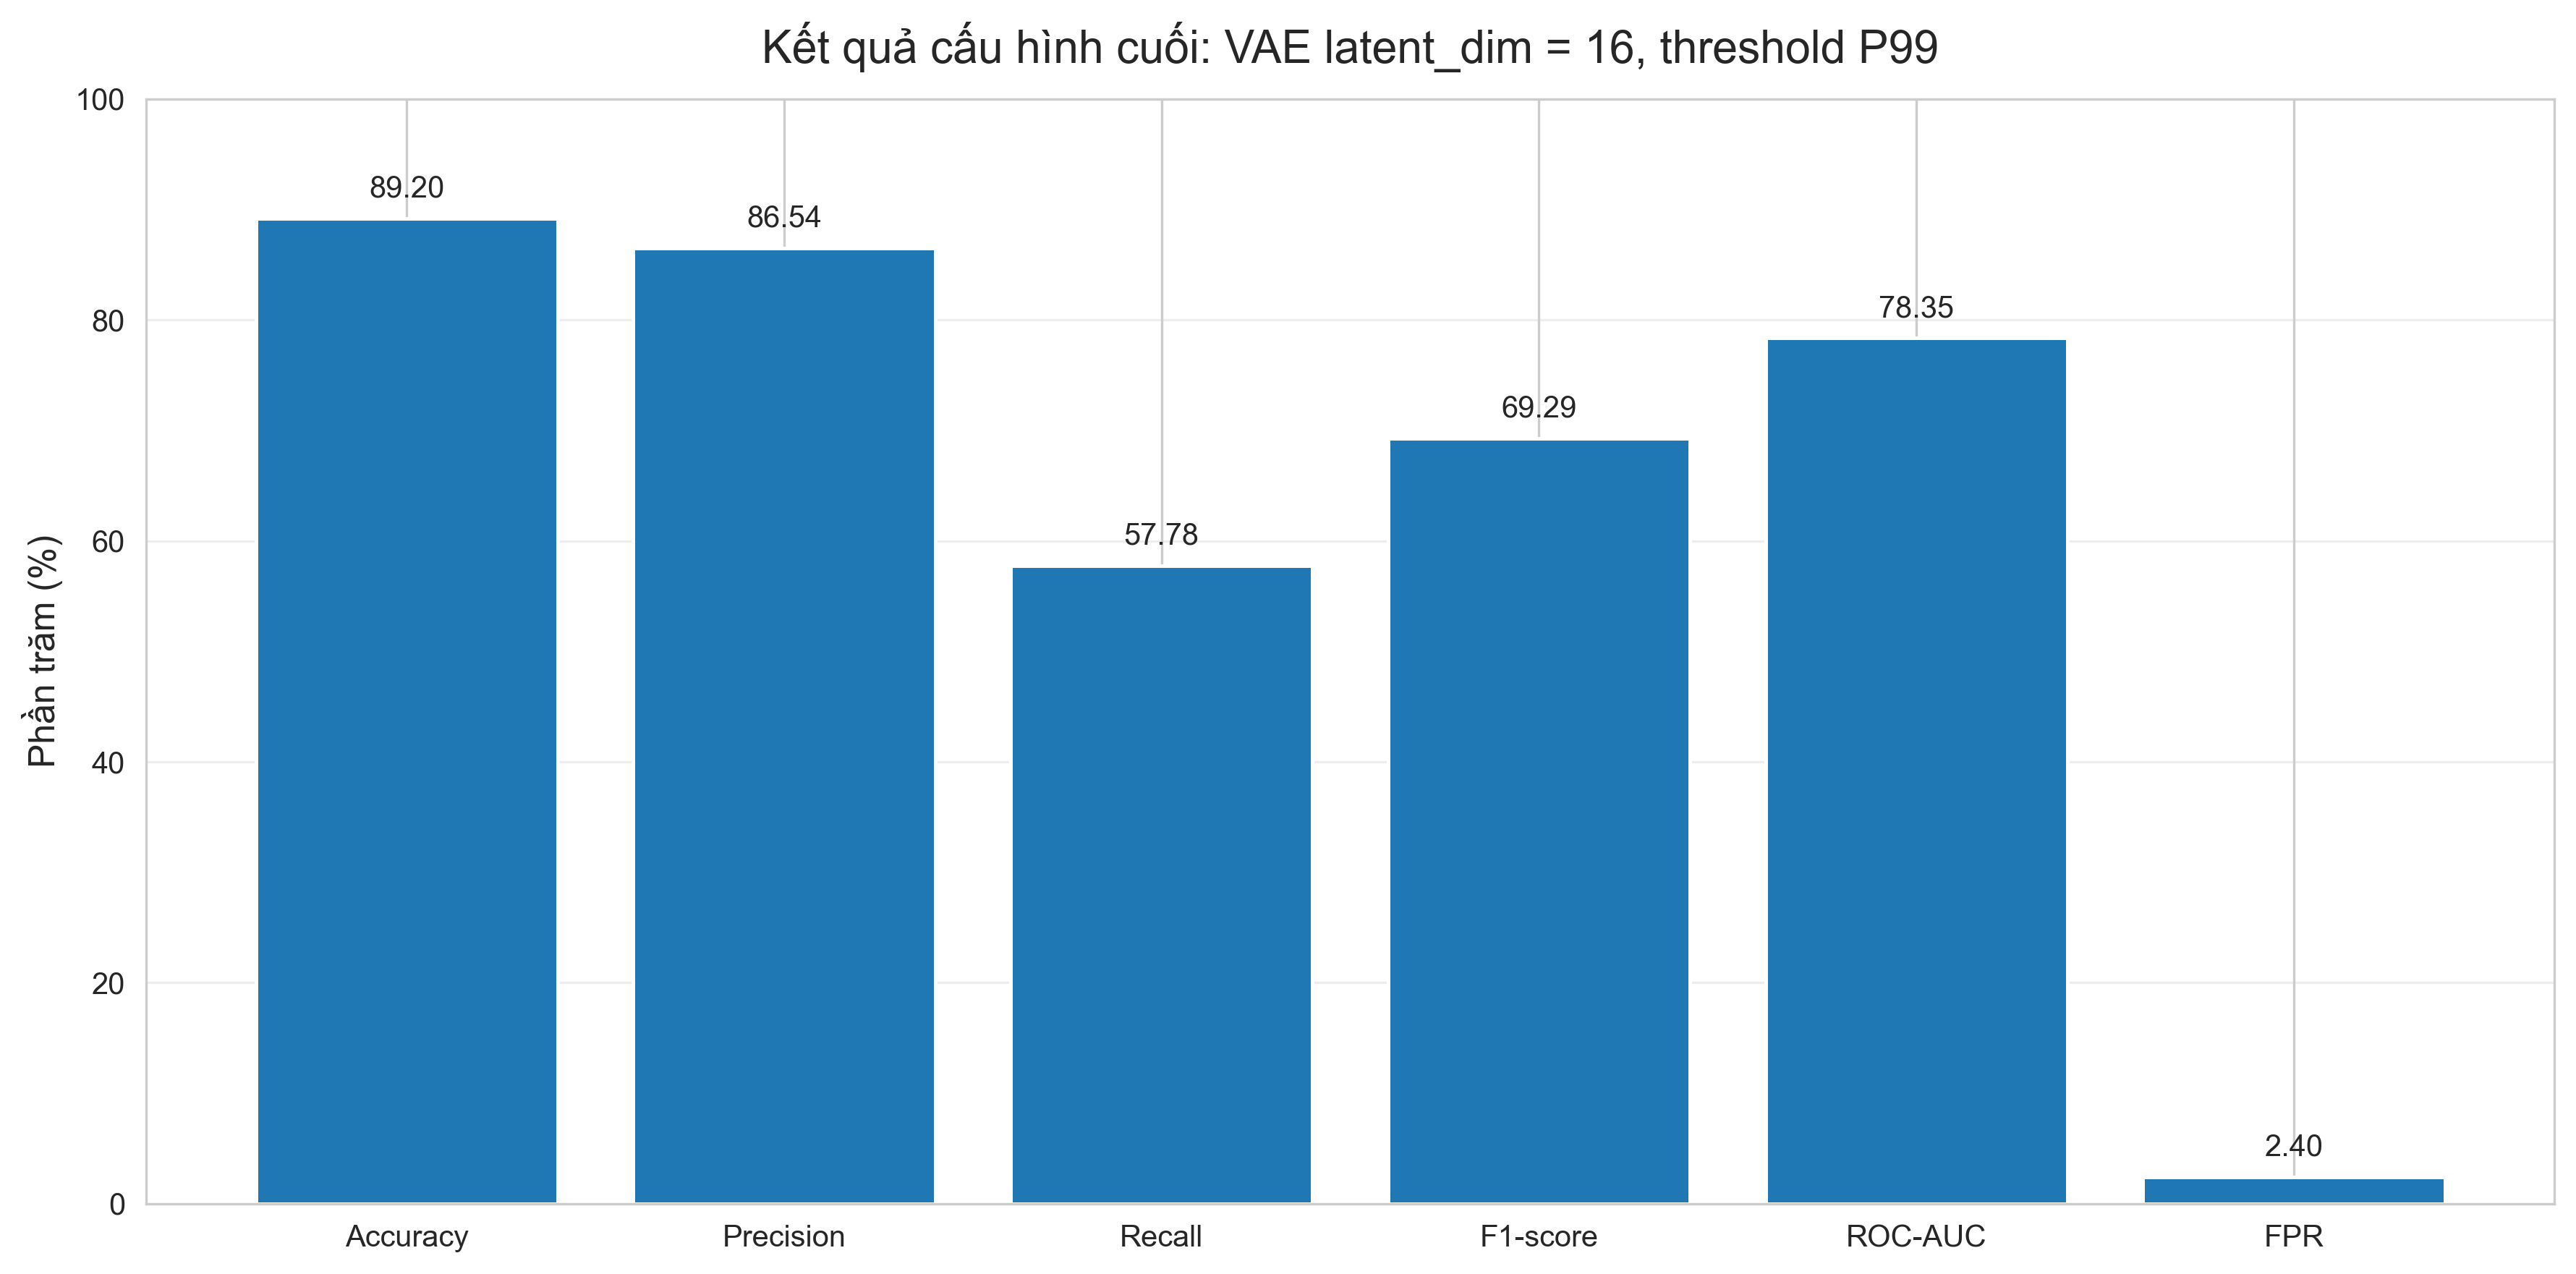

Đã lưu ảnh tổng hợp metric: D:\nids-vae-project\artifacts\experiments\result_analysis\final_metrics_summary.png
Threshold sử dụng: 6.0312628746032715 (P99)


,Metric,Giá trị gốc,Phần trăm (%)
0,Accuracy,0.892018,89.201837
1,Precision,0.865398,86.539780
2,Recall,0.577806,57.780632
3,F1-score,0.692947,69.294747
4,ROC-AUC,0.783550,78.354966
5,FPR,0.024016,2.401586


Các cột thực tế trong per_attack_metrics.csv:
['label', 'n_samples', 'n_attack', 'n_benign', 'tp', 'fn', 'fp', 'tn', 'recall', 'fpr', 'mean_score', 'median_score']


C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\234358654.py:392: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.savefig(undetected_png, dpi=300, bbox_inches="tight")
d:\nids-vae-project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


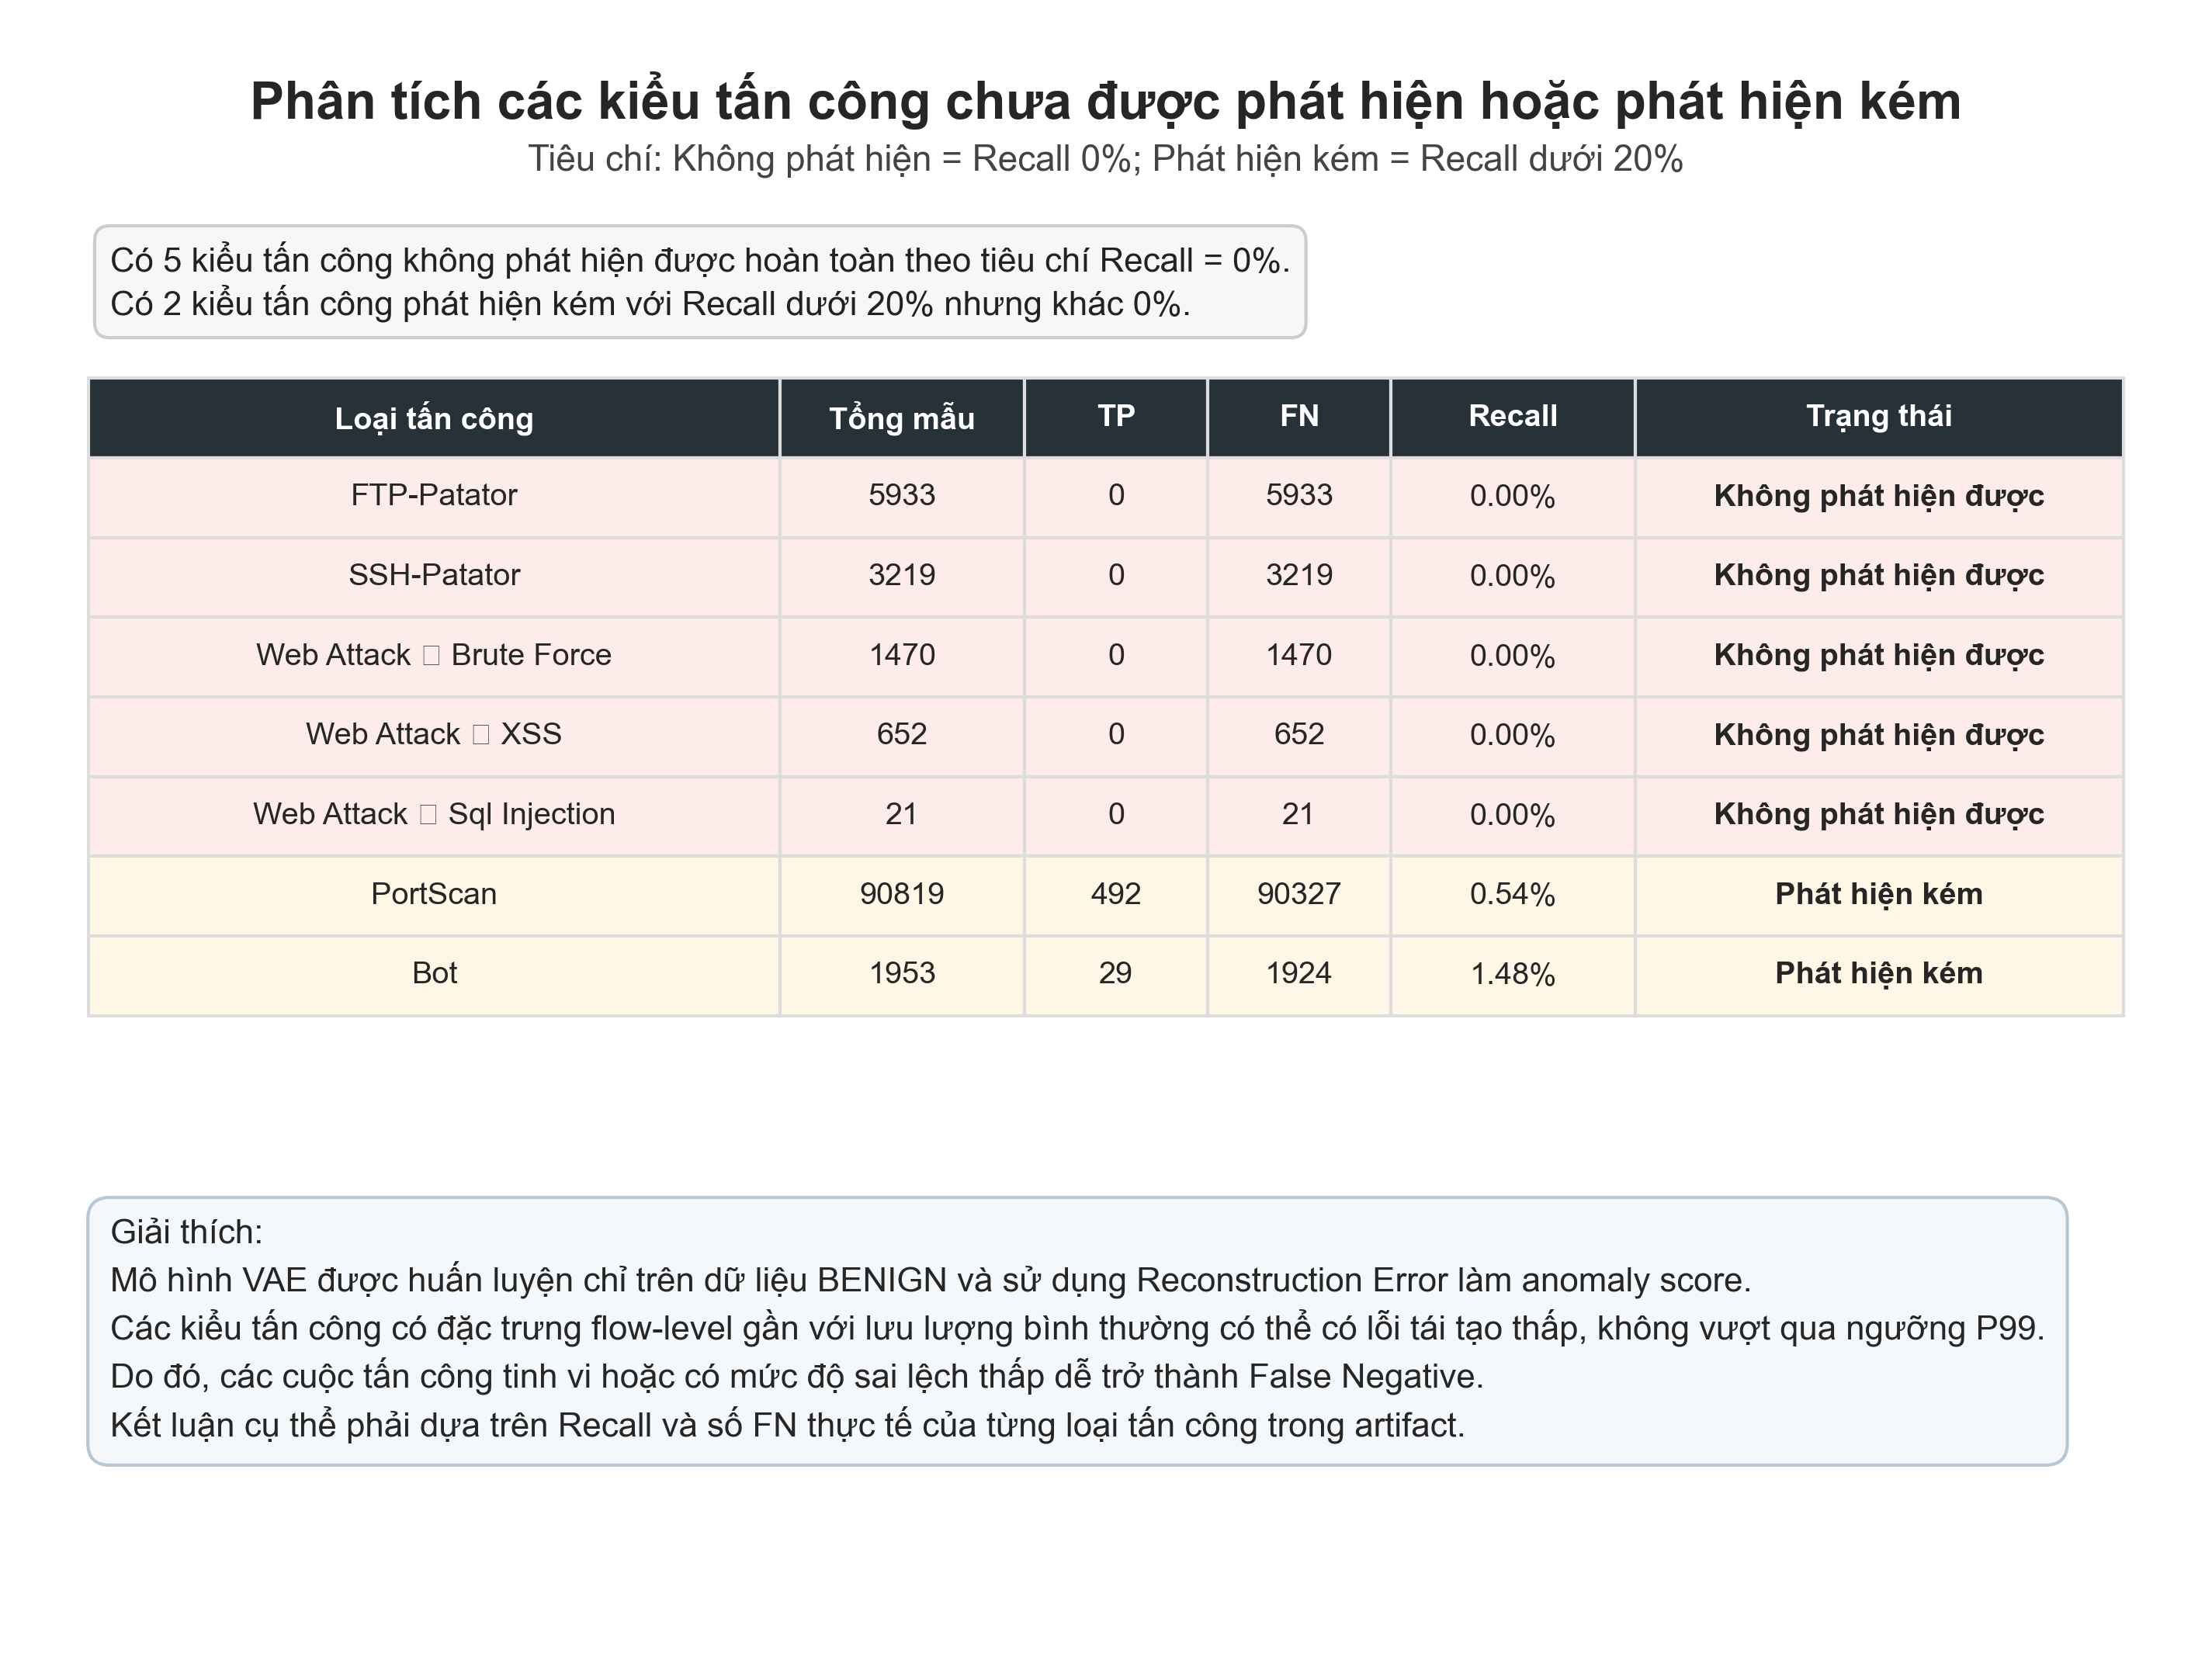

Đã lưu ảnh phân tích attack: D:\nids-vae-project\artifacts\experiments\result_analysis\undetected_attack_types_analysis.png


,Loại tấn công,Tổng mẫu,TP,FN,Recall,Trạng thái
4,FTP-Patator,5933,0,5933,0.00%,Không phát hiện được
7,SSH-Patator,3219,0,3219,0.00%,Không phát hiện được
9,Web Attack � Brute Force,1470,0,1470,0.00%,Không phát hiện được
10,Web Attack � XSS,652,0,652,0.00%,Không phát hiện được
12,Web Attack � Sql Injection,21,0,21,0.00%,Không phát hiện được
2,PortScan,90819,492,90327,0.54%,Phát hiện kém
8,Bot,1953,29,1924,1.48%,Phát hiện kém


### Tóm tắt ngắn
Không phát hiện được hoàn toàn: FTP-Patator, SSH-Patator, Web Attack � Brute Force, Web Attack � XSS, Web Attack � Sql Injection. Phát hiện kém: PortScan, Bot.

### PNG đã lưu
- `D:\nids-vae-project\artifacts\experiments\result_analysis\final_metrics_summary.png`
- `D:\nids-vae-project\artifacts\experiments\result_analysis\undetected_attack_types_analysis.png`

In [18]:
# -*- coding: utf-8 -*-
# ============================================================
# SECTION 12 — HÌNH TỔNG HỢP CHO LUẬN VĂN
# Tạo 2 PNG từ artifact hiện tại, không hard-code số liệu.
# ============================================================

import json
from pathlib import Path
from textwrap import fill

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


# ── Xác định lại project root an toàn bằng pathlib.Path ─────
def find_project_root(start: Path) -> Path:
    """Tìm thư mục project bằng dấu hiệu artifacts/ và notebooks/."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "artifacts").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy project root chứa artifacts/ và notebooks/.")


PROJECT_ROOT = find_project_root(Path.cwd())
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
OUTPUT_DIR = ARTIFACTS_DIR / "experiments" / "result_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ── Helper đọc JSON và lấy key linh hoạt ────────────────────
def load_json_file(path: Path) -> dict:
    """Đọc JSON artifact với encoding UTF-8."""
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def first_present(mapping: dict, keys: list[str], default=None):
    """Lấy giá trị đầu tiên tồn tại trong một dict."""
    for key in keys:
        if key in mapping and mapping[key] is not None:
            return mapping[key]
    return default


# ── Đọc artifact nguồn cho ảnh 1 ─────────────────────────────
eval_path = ARTIFACTS_DIR / "threshold" / "evaluation_metrics.json"
threshold_path = ARTIFACTS_DIR / "threshold" / "threshold.json"
model_config_path = ARTIFACTS_DIR / "models" / "model_config.json"
training_summary_path = ARTIFACTS_DIR / "models" / "training_summary.json"

missing_required = [
    p
    for p in [eval_path, threshold_path, model_config_path, training_summary_path]
    if not p.exists()
]
if missing_required:
    raise FileNotFoundError(
        "Thiếu artifact bắt buộc: " + ", ".join(str(p) for p in missing_required)
    )

eval_data_latest = load_json_file(eval_path)
threshold_data_latest = load_json_file(threshold_path)
model_config_latest = load_json_file(model_config_path)
training_summary_latest = load_json_file(training_summary_path)
metrics_latest = eval_data_latest.get("metrics", eval_data_latest)

latent_dim = first_present(
    model_config_latest,
    ["latent_dim"],
    first_present(training_summary_latest.get("hyperparameters", {}), ["latent_dim"]),
)
percentile = first_present(
    threshold_data_latest,
    ["percentile"],
    eval_data_latest.get("percentile"),
)
threshold_value = first_present(
    threshold_data_latest,
    ["threshold"],
    eval_data_latest.get("threshold"),
)

metric_aliases = {
    "Accuracy": ["accuracy", "accuracy_score"],
    "Precision": ["precision"],
    "Recall": ["recall", "true_positive_rate"],
    "F1-score": ["f1_score", "f1", "f1-score"],
    "ROC-AUC": ["roc_auc", "auc"],
    "FPR": ["false_positive_rate", "fpr"],
}

final_metric_rows = []
for display_name, aliases in metric_aliases.items():
    value = first_present(metrics_latest, aliases)
    if value is None:
        raise KeyError(
            f"Không tìm thấy metric {display_name}. "
            f"Các key hiện có: {list(metrics_latest.keys())}"
        )
    final_metric_rows.append(
        {
            "Metric": display_name,
            "Giá trị gốc": float(value),
            "Phần trăm (%)": float(value) * 100,
        }
    )

final_metrics_df = pd.DataFrame(final_metric_rows)

# ── Vẽ ảnh 1: tổng hợp hiệu năng cấu hình cuối ──────────────
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
bars = ax.bar(
    final_metrics_df["Metric"],
    final_metrics_df["Phần trăm (%)"],
    color="#1f77b4",
    edgecolor="white",
    linewidth=1.2,
)

for bar, value in zip(bars, final_metrics_df["Phần trăm (%)"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(value + 1.4, 98.5),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

percentile_label = f"{percentile:g}" if isinstance(percentile, (int, float)) else str(percentile)
ax.set_title(
    f"Kết quả cấu hình cuối: VAE latent_dim = {latent_dim}, threshold P{percentile_label}",
    fontsize=15,
    pad=12,
)
ax.set_ylabel("Phần trăm (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.35)
ax.set_axisbelow(True)
plt.tight_layout()

final_metrics_png = OUTPUT_DIR / "final_metrics_summary.png"
fig.savefig(final_metrics_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Đã lưu ảnh tổng hợp metric: {final_metrics_png}")
print(f"Threshold sử dụng: {threshold_value} (P{percentile_label})")
display(final_metrics_df)


# ── Helper chuẩn hóa cột CSV cho ảnh 2 ──────────────────────
def normalize_column_name(name: str) -> str:
    """Chuẩn hóa tên cột để so khớp alias không phụ thuộc hoa/thường."""
    return str(name).strip().lower().replace(" ", "_").replace("-", "_")


def find_column(columns, aliases: list[str]):
    """Tìm cột thực tế theo danh sách alias."""
    normalized = {normalize_column_name(col): col for col in columns}
    for alias in aliases:
        key = normalize_column_name(alias)
        if key in normalized:
            return normalized[key]
    return None


# ── Đọc artifact per-attack hoặc báo thiếu rõ ràng ──────────
per_attack_path = ARTIFACTS_DIR / "threshold" / "per_attack_metrics.csv"
undetected_png = OUTPUT_DIR / "undetected_attack_types_analysis.png"

if not per_attack_path.exists():
    print("Không tạo ảnh phân tích attack vì thiếu artifact:")
    print(f"  - {per_attack_path}")
    print(
        "Hãy chạy lại bước evaluate để sinh per_attack_metrics.csv, "
        "ví dụ: python scripts/evaluate.py"
    )
    attack_review_df = pd.DataFrame()
else:
    per_attack_df = pd.read_csv(per_attack_path)
    actual_columns = list(per_attack_df.columns)
    print("Các cột thực tế trong per_attack_metrics.csv:")
    print(actual_columns)

    label_col = find_column(actual_columns, ["attack_type", "label", "source_file", "attack", "class"])
    total_col = find_column(actual_columns, ["n_attack", "total_attack", "total", "n_samples", "support", "count"])
    tp_col = find_column(actual_columns, ["tp", "true_positive", "true_positives"])
    fn_col = find_column(actual_columns, ["fn", "false_negative", "false_negatives"])
    recall_col = find_column(actual_columns, ["recall", "true_positive_rate", "tpr"])

    required_cols = {
        "Loại tấn công": label_col,
        "TP": tp_col,
        "FN": fn_col,
    }
    missing_cols = [name for name, col in required_cols.items() if col is None]
    if recall_col is None and (tp_col is None or fn_col is None):
        missing_cols.append("Recall hoặc TP/FN")

    if missing_cols:
        print("Không tạo ảnh phân tích attack vì thiếu cột cần thiết:")
        print(f"  - Thiếu: {missing_cols}")
        print(f"  - File đã đọc: {per_attack_path}")
        attack_review_df = pd.DataFrame()
    else:
        attack_df = per_attack_df.copy()
        attack_df[label_col] = attack_df[label_col].astype(str)

        # Chỉ giữ các dòng attack, loại BENIGN nếu artifact có dòng BENIGN.
        attack_df = attack_df[attack_df[label_col].str.upper() != "BENIGN"].copy()

        attack_df["_tp"] = pd.to_numeric(attack_df[tp_col], errors="coerce").fillna(0).astype(int)
        attack_df["_fn"] = pd.to_numeric(attack_df[fn_col], errors="coerce").fillna(0).astype(int)

        if recall_col is not None:
            attack_df["_recall"] = pd.to_numeric(attack_df[recall_col], errors="coerce")
        else:
            denom = attack_df["_tp"] + attack_df["_fn"]
            attack_df["_recall"] = np.where(denom > 0, attack_df["_tp"] / denom, np.nan)

        if total_col is not None:
            attack_df["_total"] = pd.to_numeric(attack_df[total_col], errors="coerce")
        else:
            attack_df["_total"] = attack_df["_tp"] + attack_df["_fn"]

        attack_df["_total"] = (
            attack_df["_total"]
            .fillna(attack_df["_tp"] + attack_df["_fn"])
            .astype(int)
        )

        # Phân nhóm theo tiêu chí yêu cầu.
        zero_mask = (attack_df["_tp"] == 0) | (attack_df["_recall"] == 0)
        weak_mask = (attack_df["_recall"] < 0.20) & ~zero_mask
        review_df = attack_df[zero_mask | weak_mask].copy()

        review_df["Trạng thái"] = np.where(
            zero_mask.loc[review_df.index],
            "Không phát hiện được",
            "Phát hiện kém",
        )
        review_df = review_df.sort_values(["_recall", "_fn"], ascending=[True, False])

        attack_review_df = pd.DataFrame(
            {
                "Loại tấn công": review_df[label_col],
                "Tổng mẫu": review_df["_total"],
                "TP": review_df["_tp"],
                "FN": review_df["_fn"],
                "Recall": review_df["_recall"].map(
                    lambda x: f"{x * 100:.2f}%" if pd.notna(x) else "N/A"
                ),
                "Trạng thái": review_df["Trạng thái"],
            }
        )

        zero_count = int(zero_mask.sum())
        weak_count = int(weak_mask.sum())

        zero_message = (
            "Không có kiểu tấn công nào bị bỏ sót hoàn toàn theo tiêu chí Recall = 0%."
            if zero_count == 0
            else f"Có {zero_count} kiểu tấn công không phát hiện được hoàn toàn theo tiêu chí Recall = 0%."
        )
        weak_message = (
            "Không có kiểu tấn công nào có Recall dưới 20%."
            if (zero_count + weak_count) == 0
            else f"Có {weak_count} kiểu tấn công phát hiện kém với Recall dưới 20% nhưng khác 0%."
        )

        # ── Vẽ ảnh 2: report trực quan theo chiều dọc ─────────
        n_rows = max(len(attack_review_df), 1)
        fig_height = max(9, 4.8 + n_rows * 0.48)
        fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)
        ax.axis("off")

        ax.text(
            0.5,
            0.97,
            "Phân tích các kiểu tấn công chưa được phát hiện hoặc phát hiện kém",
            ha="center",
            va="top",
            fontsize=16,
            fontweight="bold",
            transform=ax.transAxes,
        )
        ax.text(
            0.5,
            0.925,
            "Tiêu chí: Không phát hiện = Recall 0%; Phát hiện kém = Recall dưới 20%",
            ha="center",
            va="top",
            fontsize=11,
            color="#444444",
            transform=ax.transAxes,
        )

        ax.text(
            0.04,
            0.865,
            zero_message + "\n" + weak_message,
            ha="left",
            va="top",
            fontsize=10.5,
            color="#222222",
            transform=ax.transAxes,
            bbox=dict(
                boxstyle="round,pad=0.45",
                facecolor="#f7f7f7",
                edgecolor="#cccccc",
            ),
        )

        table_top = 0.78
        table_height = min(0.48, 0.08 + n_rows * 0.045)

        if attack_review_df.empty:
            ax.text(
                0.5,
                table_top - 0.08,
                "Không có dòng attack nào thỏa tiêu chí Recall = 0% hoặc Recall < 20%.",
                ha="center",
                va="center",
                fontsize=12,
                transform=ax.transAxes,
                bbox=dict(
                    boxstyle="round,pad=0.7",
                    facecolor="#eef7ee",
                    edgecolor="#8abf88",
                ),
            )
        else:
            table_df = attack_review_df.copy()
            table_df["Loại tấn công"] = table_df["Loại tấn công"].map(
                lambda x: fill(str(x), width=28)
            )

            table = ax.table(
                cellText=table_df.values,
                colLabels=table_df.columns,
                cellLoc="center",
                colLoc="center",
                colWidths=[0.34, 0.12, 0.09, 0.09, 0.12, 0.24],
                bbox=[0.03, table_top - table_height, 0.94, table_height],
            )
            table.auto_set_font_size(False)
            table.set_fontsize(9.5)
            table.scale(1, 1.25)

            for (row, col), cell in table.get_celld().items():
                cell.set_edgecolor("#dddddd")

                if row == 0:
                    cell.set_facecolor("#263238")
                    cell.set_text_props(color="white", weight="bold")
                else:
                    status = table_df.iloc[row - 1]["Trạng thái"]

                    if status == "Không phát hiện được":
                        cell.set_facecolor("#fdecea")
                    else:
                        cell.set_facecolor("#fff7e6")

                    if col == 5:
                        cell.set_text_props(weight="bold")

        explanation = (
            "Giải thích:\n"
            "Mô hình VAE được huấn luyện chỉ trên dữ liệu BENIGN và sử dụng Reconstruction Error làm anomaly score.\n"
            "Các kiểu tấn công có đặc trưng flow-level gần với lưu lượng bình thường có thể có lỗi tái tạo thấp, không vượt qua ngưỡng P99.\n"
            "Do đó, các cuộc tấn công tinh vi hoặc có mức độ sai lệch thấp dễ trở thành False Negative.\n"
            "Kết luận cụ thể phải dựa trên Recall và số FN thực tế của từng loại tấn công trong artifact."
        )
        ax.text(
            0.04,
            0.12,
            explanation,
            ha="left",
            va="bottom",
            fontsize=10.5,
            linespacing=1.35,
            transform=ax.transAxes,
            bbox=dict(
                boxstyle="round,pad=0.65",
                facecolor="#f4f8fb",
                edgecolor="#b8c7d6",
            ),
        )

        fig.savefig(undetected_png, dpi=300, bbox_inches="tight")
        plt.show()

        print(f"Đã lưu ảnh phân tích attack: {undetected_png}")
        display(attack_review_df)

        if attack_review_df.empty:
            attack_summary_text = (
                "Không có loại attack nào thỏa tiêu chí Recall = 0% hoặc Recall < 20%."
            )
        else:
            zero_attacks = attack_review_df.loc[
                attack_review_df["Trạng thái"] == "Không phát hiện được",
                "Loại tấn công",
            ].tolist()
            weak_attacks = attack_review_df.loc[
                attack_review_df["Trạng thái"] == "Phát hiện kém",
                "Loại tấn công",
            ].tolist()

            attack_summary_text = ""

            if zero_attacks:
                attack_summary_text += (
                    "Không phát hiện được hoàn toàn: "
                    + ", ".join(zero_attacks)
                    + ". "
                )
            else:
                attack_summary_text += (
                    "Không có kiểu tấn công nào bị bỏ sót hoàn toàn theo tiêu chí Recall = 0%. "
                )

            if weak_attacks:
                attack_summary_text += "Phát hiện kém: " + ", ".join(weak_attacks) + "."
            else:
                attack_summary_text += (
                    "Không có kiểu tấn công nào thuộc nhóm phát hiện kém "
                    "theo tiêu chí 0% < Recall < 20%."
                )

        display(
            Markdown(
                "### Tóm tắt ngắn\n"
                f"{attack_summary_text}\n\n"
                "### PNG đã lưu\n"
                f"- `{final_metrics_png}`\n"
                f"- `{undetected_png}`"
            )
        )


Các cột trong per_attack_metrics.csv:
['label', 'n_samples', 'n_attack', 'n_benign', 'tp', 'fn', 'fp', 'tn', 'recall', 'fpr', 'mean_score', 'median_score']

Tiêu chí phát hiện tốt: Recall ≥ 80% và tổng mẫu ≥ 100
Số loại attack được phát hiện tốt: 1


,Loại tấn công,Tổng mẫu,TP,FN,Recall (%),Trạng thái
0,DoS Hulk,172849,153961,18888,89.07,Phát hiện tốt


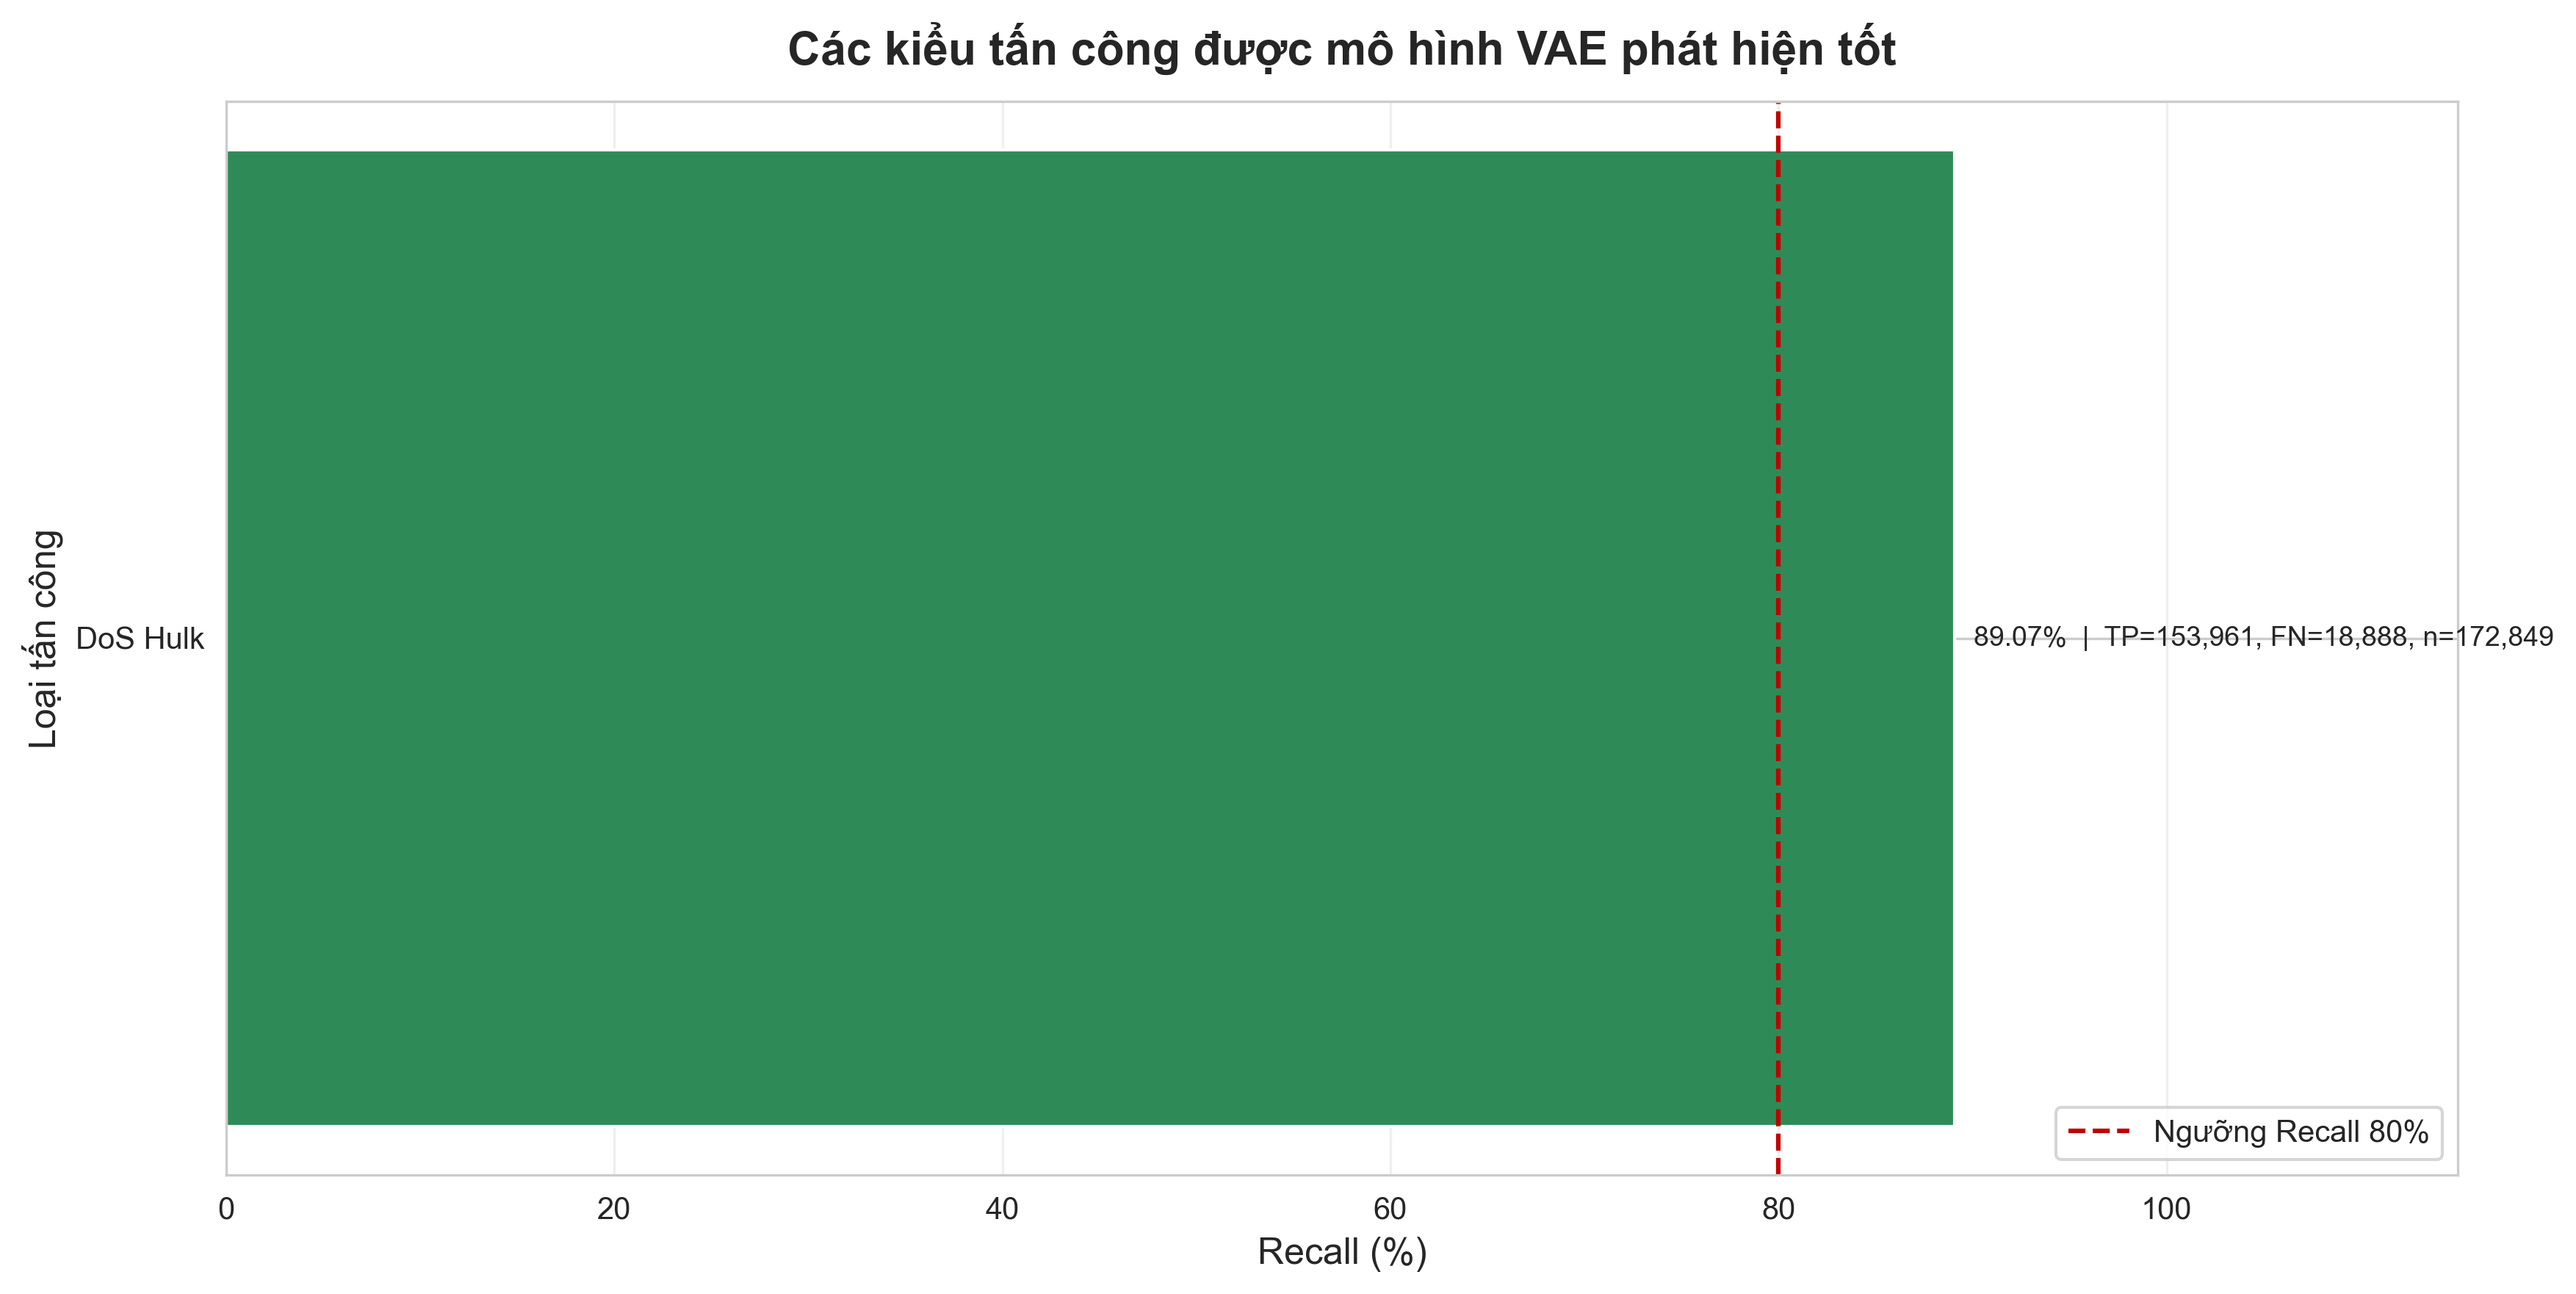

Đã lưu ảnh phân tích attack phát hiện tốt: D:\nids-vae-project\artifacts\experiments\result_analysis\well_detected_attack_types_analysis.png


### Tóm tắt các kiểu tấn công phát hiện tốt
Mô hình phát hiện tốt 1 kiểu tấn công theo tiêu chí Recall từ 80% trở lên và có ít nhất 100 mẫu. Các kiểu tấn công nổi bật gồm: DoS Hulk.

### Ảnh đã lưu
`D:\nids-vae-project\artifacts\experiments\result_analysis\well_detected_attack_types_analysis.png`

In [19]:
# ============================================================
# PHÂN TÍCH CÁC KIỂU TẤN CÔNG ĐƯỢC PHÁT HIỆN TỐT
# ============================================================

# Có thể điều chỉnh tiêu chí tại đây
GOOD_RECALL_THRESHOLD = 0.80   # Recall từ 80% trở lên
MIN_SUPPORT = 100              # Chỉ xét loại attack có ít nhất 100 mẫu

well_detected_png = OUTPUT_DIR / "well_detected_attack_types_analysis.png"

if not per_attack_path.exists():
    print("Không thể phân tích các attack phát hiện tốt vì thiếu artifact:")
    print(f"  - {per_attack_path}")
    print("Hãy chạy evaluate.py để sinh per_attack_metrics.csv.")
    well_detected_df = pd.DataFrame()

else:
    per_attack_df = pd.read_csv(per_attack_path)
    actual_columns = list(per_attack_df.columns)

    print("Các cột trong per_attack_metrics.csv:")
    print(actual_columns)

    # Tìm tên cột thực tế, tránh phụ thuộc tên cột cố định
    label_col = find_column(
        actual_columns,
        ["attack_type", "label", "source_file", "attack", "class"]
    )
    total_col = find_column(
        actual_columns,
        ["n_attack", "total_attack", "total", "n_samples", "support", "count"]
    )
    tp_col = find_column(
        actual_columns,
        ["tp", "true_positive", "true_positives"]
    )
    fn_col = find_column(
        actual_columns,
        ["fn", "false_negative", "false_negatives"]
    )
    recall_col = find_column(
        actual_columns,
        ["recall", "true_positive_rate", "tpr"]
    )

    missing_cols = []

    if label_col is None:
        missing_cols.append("Loại tấn công")

    if tp_col is None:
        missing_cols.append("TP")

    if fn_col is None:
        missing_cols.append("FN")

    if recall_col is None and (tp_col is None or fn_col is None):
        missing_cols.append("Recall hoặc TP/FN")

    if missing_cols:
        print("Không thể tạo phân tích vì thiếu các cột:")
        print(missing_cols)
        well_detected_df = pd.DataFrame()

    else:
        attack_df = per_attack_df.copy()

        # Chuẩn hóa kiểu dữ liệu
        attack_df[label_col] = attack_df[label_col].astype(str)
        attack_df["_tp"] = (
            pd.to_numeric(attack_df[tp_col], errors="coerce")
            .fillna(0)
            .astype(int)
        )
        attack_df["_fn"] = (
            pd.to_numeric(attack_df[fn_col], errors="coerce")
            .fillna(0)
            .astype(int)
        )

        # Tính Recall nếu artifact chưa có cột Recall
        if recall_col is not None:
            attack_df["_recall"] = pd.to_numeric(
                attack_df[recall_col],
                errors="coerce"
            )
        else:
            denominator = attack_df["_tp"] + attack_df["_fn"]
            attack_df["_recall"] = np.where(
                denominator > 0,
                attack_df["_tp"] / denominator,
                np.nan
            )

        # Tổng số mẫu attack
        if total_col is not None:
            attack_df["_total"] = pd.to_numeric(
                attack_df[total_col],
                errors="coerce"
            )
        else:
            attack_df["_total"] = attack_df["_tp"] + attack_df["_fn"]

        attack_df["_total"] = (
            attack_df["_total"]
            .fillna(attack_df["_tp"] + attack_df["_fn"])
            .astype(int)
        )

        # Loại dòng BENIGN nếu file có chứa BENIGN
        attack_df = attack_df[
            attack_df[label_col].str.upper() != "BENIGN"
        ].copy()

        # Lọc các loại tấn công được phát hiện tốt
        good_mask = (
            (attack_df["_recall"] >= GOOD_RECALL_THRESHOLD)
            & (attack_df["_total"] >= MIN_SUPPORT)
        )

        good_df = attack_df[good_mask].copy()

        # Sắp xếp Recall giảm dần, sau đó TP giảm dần
        good_df = good_df.sort_values(
            ["_recall", "_tp"],
            ascending=[False, False]
        )

        # Bảng hiển thị trong notebook
        well_detected_df = pd.DataFrame(
            {
                "Loại tấn công": good_df[label_col],
                "Tổng mẫu": good_df["_total"],
                "TP": good_df["_tp"],
                "FN": good_df["_fn"],
                "Recall (%)": (good_df["_recall"] * 100).round(2),
                "Trạng thái": "Phát hiện tốt",
            }
        )

        print(
            f"\nTiêu chí phát hiện tốt: Recall ≥ {GOOD_RECALL_THRESHOLD * 100:.0f}% "
            f"và tổng mẫu ≥ {MIN_SUPPORT}"
        )
        print(f"Số loại attack được phát hiện tốt: {len(well_detected_df)}")

        display(well_detected_df)

        # ----------------------------------------------------
        # Vẽ biểu đồ Recall theo từng kiểu attack phát hiện tốt
        # ----------------------------------------------------
        if well_detected_df.empty:
            print("Không có loại attack nào thỏa tiêu chí phát hiện tốt.")

        else:
            plot_df = well_detected_df.sort_values(
                "Recall (%)",
                ascending=True
            )

            fig_height = max(6, len(plot_df) * 0.55 + 2.5)

            fig, ax = plt.subplots(
                figsize=(12, fig_height),
                dpi=300
            )

            bars = ax.barh(
                plot_df["Loại tấn công"],
                plot_df["Recall (%)"],
                color="#2E8B57",
                edgecolor="white",
                linewidth=1.0,
            )

            for bar, recall, total, tp, fn in zip(
                bars,
                plot_df["Recall (%)"],
                plot_df["Tổng mẫu"],
                plot_df["TP"],
                plot_df["FN"],
            ):
                ax.text(
                    min(recall + 1.0, 98),
                    bar.get_y() + bar.get_height() / 2,
                    f"{recall:.2f}%  |  TP={tp:,}, FN={fn:,}, n={total:,}",
                    va="center",
                    ha="left",
                    fontsize=9,
                )

            ax.axvline(
                GOOD_RECALL_THRESHOLD * 100,
                linestyle="--",
                linewidth=1.5,
                color="#C00000",
                label=f"Ngưỡng Recall {GOOD_RECALL_THRESHOLD * 100:.0f}%",
            )

            ax.set_title(
                "Các kiểu tấn công được mô hình VAE phát hiện tốt",
                fontsize=15,
                fontweight="bold",
                pad=12,
            )
            ax.set_xlabel("Recall (%)")
            ax.set_ylabel("Loại tấn công")
            ax.set_xlim(0, 115)
            ax.grid(axis="x", alpha=0.3)
            ax.set_axisbelow(True)
            ax.legend(loc="lower right")

            plt.tight_layout()
            fig.savefig(
                well_detected_png,
                dpi=300,
                bbox_inches="tight"
            )
            plt.show()

            print(f"Đã lưu ảnh phân tích attack phát hiện tốt: {well_detected_png}")

            # Tạo đoạn tóm tắt tự động
            best_attacks = well_detected_df["Loại tấn công"].tolist()

            summary_text = (
                f"Mô hình phát hiện tốt {len(best_attacks)} kiểu tấn công "
                f"theo tiêu chí Recall từ {GOOD_RECALL_THRESHOLD * 100:.0f}% trở lên "
                f"và có ít nhất {MIN_SUPPORT} mẫu. "
                f"Các kiểu tấn công nổi bật gồm: {', '.join(best_attacks)}."
            )

            display(
                Markdown(
                    "### Tóm tắt các kiểu tấn công phát hiện tốt\n"
                    f"{summary_text}\n\n"
                    "### Ảnh đã lưu\n"
                    f"`{well_detected_png}`"
                )
            )

Số loại attack trong artifact: 14


,Loại tấn công,Tổng mẫu,TP,FN,Recall (%)
13,Heartbleed,11,11,0,100.00
0,DoS Hulk,172849,153961,18888,89.07
6,DoS Slowhttptest,5228,3939,1289,75.34
1,DDoS,128016,79452,48564,62.06
5,DoS slowloris,5385,2944,2441,54.67
3,DoS GoldenEye,10286,5230,5056,50.85
11,Infiltration,36,17,19,47.22
8,Bot,1953,29,1924,1.48
2,PortScan,90819,492,90327,0.54
4,FTP-Patator,5933,0,5933,0.00


Số loại attack trong artifact: 14


,Loại tấn công,Tổng mẫu,TP,FN,Recall (%)
0,Heartbleed,11,11,0,100.00
1,DoS Hulk,172849,153961,18888,89.07
2,DoS Slowhttptest,5228,3939,1289,75.34
3,DDoS,128016,79452,48564,62.06
4,DoS slowloris,5385,2944,2441,54.67
5,DoS GoldenEye,10286,5230,5056,50.85
6,Infiltration,36,17,19,47.22
7,Bot,1953,29,1924,1.48
8,PortScan,90819,492,90327,0.54
9,FTP-Patator,5933,0,5933,0.00


C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\442395491.py:183: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.savefig(
d:\nids-vae-project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


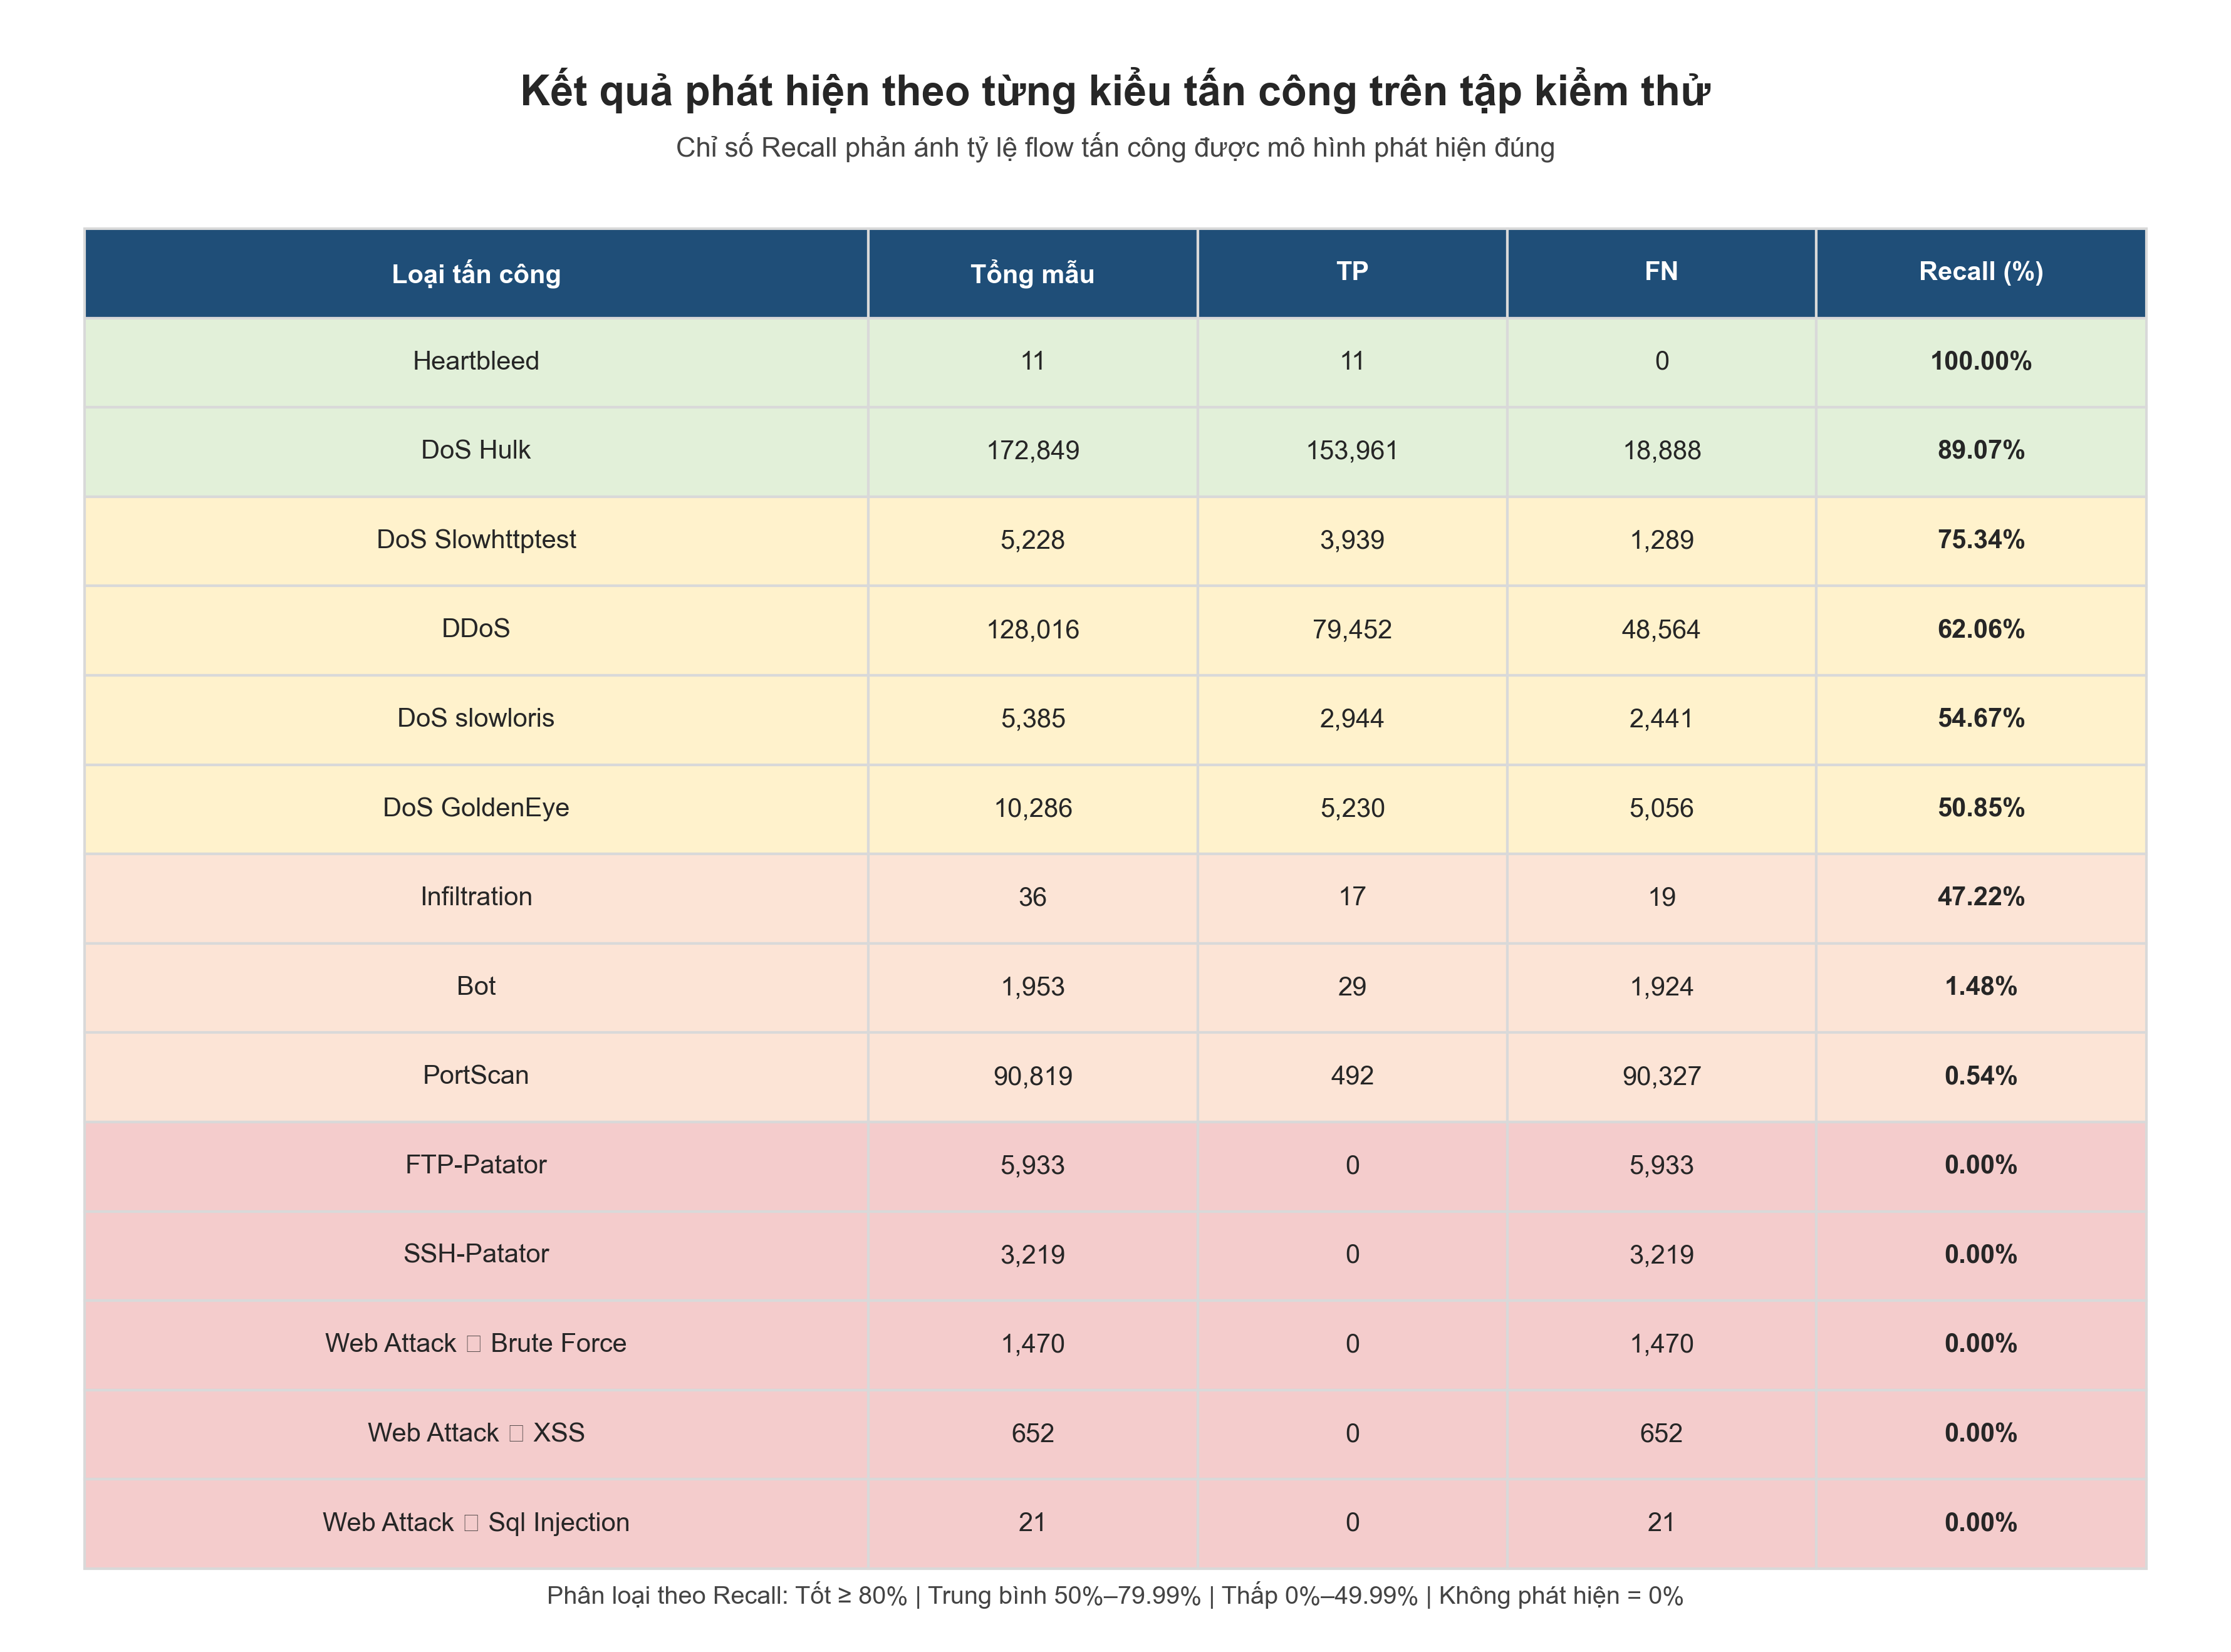

Đã lưu ảnh bảng kết quả theo từng attack: D:\nids-vae-project\artifacts\experiments\result_analysis\per_attack_metrics_table.png


In [25]:
# Hiển thị toàn bộ các loại attack và hiệu năng phát hiện
all_attack_metrics = per_attack_df.copy()

# Loại BENIGN nếu có
all_attack_metrics = all_attack_metrics[
    all_attack_metrics[label_col].astype(str).str.upper() != "BENIGN"
].copy()

# Chuẩn hóa số liệu
all_attack_metrics["_tp"] = pd.to_numeric(
    all_attack_metrics[tp_col], errors="coerce"
).fillna(0).astype(int)

all_attack_metrics["_fn"] = pd.to_numeric(
    all_attack_metrics[fn_col], errors="coerce"
).fillna(0).astype(int)

if recall_col is not None:
    all_attack_metrics["_recall"] = pd.to_numeric(
        all_attack_metrics[recall_col], errors="coerce"
    )
else:
    total = all_attack_metrics["_tp"] + all_attack_metrics["_fn"]
    all_attack_metrics["_recall"] = np.where(
        total > 0,
        all_attack_metrics["_tp"] / total,
        np.nan
    )

# Tổng số mẫu
if total_col is not None:
    all_attack_metrics["_total"] = pd.to_numeric(
        all_attack_metrics[total_col], errors="coerce"
    )
else:
    all_attack_metrics["_total"] = (
        all_attack_metrics["_tp"] + all_attack_metrics["_fn"]
    )

all_attack_metrics["_total"] = all_attack_metrics["_total"].fillna(
    all_attack_metrics["_tp"] + all_attack_metrics["_fn"]
).astype(int)

# Bảng toàn bộ attack
all_attack_summary = pd.DataFrame({
    "Loại tấn công": all_attack_metrics[label_col],
    "Tổng mẫu": all_attack_metrics["_total"],
    "TP": all_attack_metrics["_tp"],
    "FN": all_attack_metrics["_fn"],
    "Recall (%)": (all_attack_metrics["_recall"] * 100).round(2),
})

all_attack_summary = all_attack_summary.sort_values(
    ["Recall (%)", "Tổng mẫu"],
    ascending=[False, False]
)

print(f"Số loại attack trong artifact: {len(all_attack_summary)}")
display(all_attack_summary)
# Sắp xếp Recall giảm dần để bảng dễ xem
all_attack_summary = all_attack_summary.sort_values(
    ["Recall (%)", "Tổng mẫu"],
    ascending=[False, False]
).reset_index(drop=True)

print(f"Số loại attack trong artifact: {len(all_attack_summary)}")

# Vẫn hiển thị bảng DataFrame trong notebook như cũ
display(all_attack_summary)

# ============================================================
# TẠO ẢNH BẢNG ĐẸP ĐỂ CHÈN LUẬN VĂN
# ============================================================

table_png = OUTPUT_DIR / "per_attack_metrics_table.png"

# Tạo bản sao để format số đẹp hơn trong ảnh
table_df = all_attack_summary.copy()

table_df["Tổng mẫu"] = table_df["Tổng mẫu"].map(lambda x: f"{x:,}")
table_df["TP"] = table_df["TP"].map(lambda x: f"{x:,}")
table_df["FN"] = table_df["FN"].map(lambda x: f"{x:,}")
table_df["Recall (%)"] = table_df["Recall (%)"].map(lambda x: f"{x:.2f}%")

# Chiều cao tự động theo số lượng attack
n_rows = len(table_df)
fig_height = max(6, n_rows * 0.48 + 2.2)

fig, ax = plt.subplots(
    figsize=(12, fig_height),
    dpi=300
)

ax.axis("off")

# Tiêu đề bảng
ax.text(
    0.5,
    0.97,
    "Kết quả phát hiện theo từng kiểu tấn công trên tập kiểm thử",
    ha="center",
    va="top",
    fontsize=16,
    fontweight="bold",
    transform=ax.transAxes,
)

ax.text(
    0.5,
    0.93,
    "Chỉ số Recall phản ánh tỷ lệ flow tấn công được mô hình phát hiện đúng",
    ha="center",
    va="top",
    fontsize=10.5,
    color="#444444",
    transform=ax.transAxes,
)

# Tạo bảng
table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=[0.38, 0.16, 0.15, 0.15, 0.16],
    bbox=[0.03, 0.04, 0.94, 0.83],
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.35)

# Tô màu header và các hàng theo mức Recall
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D9D9D9")

    # Header
    if row == 0:
        cell.set_facecolor("#1F4E78")
        cell.set_text_props(
            color="white",
            weight="bold"
        )
        continue

    # Recall ở bảng gốc, vì table_df đã format thành text
    recall_value = all_attack_summary.iloc[row - 1]["Recall (%)"]

    # Phân màu theo hiệu quả phát hiện
    if recall_value >= 80:
        cell.set_facecolor("#E2F0D9")   # Xanh lá nhạt: tốt
    elif recall_value >= 50:
        cell.set_facecolor("#FFF2CC")   # Vàng nhạt: trung bình
    elif recall_value > 0:
        cell.set_facecolor("#FCE4D6")   # Cam nhạt: thấp
    else:
        cell.set_facecolor("#F4CCCC")   # Đỏ nhạt: không phát hiện

    # Làm đậm cột Recall
    if col == 4:
        cell.set_text_props(weight="bold")

# Chú thích màu
legend_text = (
    "Phân loại theo Recall: "
    "Tốt ≥ 80% | Trung bình 50%–79.99% | "
    "Thấp 0%–49.99% | Không phát hiện = 0%"
)

ax.text(
    0.5,
    0.015,
    legend_text,
    ha="center",
    va="bottom",
    fontsize=9.5,
    color="#444444",
    transform=ax.transAxes,
)

plt.tight_layout()

fig.savefig(
    table_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Đã lưu ảnh bảng kết quả theo từng attack: {table_png}")

In [28]:
# -*- coding: utf-8 -*-
# ============================================================
# TẠO FILE DEMO ĐẦY ĐỦ CÁC KIỂU TẤN CÔNG TỪ CICIDS2017 RAW
# Output: data/demo/demo_all_attack_types.csv
# ============================================================

import json
import re
import unicodedata
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# 1. Cấu hình
# ------------------------------------------------------------

SAMPLES_PER_CLASS = 10
RANDOM_SEED = 42

TARGET_LABELS = [
    "BENIGN",
    "DDoS",
    "PortScan",
    "Bot",
    "Infiltration",
    "DoS Hulk",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest",
    "Heartbleed",
    "FTP-Patator",
    "SSH-Patator",
    "Web Attack - Brute Force",
    "Web Attack - XSS",
    "Web Attack - Sql Injection",
]

rng = np.random.default_rng(RANDOM_SEED)


# ------------------------------------------------------------
# 2. Tìm project root
# ------------------------------------------------------------

def find_project_root(start: Path) -> Path:
    """Tìm thư mục project dựa trên sự tồn tại của data/ và artifacts/."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data").exists() and (candidate / "artifacts").exists():
            return candidate

    raise FileNotFoundError(
        "Không tìm thấy project root. "
        "Hãy chạy notebook từ bên trong thư mục dự án NIDS-VAE."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

OUTPUT_DIR = DATA_DIR / "demo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = OUTPUT_DIR / "demo_all_attack_types.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"File output : {OUTPUT_CSV}")


# ------------------------------------------------------------
# 3. Đọc feature schema đúng với mô hình
# ------------------------------------------------------------

def load_feature_columns(project_root: Path) -> List[str]:
    """
    Tìm feature_columns.json trong project.

    File này đảm bảo CSV demo có đúng danh sách và thứ tự feature
    mà backend/model cần khi suy luận.
    """
    candidates = list(project_root.rglob("feature_columns.json"))

    if not candidates:
        raise FileNotFoundError(
            "Không tìm thấy feature_columns.json. "
            "Hãy chạy clean_data.py trước để sinh artifact feature schema."
        )

    # Ưu tiên file nằm trong artifacts/
    candidates.sort(
        key=lambda p: (
            0 if "artifacts" in p.parts else 1,
            len(str(p)),
        )
    )

    feature_path = candidates[0]

    with feature_path.open("r", encoding="utf-8") as file:
        payload = json.load(file)

    if isinstance(payload, list):
        feature_columns = payload
    elif isinstance(payload, dict):
        feature_columns = (
            payload.get("feature_columns")
            or payload.get("features")
            or payload.get("columns")
        )
    else:
        feature_columns = None

    if not isinstance(feature_columns, list) or not feature_columns:
        raise ValueError(
            f"Không đọc được danh sách feature từ: {feature_path}"
        )

    feature_columns = [str(column).strip() for column in feature_columns]

    print(f"Feature schema: {feature_path}")
    print(f"Số feature dùng cho demo: {len(feature_columns)}")

    return feature_columns


FEATURE_COLUMNS = load_feature_columns(PROJECT_ROOT)

if len(FEATURE_COLUMNS) != 66:
    print(
        f"Cảnh báo: feature schema hiện có {len(FEATURE_COLUMNS)} cột, "
        "không phải 66. Code vẫn tiếp tục dùng schema hiện tại."
    )


# ------------------------------------------------------------
# 4. Tìm các file raw CICIDS2017
# ------------------------------------------------------------

def find_raw_csv_files(project_root: Path, output_csv: Path) -> List[Path]:
    """
    Ưu tiên các file trong data/raw, data/raw_data, data/cicids2017.

    Nếu không có, tìm toàn bộ project theo dấu hiệu tên file raw của CICIDS2017:
    pcap, iscx hoặc workinghours.
    """
    preferred_dirs = [
        project_root / "data" / "raw",
        project_root / "data" / "raw_data",
        project_root / "data" / "cicids2017",
        project_root / "data" / "CICIDS2017",
    ]

    raw_files: List[Path] = []

    for raw_dir in preferred_dirs:
        if raw_dir.exists():
            raw_files.extend(raw_dir.rglob("*.csv"))

    if not raw_files:
        for path in project_root.rglob("*.csv"):
            file_name = path.name.lower()

            if (
                "pcap" in file_name
                or "iscx" in file_name
                or "workinghours" in file_name
            ):
                raw_files.append(path)

    # Loại các file demo / processed / metadata / output hiện tại.
    excluded_keywords = [
        "demo",
        "sample",
        "metadata",
        "processed",
    ]

    clean_files: List[Path] = []

    for path in raw_files:
        path_resolved = path.resolve()
        path_text = str(path_resolved).lower()

        if path_resolved == output_csv.resolve():
            continue

        if "artifacts" in path_text:
            continue

        if any(keyword in path.name.lower() for keyword in excluded_keywords):
            continue

        clean_files.append(path_resolved)

    return sorted(set(clean_files))


RAW_CSV_FILES = find_raw_csv_files(PROJECT_ROOT, OUTPUT_CSV)

if not RAW_CSV_FILES:
    raise FileNotFoundError(
        "Không tìm thấy file raw CICIDS2017. "
        "Kiểm tra lại các thư mục data/raw, data/raw_data, "
        "data/cicids2017 hoặc data/CICIDS2017."
    )

print("\nCác file raw được sử dụng:")
for raw_path in RAW_CSV_FILES:
    print(f" - {raw_path.relative_to(PROJECT_ROOT)}")


# ------------------------------------------------------------
# 5. Chuẩn hóa label CICIDS2017 về 14 kiểu attack chuẩn
# ------------------------------------------------------------

def normalize_text(value: str) -> str:
    """Chuẩn hóa text để xử lý khoảng trắng và ký tự lạ."""
    text = str(value).strip()
    text = unicodedata.normalize("NFKD", text)
    text = text.replace("\ufeff", "")
    text = text.replace("�", " ")
    text = re.sub(r"[–—−]", "-", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip().lower()


def canonical_attack_label(raw_label: str) -> Optional[str]:
    """
    Chuyển label raw CICIDS2017 sang tên chuẩn.

    Trả về None nếu label không thuộc nhóm cần lấy.
    """
    label = normalize_text(raw_label)

    if label == "benign":
        return "BENIGN"

    if "heartbleed" in label:
        return "Heartbleed"

    if "hulk" in label:
        return "DoS Hulk"

    if "slowhttptest" in label:
        return "DoS Slowhttptest"

    if "slowloris" in label:
        return "DoS slowloris"

    if "goldeneye" in label:
        return "DoS GoldenEye"

    if "ddos" in label:
        return "DDoS"

    if "infiltration" in label:
        return "Infiltration"

    if label == "bot" or label.startswith("bot "):
        return "Bot"

    if "portscan" in label:
        return "PortScan"

    if "ftp-patator" in label or "ftp patator" in label:
        return "FTP-Patator"

    if "ssh-patator" in label or "ssh patator" in label:
        return "SSH-Patator"

    if "web attack" in label and "brute" in label:
        return "Web Attack - Brute Force"

    if "web attack" in label and "xss" in label:
        return "Web Attack - XSS"

    if (
        "web attack" in label
        and ("sql" in label or "injection" in label)
    ):
        return "Web Attack - Sql Injection"

    return None


# ------------------------------------------------------------
# 6. Đọc raw theo chunks và lấy mẫu thực tế từng attack
# ------------------------------------------------------------

samples_by_label: Dict[str, List[pd.DataFrame]] = {
    attack_label: [] for attack_label in TARGET_LABELS
}
files_processed = 0
files_skipped = []

for csv_path in RAW_CSV_FILES:
    print(f"\nĐang đọc: {csv_path.name}")

    try:
        chunk_iterator = pd.read_csv(
            csv_path,
            chunksize=100_000,
            low_memory=False,
            encoding="utf-8",
            encoding_errors="replace",
        )

        for chunk in chunk_iterator:
            # Xóa khoảng trắng đầu/cuối tên cột như clean_data.py.
            chunk.columns = [str(column).strip() for column in chunk.columns]

            # Tìm cột nhãn.
            label_candidates = [
                column
                for column in chunk.columns
                if str(column).strip().lower() == "label"
            ]

            if not label_candidates:
                raise KeyError("Không tìm thấy cột Label trong file raw.")

            label_col_raw = label_candidates[0]

            # Bỏ qua file không chứa đủ schema mà model yêu cầu.
            missing_features = [
                feature
                for feature in FEATURE_COLUMNS
                if feature not in chunk.columns
            ]

            if missing_features:
                raise KeyError(
                    f"Thiếu {len(missing_features)} feature cần thiết. "
                    f"Ví dụ: {missing_features[:5]}"
                )

            # Chỉ giữ đúng feature schema + nhãn.
            subset = chunk[FEATURE_COLUMNS + [label_col_raw]].copy()

            # Map raw label về nhãn chuẩn.
            subset["_canonical_label"] = subset[label_col_raw].map(
                canonical_attack_label
            )

            # Giữ các loại label đang cần.
            subset = subset[
                subset["_canonical_label"].isin(TARGET_LABELS)
            ].copy()

            if subset.empty:
                continue

            # Lấy tối đa SAMPLES_PER_CLASS dòng mỗi label mỗi chunk.
            # Bước cuối sẽ random lại để lấy đúng số dòng cần thiết.
            for attack_label in TARGET_LABELS:
                rows = subset[
                    subset["_canonical_label"] == attack_label
                ]

                if rows.empty:
                    continue

                take_n = min(SAMPLES_PER_CLASS, len(rows))

                sampled_rows = rows.sample(
                    n=take_n,
                    random_state=int(rng.integers(0, 2**31 - 1)),
                )

                samples_by_label[attack_label].append(sampled_rows)

        files_processed += 1

    except Exception as error:
        files_skipped.append((csv_path.name, str(error)))
        print(f"  Bỏ qua file vì lỗi: {error}")


# ------------------------------------------------------------
# 7. Ghép và lấy đúng số mẫu cho từng label
# ------------------------------------------------------------

final_parts: List[pd.DataFrame] = []
summary_rows = []

for attack_label in TARGET_LABELS:
    collected_parts = samples_by_label[attack_label]

    if not collected_parts:
        summary_rows.append(
            {
                "Loại": attack_label,
                "Số mẫu yêu cầu": SAMPLES_PER_CLASS,
                "Số mẫu thu được": 0,
                "Trạng thái": "Không tìm thấy trong raw data",
            }
        )
        continue

    collected_df = pd.concat(collected_parts, ignore_index=True)

    # Lấy random đúng số lượng mong muốn; nếu không đủ thì lấy toàn bộ.
    take_n = min(SAMPLES_PER_CLASS, len(collected_df))

    final_sample = collected_df.sample(
        n=take_n,
        random_state=int(rng.integers(0, 2**31 - 1)),
    ).copy()

    # Giữ tên Label chuẩn để dễ kiểm tra thành phần demo.
    final_sample["Label"] = attack_label

    # Chỉ giữ feature + Label, không giữ cột phụ _canonical_label.
    final_sample = final_sample[FEATURE_COLUMNS + ["Label"]]

    final_parts.append(final_sample)

    status = (
        "Đủ số mẫu"
        if take_n == SAMPLES_PER_CLASS
        else "Không đủ số mẫu trong raw data"
    )

    summary_rows.append(
        {
            "Loại": attack_label,
            "Số mẫu yêu cầu": SAMPLES_PER_CLASS,
            "Số mẫu thu được": take_n,
            "Trạng thái": status,
        }
    )


if not final_parts:
    raise RuntimeError(
        "Không tạo được bất kỳ mẫu nào. "
        "Hãy kiểm tra raw path, Label và feature_columns.json."
    )

demo_all_attacks = pd.concat(final_parts, ignore_index=True)

# Trộn nhãn để file demo giống luồng dữ liệu hỗn hợp hơn.
demo_all_attacks = demo_all_attacks.sample(
    frac=1,
    random_state=RANDOM_SEED,
).reset_index(drop=True)

# Chuyển Inf thành NaN để backend xử lý bằng median imputation.
demo_all_attacks = demo_all_attacks.replace([np.inf, -np.inf], np.nan)

# Lưu file CSV.
demo_all_attacks.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig",
)

summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 70)
print("HOÀN THÀNH TẠO FILE DEMO")
print("=" * 70)
print(f"Số file raw đã đọc thành công: {files_processed}")
print(f"Tổng số dòng demo          : {len(demo_all_attacks)}")
print(f"Số cột feature             : {len(FEATURE_COLUMNS)}")
print(f"Đường dẫn output           : {OUTPUT_CSV}")

print("\nPhân bố label trong file demo:")
display(
    demo_all_attacks["Label"]
    .value_counts()
    .reindex(TARGET_LABELS, fill_value=0)
    .rename_axis("Label")
    .reset_index(name="Số flow")
)

print("\nBáo cáo lấy mẫu:")
display(summary_df)

print("\n5 dòng đầu của file demo:")
display(demo_all_attacks.head())

if files_skipped:
    print("\nCác file bị bỏ qua:")
    for file_name, reason in files_skipped:
        print(f" - {file_name}: {reason}")

missing_labels = summary_df.loc[
    summary_df["Số mẫu thu được"] == 0,
    "Loại",
].tolist()

if missing_labels:
    print("\nCẢNH BÁO: Chưa lấy được mẫu cho các loại:")
    print(", ".join(missing_labels))
else:
    print("\nĐã lấy được đầy đủ BENIGN và 14 loại tấn công.")


Project root: D:\nids-vae-project
File output : D:\nids-vae-project\data\demo\demo_all_attack_types.csv
Feature schema: D:\nids-vae-project\artifacts\feature_schema\feature_columns.json
Số feature dùng cho demo: 66

Các file raw được sử dụng:
 - data\raw\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - data\raw\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - data\raw\Friday-WorkingHours-Morning.pcap_ISCX.csv
 - data\raw\Monday-WorkingHours.pcap_ISCX.csv
 - data\raw\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - data\raw\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - data\raw\Tuesday-WorkingHours.pcap_ISCX.csv
 - data\raw\Wednesday-workingHours.pcap_ISCX.csv

Đang đọc: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Đang đọc: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv

Đang đọc: Friday-WorkingHours-Morning.pcap_ISCX.csv

Đang đọc: Monday-WorkingHours.pcap_ISCX.csv

Đang đọc: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv

Đa

,Label,Số flow
0,BENIGN,10
1,DDoS,10
2,PortScan,10
3,Bot,10
4,Infiltration,10
5,DoS Hulk,10
6,DoS GoldenEye,10
7,DoS slowloris,10
8,DoS Slowhttptest,10
9,Heartbleed,10



Báo cáo lấy mẫu:


,Loại,Số mẫu yêu cầu,Số mẫu thu được,Trạng thái
0,BENIGN,10,10,Đủ số mẫu
1,DDoS,10,10,Đủ số mẫu
2,PortScan,10,10,Đủ số mẫu
3,Bot,10,10,Đủ số mẫu
4,Infiltration,10,10,Đủ số mẫu
5,DoS Hulk,10,10,Đủ số mẫu
6,DoS GoldenEye,10,10,Đủ số mẫu
7,DoS slowloris,10,10,Đủ số mẫu
8,DoS Slowhttptest,10,10,Đủ số mẫu
9,Heartbleed,10,10,Đủ số mẫu



5 dòng đầu của file demo:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,105650060,16,3,2541,6,231,0,158.812500,110.582831,...,32,4705698.5,6654226.243,9410947,450,19200000.0,18800000.0,51300000,5830077,DoS slowloris
1,80,97797116,9,5,62,11607,20,0,6.888889,5.301991,...,20,6031.0,0.000,6031,6031,48900000.0,60700000.0,91800000,5943845,DDoS
2,22,99,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.000,0,0,0.0,0.0,0,0,SSH-Patator
3,80,3968623,9,1,924,0,231,0,102.666667,121.747690,...,32,0.0,0.000,0,0,0.0,0.0,0,0,DoS slowloris
4,80,3003640,3,0,0,0,0,0,0.000000,0.000000,...,40,0.0,0.000,0,0,0.0,0.0,0,0,DoS slowloris



Đã lấy được đầy đủ BENIGN và 14 loại tấn công.


C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\3489605158.py:44: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\DMX\AppData\Local\Temp\ipykernel_19212\3489605158.py:47: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.savefig(all_attacks_png, dpi=300, bbox_inches="tight")
d:\nids-vae-project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


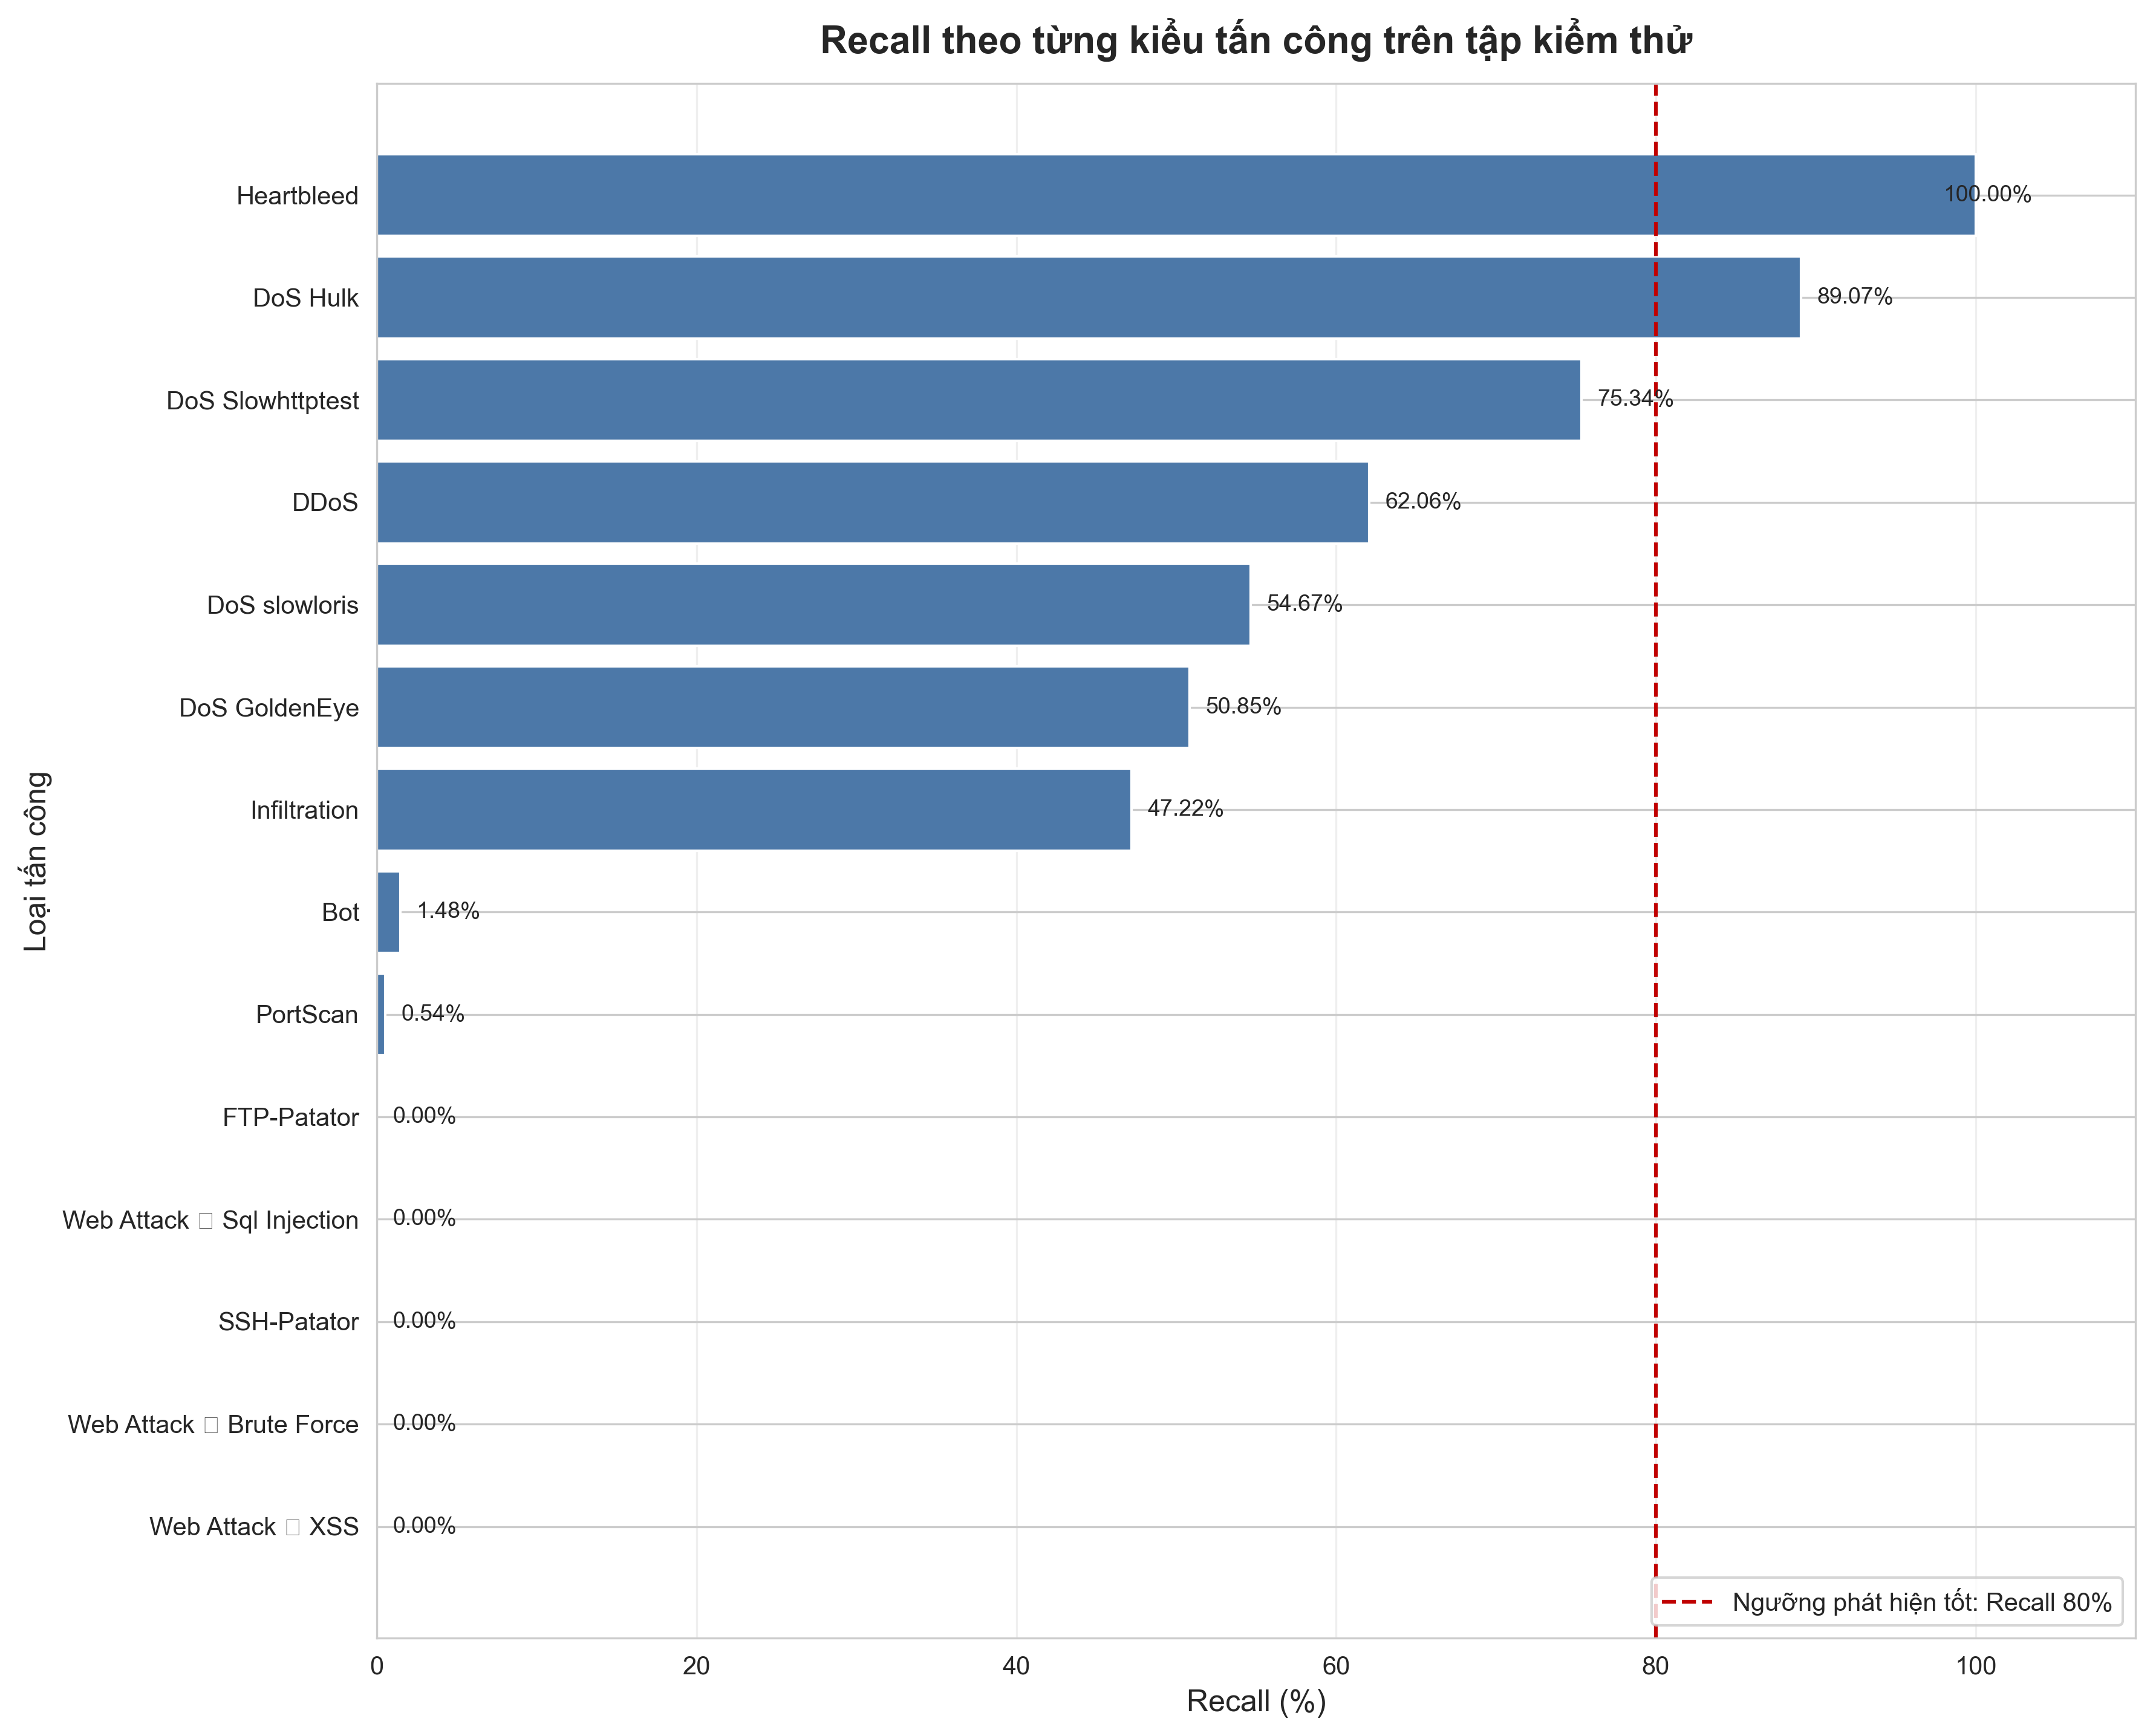

Đã lưu: D:\nids-vae-project\artifacts\experiments\result_analysis\per_attack_recall_overview.png


In [21]:
plot_df = all_attack_summary.sort_values("Recall (%)", ascending=True)

fig_height = max(7, len(plot_df) * 0.55 + 2)

fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)

bars = ax.barh(
    plot_df["Loại tấn công"],
    plot_df["Recall (%)"],
    color="#4C78A8",
    edgecolor="white",
)

ax.axvline(
    80,
    linestyle="--",
    linewidth=1.5,
    color="#C00000",
    label="Ngưỡng phát hiện tốt: Recall 80%",
)

for bar, recall in zip(bars, plot_df["Recall (%)"]):
    ax.text(
        min(recall + 1, 98),
        bar.get_y() + bar.get_height() / 2,
        f"{recall:.2f}%",
        va="center",
        fontsize=9,
    )

ax.set_title(
    "Recall theo từng kiểu tấn công trên tập kiểm thử",
    fontsize=15,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Recall (%)")
ax.set_ylabel("Loại tấn công")
ax.set_xlim(0, 110)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="lower right")

plt.tight_layout()

all_attacks_png = OUTPUT_DIR / "per_attack_recall_overview.png"
fig.savefig(all_attacks_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Đã lưu: {all_attacks_png}")